In [1]:
from pathlib import Path
import pandas as pd
from timesnet_encoder import TimesBlock
from sequences_peaks import SequenceConfig, _load_sequence_dataframe, _load_signal_from_row, _generate_peak_mask, TrainSequence, ValidationSequence, _wavelet_filter
from dataclasses import replace
from utils import setup_gpu
setup_gpu(memory_fraction=0.7)


2026-04-27 11:18:18.178867: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-04-27 11:18:18.178897: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-04-27 11:18:18.179753: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-04-27 11:18:18.184576: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


gpus: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


2026-04-27 11:18:20.977303: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355


[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

2026-04-27 11:18:20.983730: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-04-27 11:18:20.985639: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355


In [2]:
import os
from datetime import datetime

# Klasör ismini bugünün tarihiyle oluştur
date_str = datetime.now().strftime("%Y%m%d")
MODEL_FOLDER = f"{date_str}-GAN-v4.6.2"

# Klasörleri yarat
os.makedirs(MODEL_FOLDER, exist_ok=True)
os.makedirs(f"{MODEL_FOLDER}/weights", exist_ok=True) # Ağırlıklar buraya

# description.txt dosyasını oluştur ve yaz
description_text = """
MODEL VERSİYONU: GAN v4.6 (Energy-Aware Style Transfer & Inpainting / Referanslı Koşullu GAN)

MİMARİ ÖZETİ VE "KÖRLEŞTİRME" (ANTI-LEAKAGE) MANTIĞI:
1. ENCODER (Stil Çıkarıcı): 
   - Girdi: [Körleştirilmiş Sinyal (Z-Score), Peak Maskesi]
   - Görevi: Bilgi sızıntısını engellemek için gerçek sinyaldeki yürüme anları (peak noktaları) 31 birimlik genişletilmiş maskeyle sıfırlanarak SİLİNİR. Encoder sadece bu "delikli/sessiz" arka planı analiz edip 512 boyutlu bir stil DNA'sına (z_encoded) sıkıştırır.

2. GENERATOR (Sentezleyici):
   - Girdi: [z_encoded (Stil DNA'sı), Peak Maskesi (Şablon)]
   - Görevi: Encoder'dan gelen stili kullanarak eksik kısımlara %100 gerçekçi yürüme peakleri inşa etmek.
   - KRİTİK GÜNCELLEME (Energy Loss): Jeneratörün risk almamak için "cılız/düz" (Regression to the Mean) çizimler yapmasını engellemek adına MSE baskısı (x10'a) düşürülmüş ve maskeli alanlara özel "Enerji/Genlik Kaybı" (Amplitude Loss) eklenmiştir. Model artık agresif ve yüksek genlikli yürüme vuruşları yapmak ZORUNDADIR.

3. DISCRIMINATOR (Koşullu Hakem):
   - Girdi: [Tam Sinyal + Instance Noise, Peak Maskesi]
   - Görevi: Sinyalin "DAS formatında" gerçekçi bir titreşim olup olmadığını ve zamanlamasını denetlemek.
   - KRİTİK GÜNCELLEME (Anti-Overpowering): Hakemin çok hızlı öğrenip Jeneratörü ezmesini (D_Loss'un 0'a çakılmasını) önlemek için 3 profesyonel savunma hattı kurulmuştur:
     a) TTUR (Two Time-Scale Update Rule): Hakemin öğrenme hızı (5e-5), Jeneratörün (2e-4) çeyreğine düşürüldü.
     b) Label Smoothing: Hakem aşırı emin olmasın diye etiketler 1.0/0.0 yerine 0.9/0.1 yapıldı.
     c) Instance Noise: Hakeme giden sinyallere anlık gürültü (std=0.05) eklenerek ezberlemesi zorlaştırıldı.

VERİ VE ÇİZİM MANTIĞI:
- Model, Classifier'ın (clf939.h5) doğru çalışabilmesi için tamamen GÜRÜLTÜLÜ (Raw) DAS sinyalleriyle eğitilmiştir.
- Görselleştirme (Epoch sonu çizimleri) aşamasında, analiz kolaylığı için Wavelet Denoising (_wavelet_filter) uygulanır.
"""

with open(os.path.join(MODEL_FOLDER, "description.txt"), "w", encoding="utf-8") as f:
    f.write(description_text.strip())
    
print(f"Klasör ve Açıklama Dosyası Hazır: {MODEL_FOLDER}")

Klasör ve Açıklama Dosyası Hazır: 20260427-GAN-v4.6.2


In [3]:

DATA_FOLDER = Path("/tf/start_training/data/signal/2026-02-11-walking-with-peaks")

# CSV yolları (peaks sütunu içeren yeni dosyaların)
TRAIN_CSV = "train_all_peaks.csv"
VAL_CSV = DATA_FOLDER / "validation.csv"

WINDOW_SIZE = 5000
LABEL_NAMES = ['walking']
# Sequence ayarları
config = SequenceConfig(
    csv_path=TRAIN_CSV,
    batch_size=32,
    n_classes=len(LABEL_NAMES), # Örn: 3 sınıf
    window_size=WINDOW_SIZE,
    shuffle=True,
    balance=True
)
train_seq = TrainSequence(config)
val_seq = ValidationSequence(replace(config, csv_path=VAL_CSV))

In [4]:
encoder = TimesBlock.build_encoder_v4()
generator = TimesBlock.build_generator_v4()
discriminator = TimesBlock.build_discriminator_v4_1()

encoder.summary()
generator.summary()
discriminator.summary()

2026-04-27 11:18:21.056556: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-04-27 11:18:21.058502: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-04-27 11:18:21.060329: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-

Model: "Encoder_V4"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 signal_input_only (InputLa  [(None, 5000, 2)]         0         
 yer)                                                            
                                                                 
 conv1d (Conv1D)             (None, 625, 64)           5312      
                                                                 
 batch_normalization (Batch  (None, 625, 64)           256       
 Normalization)                                                  
                                                                 
 leaky_re_lu (LeakyReLU)     (None, 625, 64)           0         
                                                                 
 times_block (TimesBlock)    (None, 625, 64)           74112     
                                                                 
 times_block_1 (TimesBlock)  (None, 625, 64)           7

In [5]:
import tensorflow as tf
# import tf_keras as keras
classifier = tf.keras.models.load_model("/tf/models/clf939.h5")
classifier.trainable = False
WALKING_INDEX = 6

In [6]:
def prepare_for_classifier(fake_signals):
    # 1. Kanal boyutunu kaldır: (Batch, 5000, 1) -> (Batch, 5000)
    s = tf.squeeze(fake_signals, axis=-1)
    
    # 2. [1, 4] -> Zaman boyutunu 4 kez tekrarla (20.000 boyutuna ulaştır)
    s_20k = tf.tile(s, [1, 4])
    
    return s_20k

In [7]:
# Optimizer'lar
enc_gen_optimizer = tf.keras.optimizers.Adam(learning_rate=2e-4, beta_1=0.5, clipnorm=1.0)
disc_optimizer = tf.keras.optimizers.Adam(learning_rate=5e-5, beta_1=0.5, clipnorm=1.0)

# Kayıp fonksiyonları
bce = tf.keras.losses.BinaryCrossentropy()
mse = tf.keras.losses.MeanSquaredError()

# coefficients

alpha = 1.0 
beta = 0.5

In [8]:
import tensorflow as tf

@tf.function
def train_step(real_signals, peak_masks):
    batch_size = tf.shape(real_signals)[0]
    WALKING_INDEX = 6
    
    # --- Z-SCORE NORMALİZASYONU ---
    mean = tf.reduce_mean(real_signals, axis=1, keepdims=True)
    std = tf.math.reduce_std(real_signals, axis=1, keepdims=True) + 1e-8
    real_signals_normalized = (real_signals - mean) / std
    expanded_masks = tf.nn.max_pool1d(peak_masks, ksize=61, strides=1, padding='SAME')
    
    # 2. Genişletilmiş maskenin tersini al
    inv_masks = 1.0 - expanded_masks
    
    # 3. Gerçek sinyalin sadece peak (yürüme) olan genişletilmiş yerlerini sıfırla
    masked_real_signals = real_signals_normalized * inv_masks
    # 1. HEM DİSCRİMİNATÖR HEM ENCODER İÇİN GİRDİ BİRLEŞTİRME
    # (Batch, 5000, 2) formatına getiriyoruz
    # 4. Encoder'a artık "gerçekten" temizlenmiş/delikli arka planı ver
    concat_input = tf.concat([masked_real_signals, peak_masks], axis=-1)
    real_for_disc = tf.concat([real_signals_normalized, peak_masks], axis=-1)

    # --- DISCRIMINATOR EĞİTİMİ ---
    with tf.GradientTape() as disc_tape:
        # Encoder artık Stili anlıyor
        z_encoded = encoder(concat_input, training=False)
        fake_signals = generator([z_encoded, peak_masks], training=False)
        fake_concat = tf.concat([fake_signals, peak_masks], axis=-1)
        
        # YENİ: Hakemin gözünü bulandırmak için sinyallere suni gürültü ekliyoruz (Std: 0.05)
        noise_real = tf.random.normal(tf.shape(real_for_disc), mean=0.0, stddev=0.05)
        noise_fake = tf.random.normal(tf.shape(fake_concat), mean=0.0, stddev=0.05)
        
        # Hakeme gürültülü versiyonları veriyoruz
        pred_real = discriminator(real_for_disc + noise_real, training=True)
        pred_fake = discriminator(fake_concat + noise_fake, training=True)
        
        # Label Smoothing (0.9 ve 0.1) aynen kalıyor
        real_labels = tf.ones_like(pred_real) * 0.9
        fake_labels = tf.zeros_like(pred_fake) + 0.1
        
        d_loss = bce(real_labels, pred_real) + bce(fake_labels, pred_fake)

    grads_disc = disc_tape.gradient(d_loss, discriminator.trainable_variables)
    disc_optimizer.apply_gradients(zip(grads_disc, discriminator.trainable_variables))

    # --- ENCODER & GENERATOR EĞİTİMİ ---
    with tf.GradientTape() as gen_tape:
        z_encoded = encoder(concat_input, training=True)
        fake_signals = generator([z_encoded, peak_masks], training=True)
        fake_concat = tf.concat([fake_signals, peak_masks], axis=-1)
        
        # 1. Hakemi Kandırma Kaybı (l_adv)
        pred_fake_disc = discriminator(fake_concat, training=False)
        l_adv = bce(tf.ones_like(pred_fake_disc), pred_fake_disc)
        
        # 2. MSE Kaybı (Ağırlığını 50'den 10'a düşürdük, Jeneratör nefes alsın)
        l_mse = mse(real_signals_normalized, fake_signals)
        
        # Gerçek ve sahte sinyallerin SADECE maskeli alanlarını izole et
        real_masked = real_signals_normalized * expanded_masks
        fake_masked = fake_signals * expanded_masks
        
        # --- 1. MSE'Yİ İKİYE BÖL (Arka plan katı, maske içi özgür) ---
        bg_mask = 1.0 - expanded_masks # Sadece arka plan
        # Arka plan kusursuz olmalı (Ağırlık: Yüksek)
        l_mse_bg = tf.reduce_mean(tf.square((real_signals_normalized - fake_signals) * bg_mask))
        # Maske içinde faz kayması cezası yememesi için esnek bırakıyoruz (Ağırlık: Düşük)
        l_mse_peak = tf.reduce_mean(tf.square((real_signals_normalized - fake_signals) * expanded_masks))
        
        # --- 2. YÜKSEKLİK (Max Amp) ---
        real_max_amp = tf.reduce_max(tf.abs(real_masked), axis=1)
        fake_max_amp = tf.reduce_max(tf.abs(fake_masked), axis=1)
        l_amp = tf.reduce_mean(tf.abs(real_max_amp - fake_max_amp))
        
        # --- 3. GENİŞLİK / HACİM (Energy) ---
        real_energy = tf.reduce_mean(tf.square(real_masked), axis=1)
        fake_energy = tf.reduce_mean(tf.square(fake_masked), axis=1)
        l_energy = tf.reduce_mean(tf.abs(real_energy - fake_energy))
        
        # --- 4. KIVRIM (Grad) - Cezasınını çok düşürdük ki dalgalanabilsin ---
        real_grad = real_signals_normalized[:, 1:, :] - real_signals_normalized[:, :-1, :]
        fake_grad = fake_signals[:, 1:, :] - fake_signals[:, :-1, :]
        mask_for_grad = expanded_masks[:, 1:, :]
        
        masked_real_grad = real_grad * mask_for_grad
        masked_fake_grad = fake_grad * mask_for_grad
        l_grad = tf.reduce_mean(tf.square(masked_real_grad - masked_fake_grad))
        
        # --- TOPLAM L_REC (JENERATÖRÜN YENİ ANAYASASI) ---
        # Arka plan MSE (10.0) -> Arka planı bozma!
        # Peak MSE (1.0) -> Maske içinde hafif benzerlik yeterli, kaymalardan korkma.
        # Amp (10.0) -> Yüksekliği kesinlikle tuttur!
        # Energy (10.0) -> O dalgayı sağa sola yay, dar bırakma!
        # Grad (0.5) -> Çok hafif yumuşat ama zıplamasına engel olma.
        L_rec = l_adv + (10.0 * l_mse_bg) + (1.0 * l_mse_peak) + (10.0 * l_amp) + (10.0 * l_energy) + (0.5 * l_grad)
        
        # 4. Classifier Onayı
        fake_20k = prepare_for_classifier(fake_signals) 
        cls_predictions = classifier(fake_20k, training=False)
        walking_scores = cls_predictions[:, WALKING_INDEX]
        L_cls = bce(tf.ones((batch_size,)), walking_scores)
        
        # Toplam Jeneratör Kaybı
        total_gen_loss = (alpha * L_rec) + (beta * L_cls)

    var_list = encoder.trainable_variables + generator.trainable_variables
    grads_gen = gen_tape.gradient(total_gen_loss, var_list)
    enc_gen_optimizer.apply_gradients(zip(grads_gen, var_list))
    
    return d_loss, total_gen_loss, L_rec, L_cls

In [9]:
import matplotlib.pyplot as plt
import numpy as np
import os

def visualize_epoch_results(epoch, encoder, generator, train_seq, folder_path):
    batch_idx = np.random.randint(0, len(train_seq))
    batch_data, _ = train_seq[batch_idx]
    
    real_sig = batch_data[0:1, :, 0:1] 
    peak_mask = batch_data[0:1, :, 1:2]
    expanded_mask_tf = tf.nn.max_pool1d(peak_mask, ksize=61, strides=1, padding='SAME')
    expanded_mask_np = expanded_mask_tf.numpy()
    mean = np.mean(real_sig, axis=1, keepdims=True)
    std = np.std(real_sig, axis=1, keepdims=True) + 1e-8
    real_sig_norm = (real_sig - mean) / std 
    # Tersini al ve Sinyale uygula
    inv_mask = 1.0 - expanded_mask_np
    masked_real_sig = real_sig_norm * inv_mask
    
    # Encoder'a birleştirip ver
    encoder_input = tf.concat([masked_real_sig, peak_mask], axis=-1)
    z_encoded = encoder(encoder_input, training=False)
    fake_sig_norm = generator([z_encoded, peak_mask], training=False)



    
    # Vitrin Temizliği
    real_1d = real_sig_norm[0, :, 0]
    fake_1d = fake_sig_norm[0, :, 0].numpy()
    
    real_denoised = _wavelet_filter(real_1d)
    fake_denoised = _wavelet_filter(fake_1d)
    
    plt.figure(figsize=(18, 10), dpi=90) 
    
    # Üst Panel
    plt.subplot(2, 1, 1)
    plt.plot(real_denoised, color='gray', alpha=0.8, label='Orijinal Sinyal (Z-Score + Denoised)')
    plt.fill_between(range(5000), expanded_mask_np[0, :, 0] * np.max(real_denoised), 
                     color='red', alpha=0.2, label='Genişletilmiş Peak Alanı (Silinen Kısım)')
    plt.title(f"Epoch {epoch+1}: Orijinal Veri (Denoised) ve Peak Referansı")
    plt.legend(loc='upper right')
    plt.grid(True, alpha=0.3)
    
    # Alt Panel
    plt.subplot(2, 1, 2)
    plt.plot(fake_denoised, color='dodgerblue', linewidth=1.2, label='AI Üretimi Sinyal (Z-Score + Denoised)')
    plt.fill_between(range(5000), expanded_mask_np[0, :, 0] * np.max(fake_denoised), 
                     color='red', alpha=0.2, label='Genişletilmiş Peak Alanı')
    plt.title(f"Epoch {epoch+1}: Jeneratör Çıktısının Temizlenmiş (Denoised) Hali")
    plt.xlabel("Sample Index (5000)")
    plt.legend(loc='upper right')
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout(pad=2.0)
    
    # Görseli belirlenen klasöre kaydet
    save_path = os.path.join(folder_path, f"epoch_{epoch+1}_sonucu.png")
    plt.savefig(save_path, bbox_inches='tight')
    plt.show() 
    plt.close()

--- EPOCH 1 BAŞLADI ---


2026-04-27 11:18:29.244076: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:454] Loaded cuDNN version 8906
2026-04-27 11:18:31.510458: I external/local_xla/xla/service/service.cc:168] XLA service 0x7f2d9b2ff390 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-04-27 11:18:31.510480: I external/local_xla/xla/service/service.cc:176]   StreamExecutor device (0): NVIDIA GeForce RTX 4090, Compute Capability 8.9
2026-04-27 11:18:31.513962: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1777288711.566028   35480 device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


Epoch 1 | Step 427/428 | D_Loss: 0.6833 | G_Total: 16.03
Epoch 1 Özet | D_Loss: 0.8057 | G_Total: 29.19 | Rec: 16.03 | Cls: 0.00
Yeni En Düşük G_Loss! (Best Epoch şu an: 1)
--- EPOCH 2 BAŞLADI ---
Epoch 2 | Step 427/428 | D_Loss: 0.6683 | G_Total: 12.53
Epoch 2 Özet | D_Loss: 0.6774 | G_Total: 16.86 | Rec: 12.52 | Cls: 0.03
Yeni En Düşük G_Loss! (Best Epoch şu an: 2)
--- EPOCH 3 BAŞLADI ---
Epoch 3 | Step 427/428 | D_Loss: 0.6603 | G_Total: 16.76
Epoch 3 Özet | D_Loss: 0.6623 | G_Total: 14.88 | Rec: 16.76 | Cls: 0.00
Yeni En Düşük G_Loss! (Best Epoch şu an: 3)
--- EPOCH 4 BAŞLADI ---
Epoch 4 | Step 427/428 | D_Loss: 0.6588 | G_Total: 14.66
Epoch 4 Özet | D_Loss: 0.6578 | G_Total: 14.51 | Rec: 14.65 | Cls: 0.02
Yeni En Düşük G_Loss! (Best Epoch şu an: 4)
--- EPOCH 5 BAŞLADI ---
Epoch 5 | Step 427/428 | D_Loss: 0.6574 | G_Total: 13.40
Epoch 5 Özet | D_Loss: 0.6569 | G_Total: 15.12 | Rec: 13.40 | Cls: 0.00


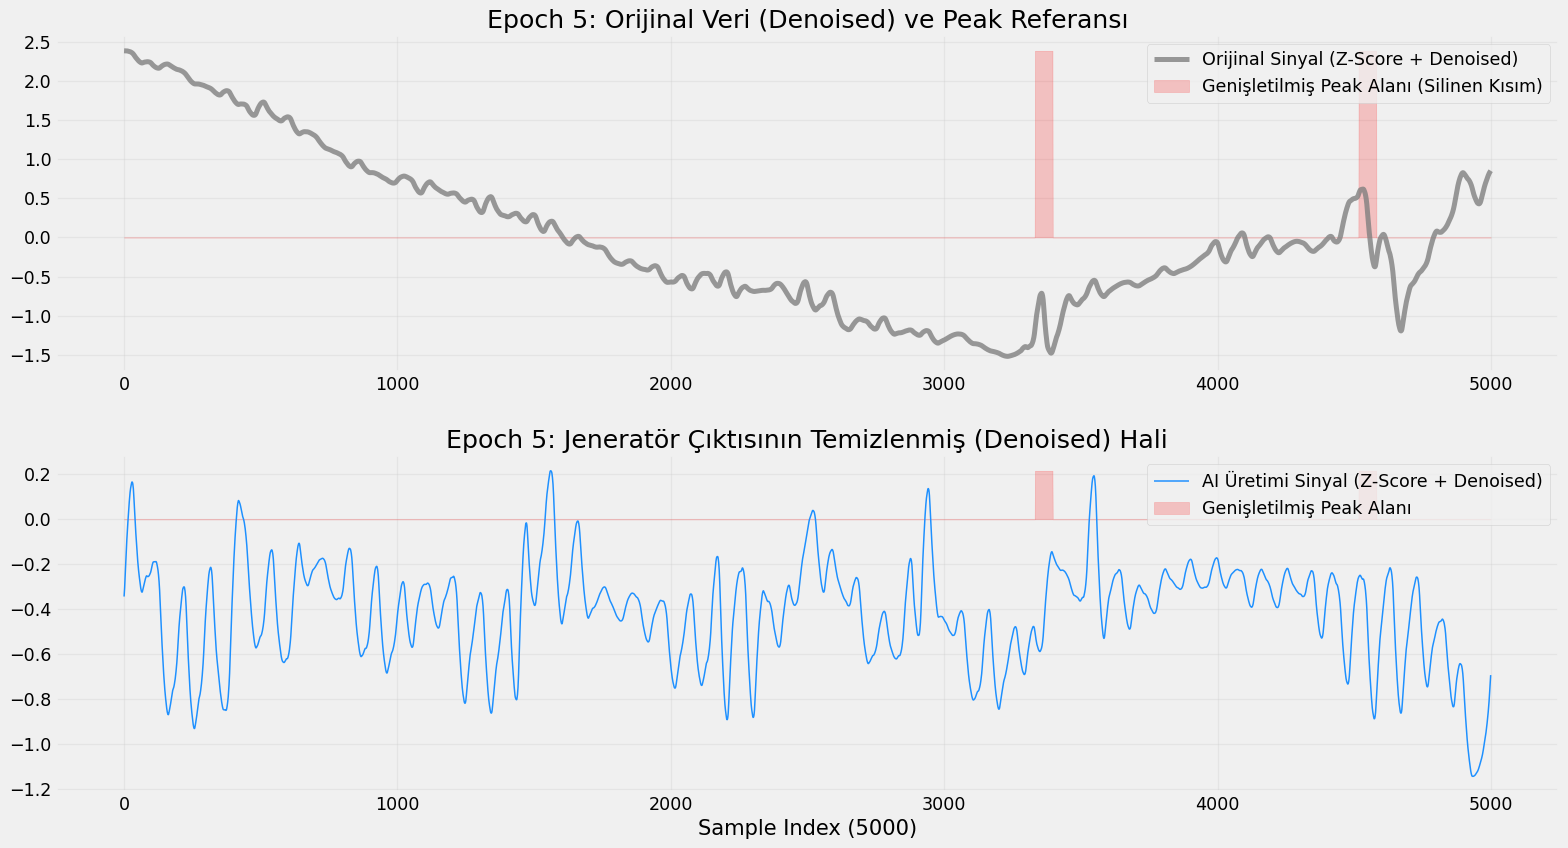

💾 Epoch 5 görselleri ve ağırlıkları kaydedildi.
--- EPOCH 6 BAŞLADI ---
Epoch 6 | Step 427/428 | D_Loss: 0.6561 | G_Total: 14.00
Epoch 6 Özet | D_Loss: 0.6548 | G_Total: 14.60 | Rec: 14.00 | Cls: -0.00
--- EPOCH 7 BAŞLADI ---
Epoch 7 | Step 427/428 | D_Loss: 0.6545 | G_Total: 16.85
Epoch 7 Özet | D_Loss: 0.6541 | G_Total: 13.60 | Rec: 16.85 | Cls: 0.00
Yeni En Düşük G_Loss! (Best Epoch şu an: 7)
--- EPOCH 8 BAŞLADI ---
Epoch 8 | Step 427/428 | D_Loss: 0.6556 | G_Total: 12.75
Epoch 8 Özet | D_Loss: 0.6535 | G_Total: 12.76 | Rec: 12.75 | Cls: 0.00
Yeni En Düşük G_Loss! (Best Epoch şu an: 8)
--- EPOCH 9 BAŞLADI ---
Epoch 9 | Step 427/428 | D_Loss: 0.6531 | G_Total: 13.48
Epoch 9 Özet | D_Loss: 0.6534 | G_Total: 12.68 | Rec: 13.48 | Cls: -0.00
Yeni En Düşük G_Loss! (Best Epoch şu an: 9)
--- EPOCH 10 BAŞLADI ---
Epoch 10 | Step 427/428 | D_Loss: 0.6532 | G_Total: 15.20
Epoch 10 Özet | D_Loss: 0.6533 | G_Total: 13.02 | Rec: 15.20 | Cls: 0.00


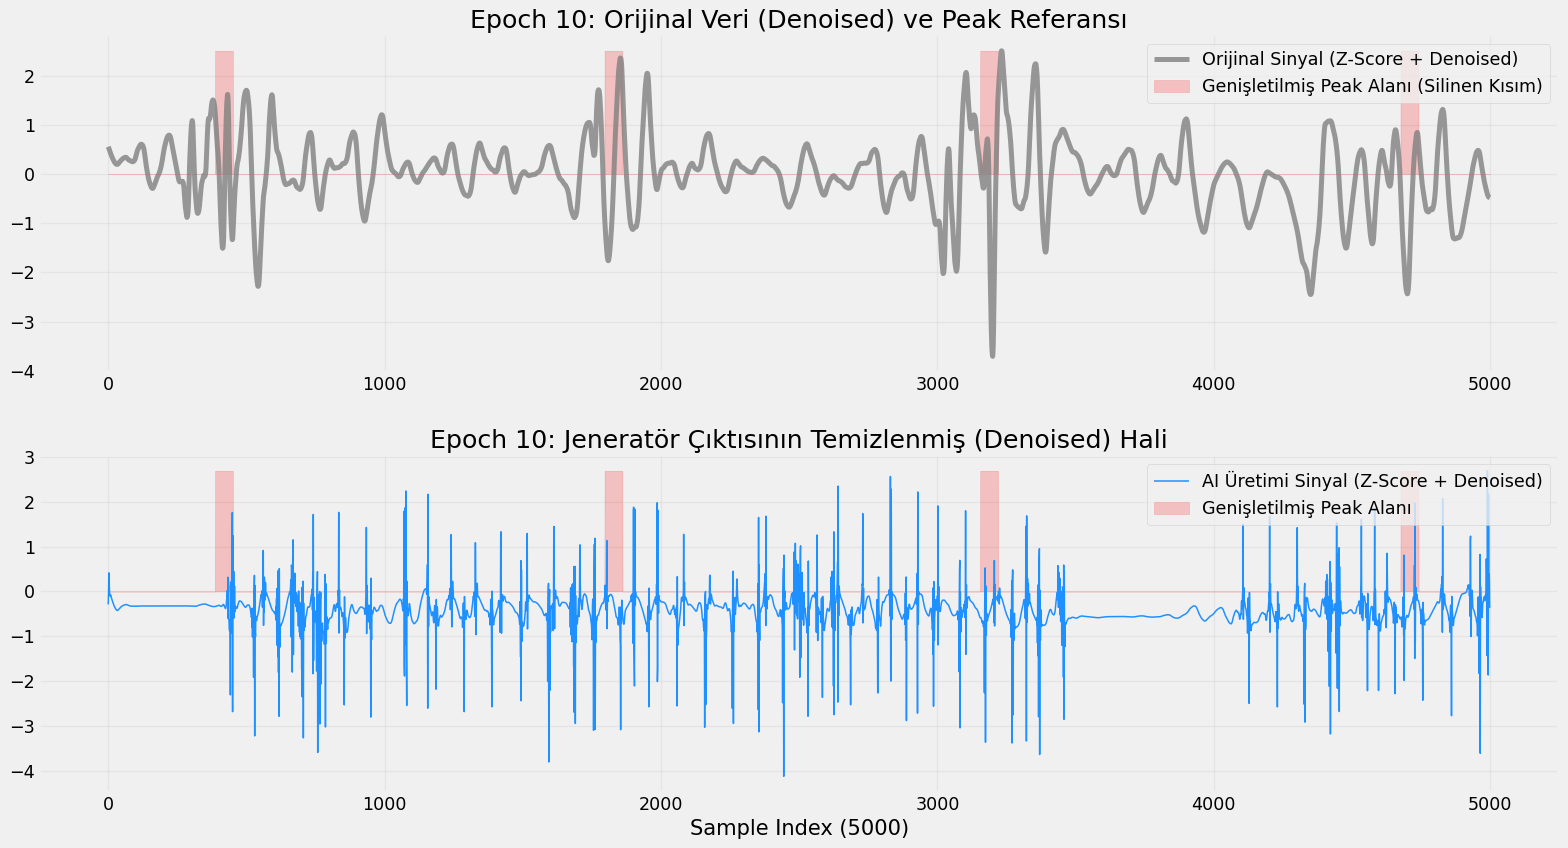

💾 Epoch 10 görselleri ve ağırlıkları kaydedildi.
--- EPOCH 11 BAŞLADI ---
Epoch 11 | Step 427/428 | D_Loss: 0.6525 | G_Total: 14.63
Epoch 11 Özet | D_Loss: 0.6540 | G_Total: 12.65 | Rec: 14.63 | Cls: 0.00
Yeni En Düşük G_Loss! (Best Epoch şu an: 11)
--- EPOCH 12 BAŞLADI ---
Epoch 12 | Step 427/428 | D_Loss: 0.6527 | G_Total: 12.79
Epoch 12 Özet | D_Loss: 0.6530 | G_Total: 12.07 | Rec: 12.79 | Cls: 0.00
Yeni En Düşük G_Loss! (Best Epoch şu an: 12)
--- EPOCH 13 BAŞLADI ---
Epoch 13 | Step 427/428 | D_Loss: 0.6527 | G_Total: 15.45
Epoch 13 Özet | D_Loss: 0.6523 | G_Total: 11.55 | Rec: 15.45 | Cls: -0.00
Yeni En Düşük G_Loss! (Best Epoch şu an: 13)
--- EPOCH 14 BAŞLADI ---
Epoch 14 | Step 427/428 | D_Loss: 0.6550 | G_Total: 17.63
Epoch 14 Özet | D_Loss: 0.6520 | G_Total: 11.22 | Rec: 17.63 | Cls: -0.00
Yeni En Düşük G_Loss! (Best Epoch şu an: 14)
--- EPOCH 15 BAŞLADI ---
Epoch 15 | Step 427/428 | D_Loss: 0.6519 | G_Total: 15.08
Epoch 15 Özet | D_Loss: 0.6519 | G_Total: 10.89 | Rec: 15.08 |

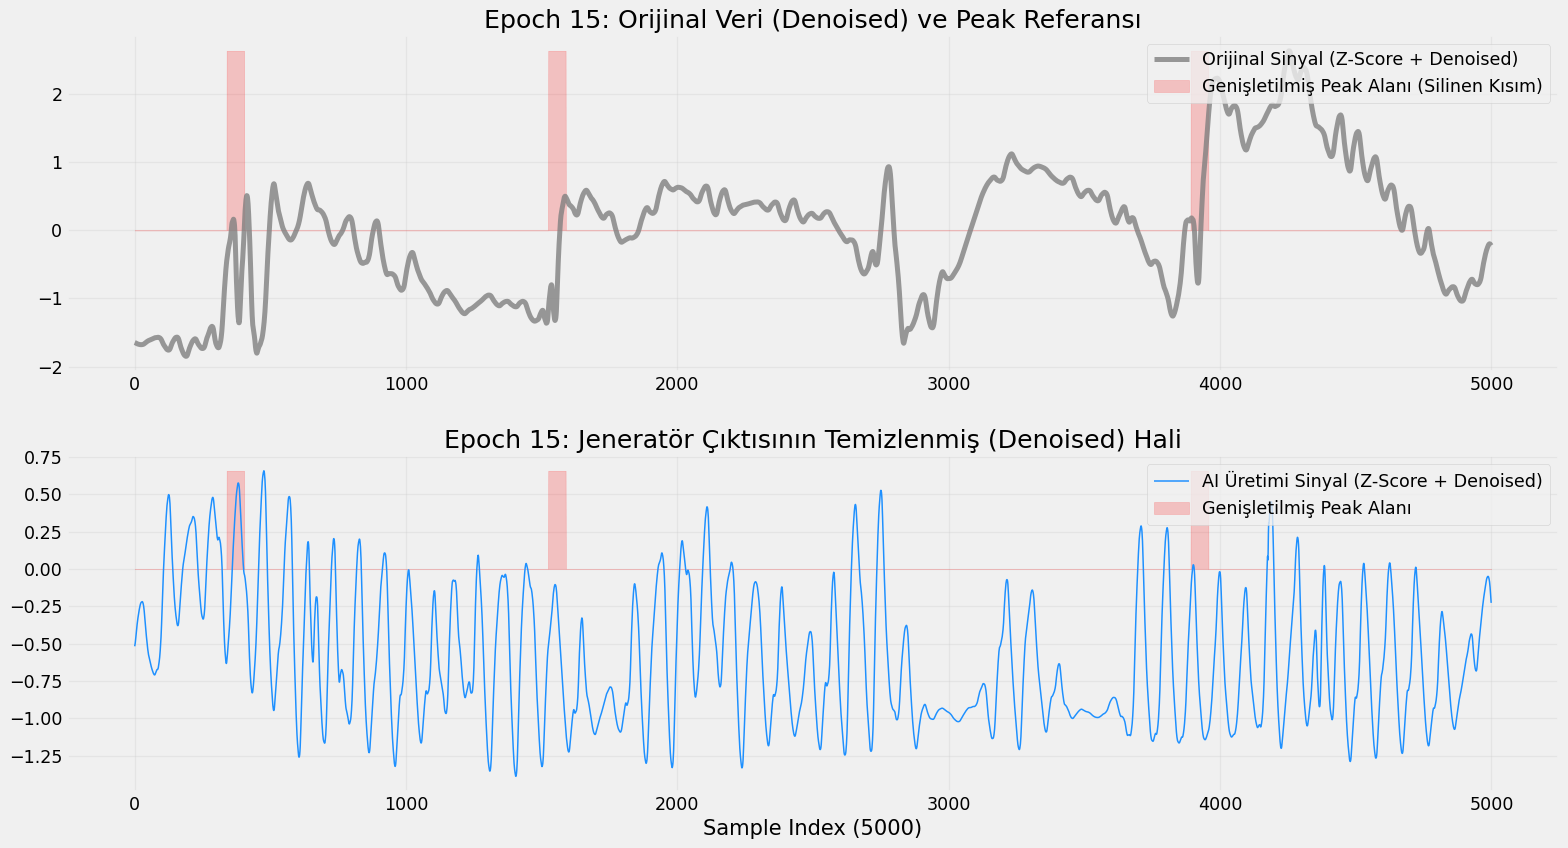

💾 Epoch 15 görselleri ve ağırlıkları kaydedildi.
--- EPOCH 16 BAŞLADI ---
Epoch 16 | Step 427/428 | D_Loss: 0.6531 | G_Total: 12.57
Epoch 16 Özet | D_Loss: 0.6517 | G_Total: 11.05 | Rec: 12.57 | Cls: 0.00
--- EPOCH 17 BAŞLADI ---
Epoch 17 | Step 427/428 | D_Loss: 0.6520 | G_Total: 11.72
Epoch 17 Özet | D_Loss: 0.6517 | G_Total: 11.13 | Rec: 11.72 | Cls: 0.00
--- EPOCH 18 BAŞLADI ---
Epoch 18 | Step 427/428 | D_Loss: 0.6513 | G_Total: 13.045
Epoch 18 Özet | D_Loss: 0.6515 | G_Total: 11.15 | Rec: 13.04 | Cls: 0.00
--- EPOCH 19 BAŞLADI ---
Epoch 19 | Step 427/428 | D_Loss: 0.6528 | G_Total: 13.85
Epoch 19 Özet | D_Loss: 0.6514 | G_Total: 10.50 | Rec: 13.85 | Cls: 0.00
Yeni En Düşük G_Loss! (Best Epoch şu an: 19)
--- EPOCH 20 BAŞLADI ---
Epoch 20 | Step 427/428 | D_Loss: 0.6512 | G_Total: 12.78
Epoch 20 Özet | D_Loss: 0.6511 | G_Total: 10.30 | Rec: 12.78 | Cls: 0.00
Yeni En Düşük G_Loss! (Best Epoch şu an: 20)


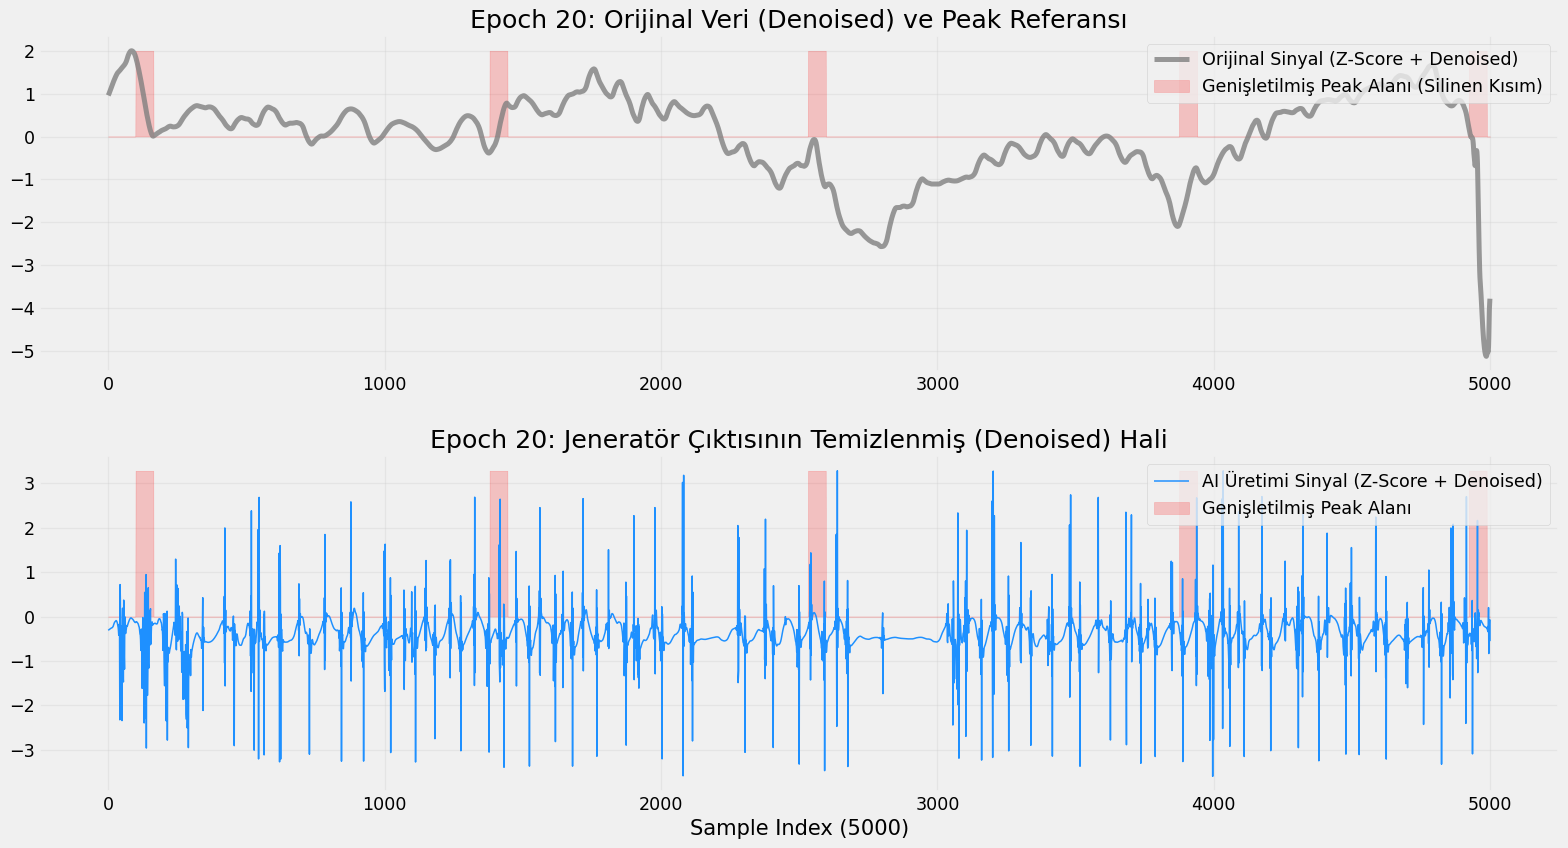

💾 Epoch 20 görselleri ve ağırlıkları kaydedildi.
--- EPOCH 21 BAŞLADI ---
Epoch 21 | Step 427/428 | D_Loss: 0.6511 | G_Total: 13.73
Epoch 21 Özet | D_Loss: 0.6511 | G_Total: 10.26 | Rec: 13.73 | Cls: 0.00
Yeni En Düşük G_Loss! (Best Epoch şu an: 21)
--- EPOCH 22 BAŞLADI ---
Epoch 22 | Step 427/428 | D_Loss: 0.6510 | G_Total: 13.62
Epoch 22 Özet | D_Loss: 0.6510 | G_Total: 10.04 | Rec: 13.62 | Cls: 0.00
Yeni En Düşük G_Loss! (Best Epoch şu an: 22)
--- EPOCH 23 BAŞLADI ---
Epoch 23 | Step 427/428 | D_Loss: 0.6511 | G_Total: 10.57
Epoch 23 Özet | D_Loss: 0.6509 | G_Total: 9.71 | Rec: 10.57 | Cls: -0.00
Yeni En Düşük G_Loss! (Best Epoch şu an: 23)
--- EPOCH 24 BAŞLADI ---
Epoch 24 | Step 427/428 | D_Loss: 0.6527 | G_Total: 11.90
Epoch 24 Özet | D_Loss: 0.6510 | G_Total: 9.64 | Rec: 11.88 | Cls: 0.04
Yeni En Düşük G_Loss! (Best Epoch şu an: 24)
--- EPOCH 25 BAŞLADI ---
Epoch 25 | Step 427/428 | D_Loss: 0.6517 | G_Total: 9.748
Epoch 25 Özet | D_Loss: 0.6509 | G_Total: 9.48 | Rec: 9.74 | Cls:

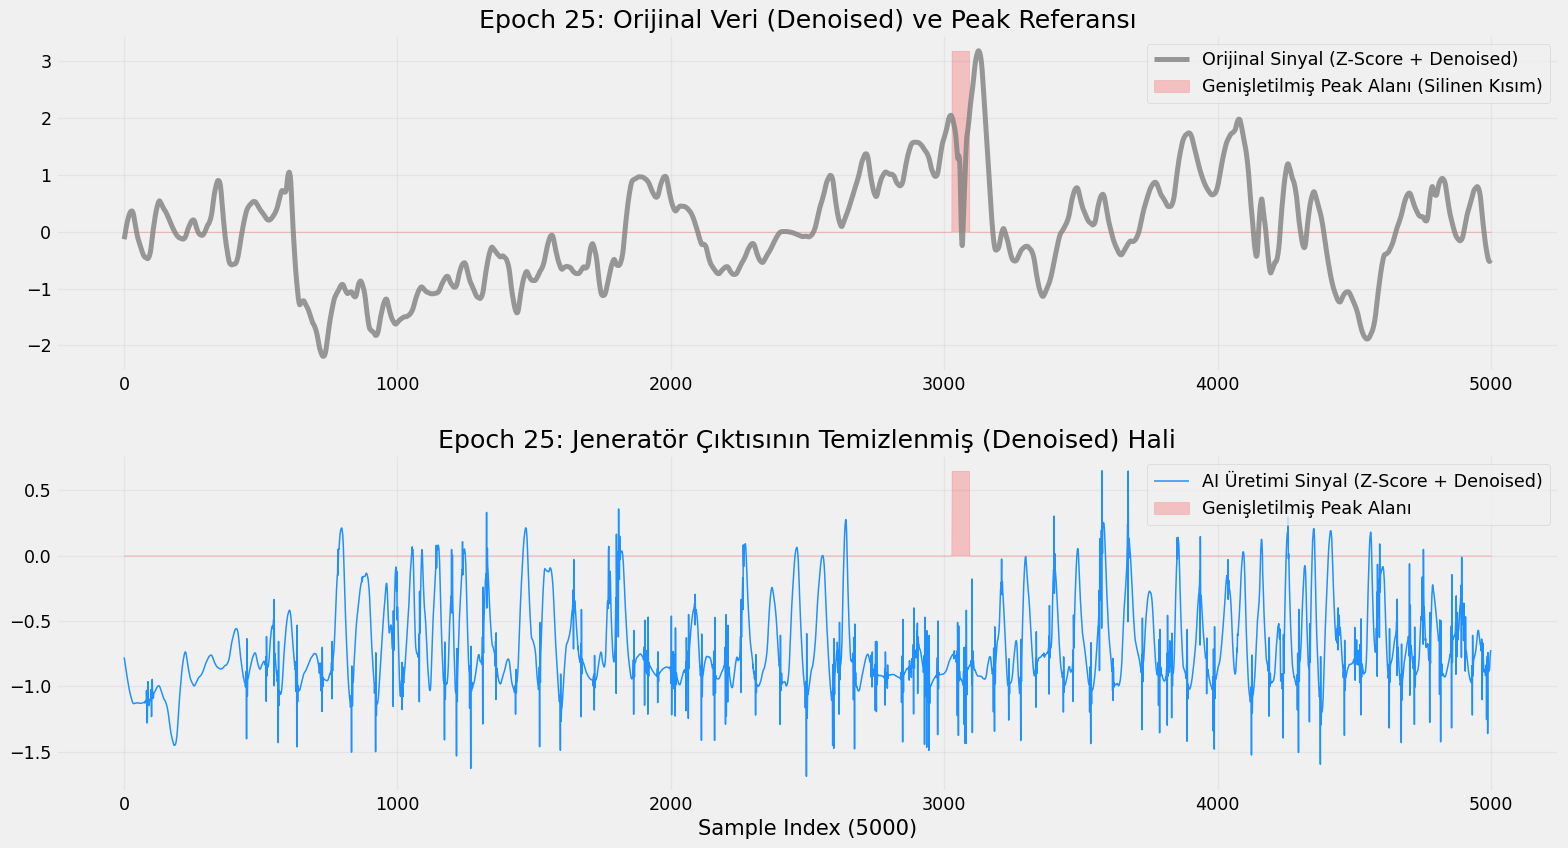

💾 Epoch 25 görselleri ve ağırlıkları kaydedildi.
--- EPOCH 26 BAŞLADI ---
Epoch 26 | Step 427/428 | D_Loss: 0.6510 | G_Total: 9.720
Epoch 26 Özet | D_Loss: 0.6509 | G_Total: 10.07 | Rec: 9.72 | Cls: 0.00
--- EPOCH 27 BAŞLADI ---
Epoch 27 | Step 427/428 | D_Loss: 0.6505 | G_Total: 11.88
Epoch 27 Özet | D_Loss: 0.6507 | G_Total: 9.68 | Rec: 11.88 | Cls: 0.00
--- EPOCH 28 BAŞLADI ---
Epoch 28 | Step 427/428 | D_Loss: 0.6518 | G_Total: 10.61
Epoch 28 Özet | D_Loss: 0.6507 | G_Total: 9.32 | Rec: 10.61 | Cls: -0.00
Yeni En Düşük G_Loss! (Best Epoch şu an: 28)
--- EPOCH 29 BAŞLADI ---
Epoch 29 | Step 427/428 | D_Loss: 0.6508 | G_Total: 10.44
Epoch 29 Özet | D_Loss: 0.6506 | G_Total: 9.13 | Rec: 10.44 | Cls: 0.00
Yeni En Düşük G_Loss! (Best Epoch şu an: 29)
--- EPOCH 30 BAŞLADI ---
Epoch 30 | Step 427/428 | D_Loss: 0.6537 | G_Total: 9.008
Epoch 30 Özet | D_Loss: 0.6507 | G_Total: 8.85 | Rec: 9.00 | Cls: -0.00
Yeni En Düşük G_Loss! (Best Epoch şu an: 30)


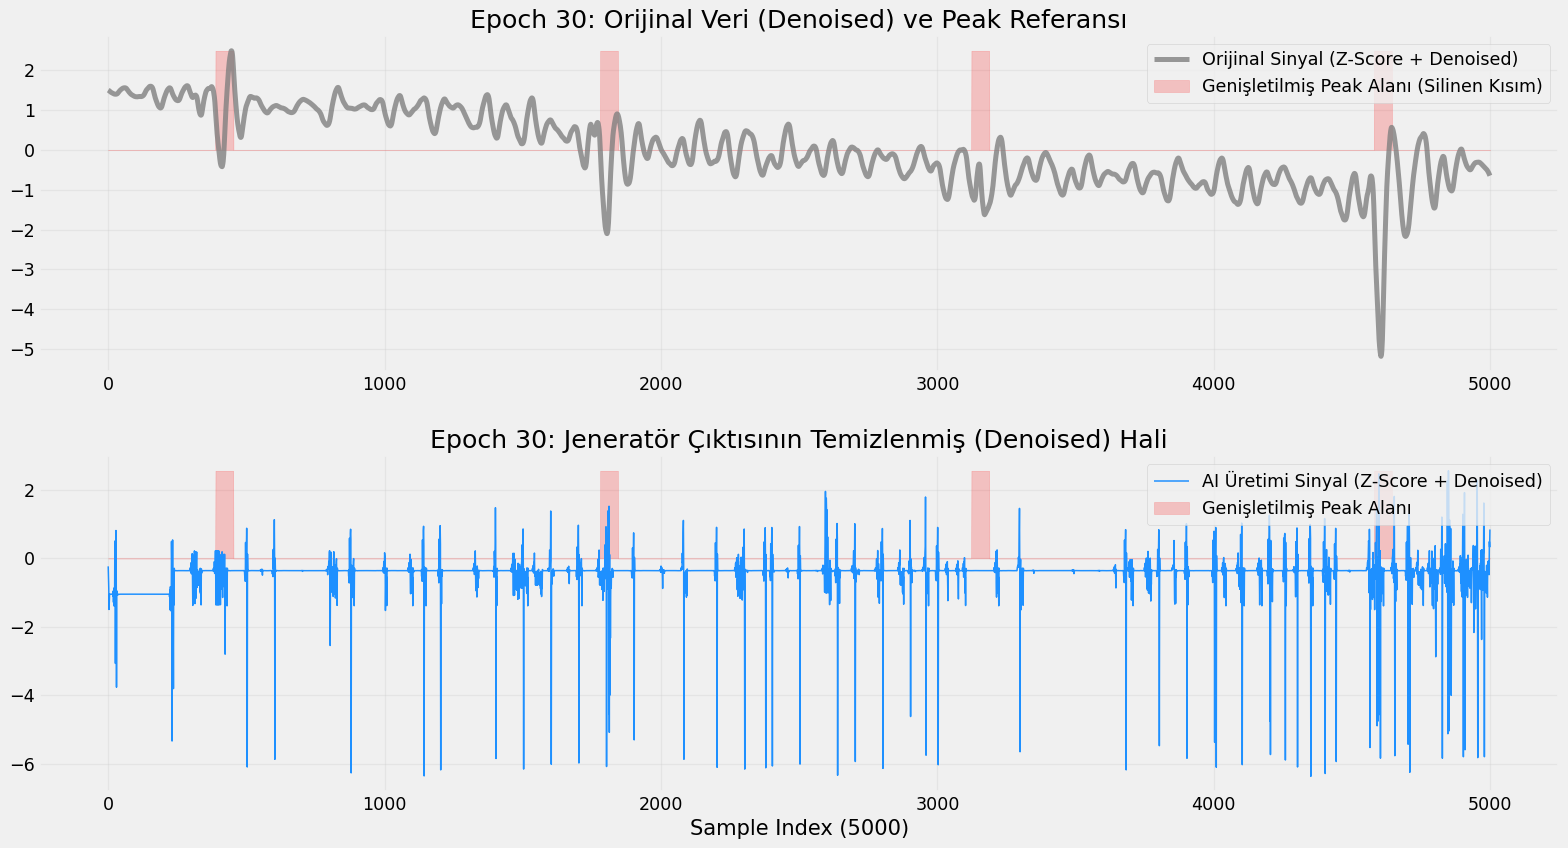

💾 Epoch 30 görselleri ve ağırlıkları kaydedildi.
--- EPOCH 31 BAŞLADI ---
Epoch 31 | Step 427/428 | D_Loss: 0.6508 | G_Total: 14.52
Epoch 31 Özet | D_Loss: 0.6530 | G_Total: 8.68 | Rec: 11.52 | Cls: 6.00
Yeni En Düşük G_Loss! (Best Epoch şu an: 31)
--- EPOCH 32 BAŞLADI ---
Epoch 32 | Step 427/428 | D_Loss: 0.6507 | G_Total: 8.979
Epoch 32 Özet | D_Loss: 0.6507 | G_Total: 8.60 | Rec: 8.97 | Cls: -0.00
Yeni En Düşük G_Loss! (Best Epoch şu an: 32)
--- EPOCH 33 BAŞLADI ---
Epoch 33 | Step 427/428 | D_Loss: 0.6510 | G_Total: 9.194
Epoch 33 Özet | D_Loss: 0.6506 | G_Total: 8.52 | Rec: 9.19 | Cls: 0.00
Yeni En Düşük G_Loss! (Best Epoch şu an: 33)
--- EPOCH 34 BAŞLADI ---
Epoch 34 | Step 427/428 | D_Loss: 0.6512 | G_Total: 8.284
Epoch 34 Özet | D_Loss: 0.6505 | G_Total: 8.22 | Rec: 8.28 | Cls: 0.00
Yeni En Düşük G_Loss! (Best Epoch şu an: 34)
--- EPOCH 35 BAŞLADI ---
Epoch 35 | Step 427/428 | D_Loss: 0.6518 | G_Total: 8.639
Epoch 35 Özet | D_Loss: 0.6506 | G_Total: 8.01 | Rec: 8.63 | Cls: 0.00

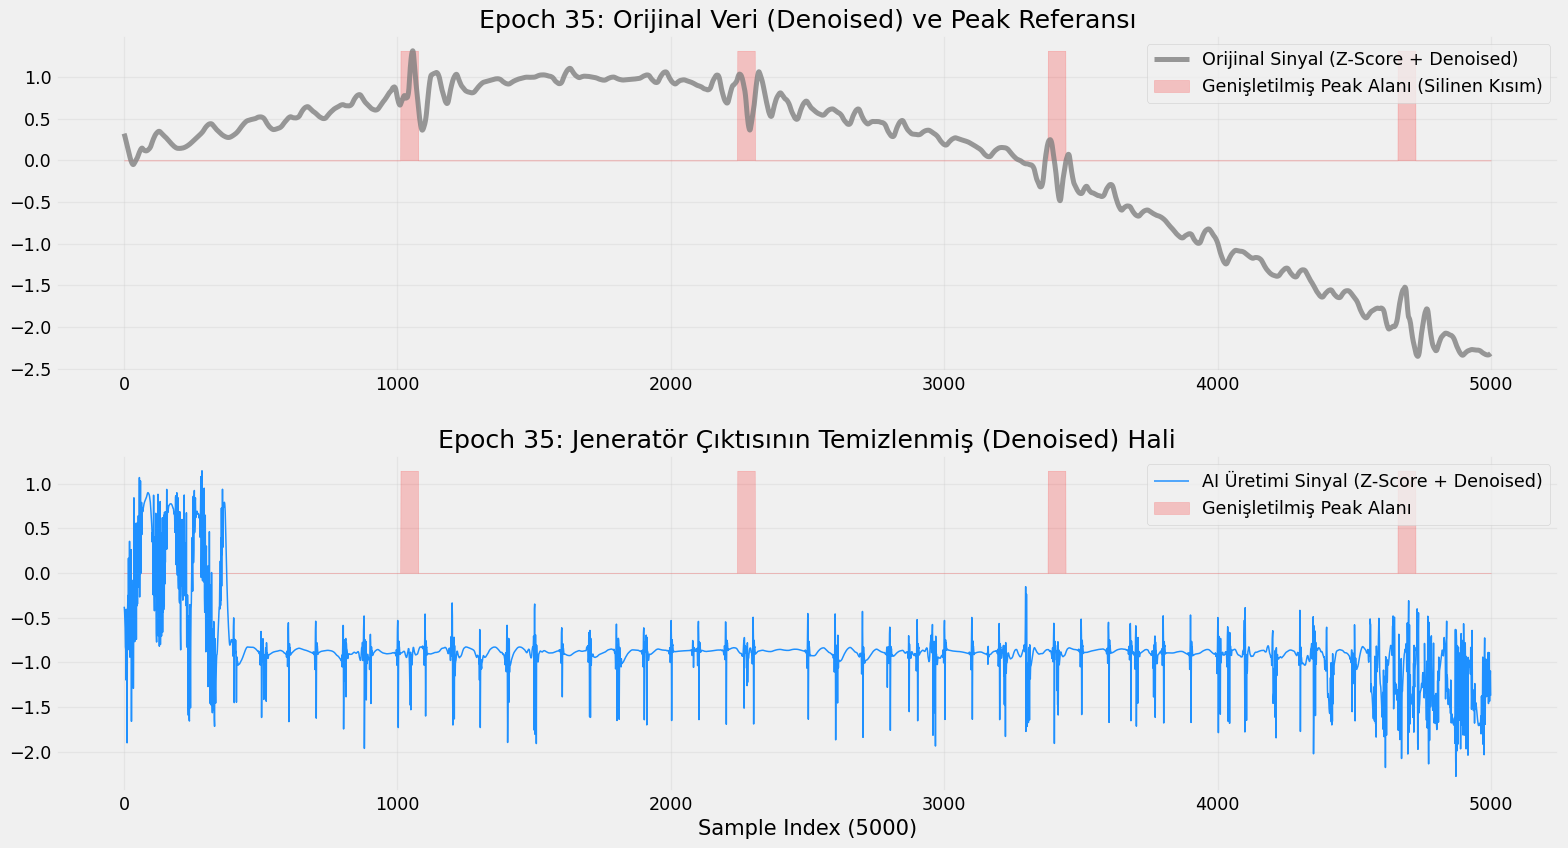

💾 Epoch 35 görselleri ve ağırlıkları kaydedildi.
--- EPOCH 36 BAŞLADI ---
Epoch 36 | Step 427/428 | D_Loss: 0.6508 | G_Total: 8.121
Epoch 36 Özet | D_Loss: 0.6511 | G_Total: 8.45 | Rec: 8.11 | Cls: 0.01
--- EPOCH 37 BAŞLADI ---
Epoch 37 | Step 427/428 | D_Loss: 0.6504 | G_Total: 9.544
Epoch 37 Özet | D_Loss: 0.6506 | G_Total: 8.12 | Rec: 9.54 | Cls: 0.00
--- EPOCH 38 BAŞLADI ---
Epoch 38 | Step 427/428 | D_Loss: 0.6519 | G_Total: 8.023
Epoch 38 Özet | D_Loss: 0.6505 | G_Total: 7.84 | Rec: 8.02 | Cls: 0.00
Yeni En Düşük G_Loss! (Best Epoch şu an: 38)
--- EPOCH 39 BAŞLADI ---
Epoch 39 | Step 427/428 | D_Loss: 0.6504 | G_Total: 8.978
Epoch 39 Özet | D_Loss: 0.6506 | G_Total: 7.64 | Rec: 8.97 | Cls: 0.00
Yeni En Düşük G_Loss! (Best Epoch şu an: 39)
--- EPOCH 40 BAŞLADI ---
Epoch 40 | Step 427/428 | D_Loss: 0.6504 | G_Total: 8.839
Epoch 40 Özet | D_Loss: 0.6507 | G_Total: 7.51 | Rec: 8.83 | Cls: -0.00
Yeni En Düşük G_Loss! (Best Epoch şu an: 40)


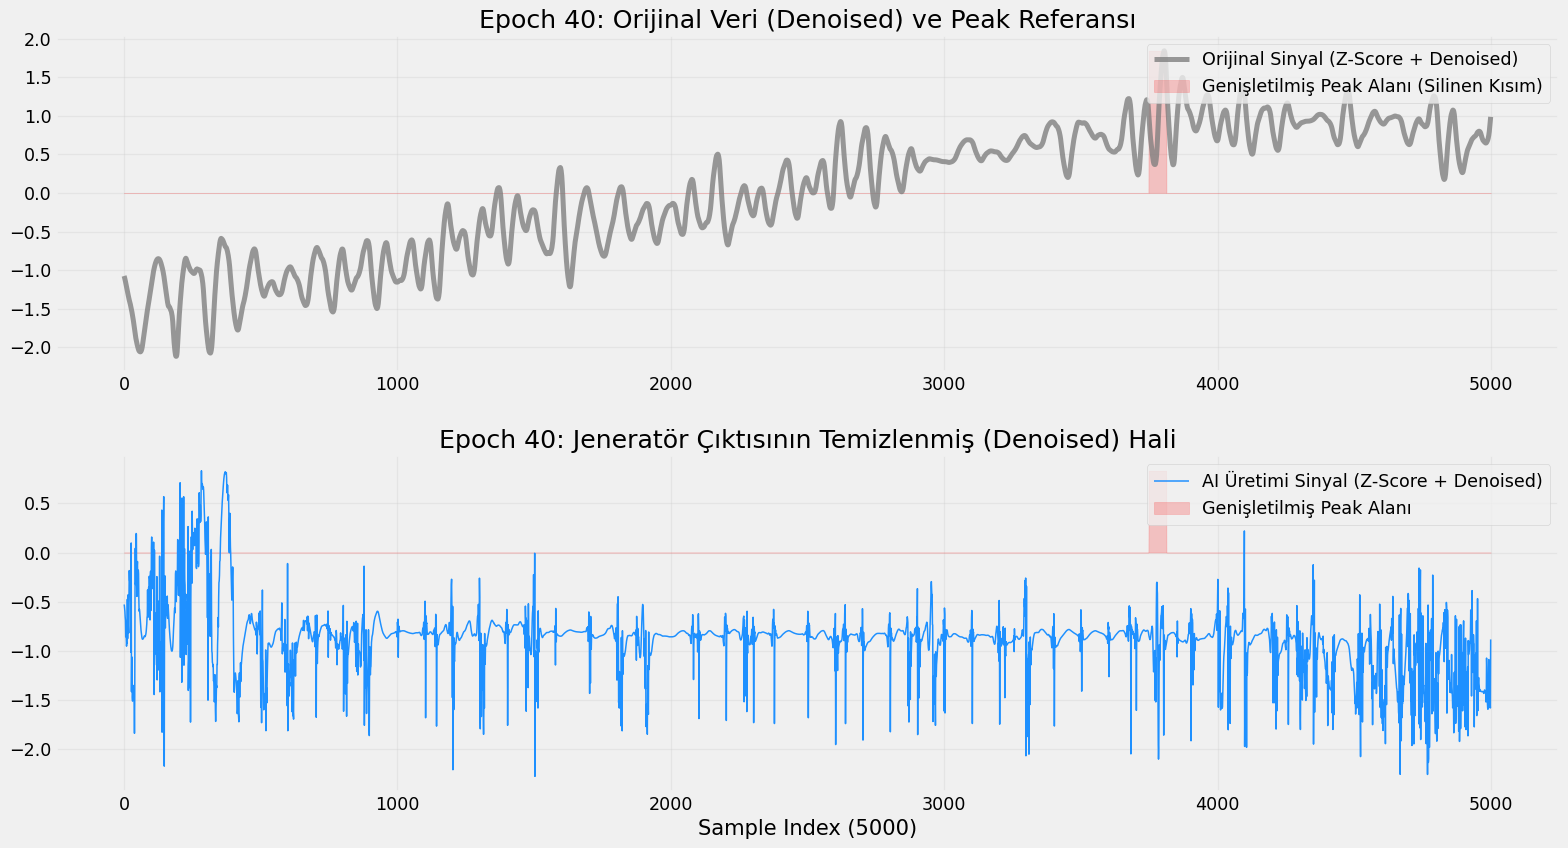

💾 Epoch 40 görselleri ve ağırlıkları kaydedildi.
--- EPOCH 41 BAŞLADI ---
Epoch 41 | Step 427/428 | D_Loss: 0.6511 | G_Total: 7.990
Epoch 41 Özet | D_Loss: 0.6519 | G_Total: 7.40 | Rec: 7.99 | Cls: -0.00
Yeni En Düşük G_Loss! (Best Epoch şu an: 41)
--- EPOCH 42 BAŞLADI ---
Epoch 42 | Step 427/428 | D_Loss: 0.6512 | G_Total: 9.633
Epoch 42 Özet | D_Loss: 0.6540 | G_Total: 7.21 | Rec: 9.63 | Cls: 0.00
Yeni En Düşük G_Loss! (Best Epoch şu an: 42)
--- EPOCH 43 BAŞLADI ---
Epoch 43 | Step 427/428 | D_Loss: 0.6504 | G_Total: 7.243
Epoch 43 Özet | D_Loss: 0.6509 | G_Total: 7.06 | Rec: 7.24 | Cls: -0.00
Yeni En Düşük G_Loss! (Best Epoch şu an: 43)
--- EPOCH 44 BAŞLADI ---
Epoch 44 | Step 427/428 | D_Loss: 0.6505 | G_Total: 7.48
Epoch 44 Özet | D_Loss: 0.6508 | G_Total: 6.65 | Rec: 7.48 | Cls: 0.00
Yeni En Düşük G_Loss! (Best Epoch şu an: 44)
--- EPOCH 45 BAŞLADI ---
Epoch 45 | Step 427/428 | D_Loss: 0.6505 | G_Total: 8.12
Epoch 45 Özet | D_Loss: 0.6507 | G_Total: 6.55 | Rec: 8.12 | Cls: 0.00
Y

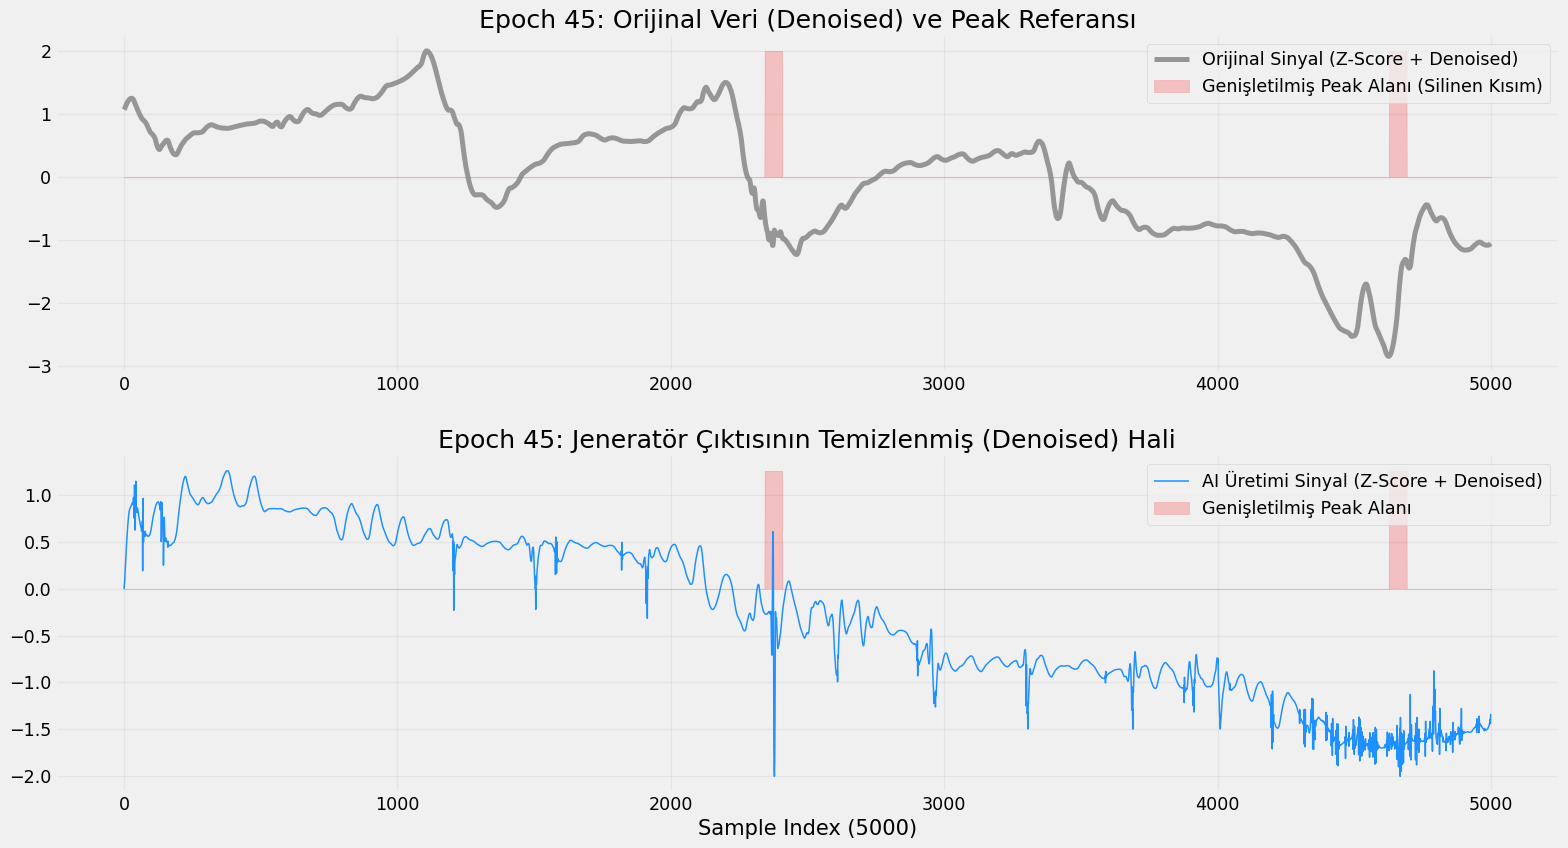

💾 Epoch 45 görselleri ve ağırlıkları kaydedildi.
--- EPOCH 46 BAŞLADI ---
Epoch 46 | Step 427/428 | D_Loss: 0.6506 | G_Total: 8.85
Epoch 46 Özet | D_Loss: 0.6507 | G_Total: 6.33 | Rec: 8.85 | Cls: -0.00
Yeni En Düşük G_Loss! (Best Epoch şu an: 46)
--- EPOCH 47 BAŞLADI ---
Epoch 47 | Step 427/428 | D_Loss: 0.6506 | G_Total: 8.13
Epoch 47 Özet | D_Loss: 0.6526 | G_Total: 6.19 | Rec: 8.13 | Cls: -0.00
Yeni En Düşük G_Loss! (Best Epoch şu an: 47)
--- EPOCH 48 BAŞLADI ---
Epoch 48 | Step 427/428 | D_Loss: 0.6506 | G_Total: 7.505
Epoch 48 Özet | D_Loss: 0.6508 | G_Total: 6.26 | Rec: 7.50 | Cls: 0.00
--- EPOCH 49 BAŞLADI ---
Epoch 49 | Step 427/428 | D_Loss: 0.6506 | G_Total: 6.63
Epoch 49 Özet | D_Loss: 0.6505 | G_Total: 6.09 | Rec: 6.63 | Cls: 0.00
Yeni En Düşük G_Loss! (Best Epoch şu an: 49)
--- EPOCH 50 BAŞLADI ---
Epoch 50 | Step 427/428 | D_Loss: 0.6504 | G_Total: 6.94
Epoch 50 Özet | D_Loss: 0.6505 | G_Total: 5.94 | Rec: 6.94 | Cls: -0.00
Yeni En Düşük G_Loss! (Best Epoch şu an: 50)


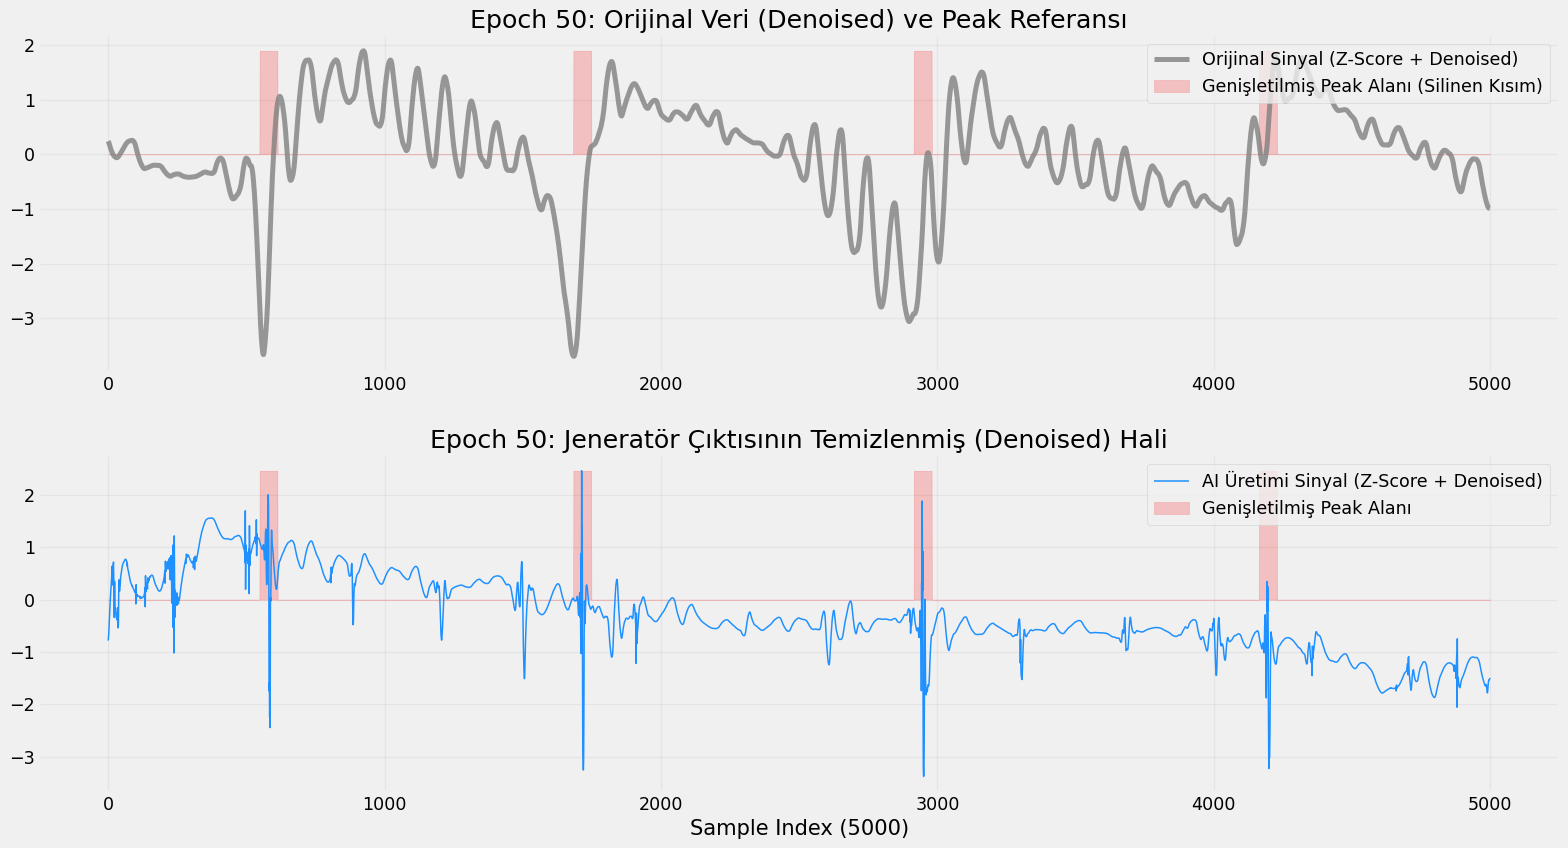

💾 Epoch 50 görselleri ve ağırlıkları kaydedildi.
--- EPOCH 51 BAŞLADI ---
Epoch 51 | Step 427/428 | D_Loss: 0.6504 | G_Total: 7.02
Epoch 51 Özet | D_Loss: 0.6505 | G_Total: 5.95 | Rec: 7.02 | Cls: 0.00
--- EPOCH 52 BAŞLADI ---
Epoch 52 | Step 427/428 | D_Loss: 0.6505 | G_Total: 6.30
Epoch 52 Özet | D_Loss: 0.6504 | G_Total: 5.82 | Rec: 6.30 | Cls: 0.00
Yeni En Düşük G_Loss! (Best Epoch şu an: 52)
--- EPOCH 53 BAŞLADI ---
Epoch 53 | Step 427/428 | D_Loss: 0.6504 | G_Total: 7.512
Epoch 53 Özet | D_Loss: 0.6504 | G_Total: 5.76 | Rec: 7.51 | Cls: 0.00
Yeni En Düşük G_Loss! (Best Epoch şu an: 53)
--- EPOCH 54 BAŞLADI ---
Epoch 54 | Step 427/428 | D_Loss: 0.6504 | G_Total: 6.14
Epoch 54 Özet | D_Loss: 0.6504 | G_Total: 5.70 | Rec: 6.14 | Cls: -0.00
Yeni En Düşük G_Loss! (Best Epoch şu an: 54)
--- EPOCH 55 BAŞLADI ---
Epoch 55 | Step 427/428 | D_Loss: 0.6504 | G_Total: 7.45
Epoch 55 Özet | D_Loss: 0.6504 | G_Total: 5.73 | Rec: 7.45 | Cls: 0.00


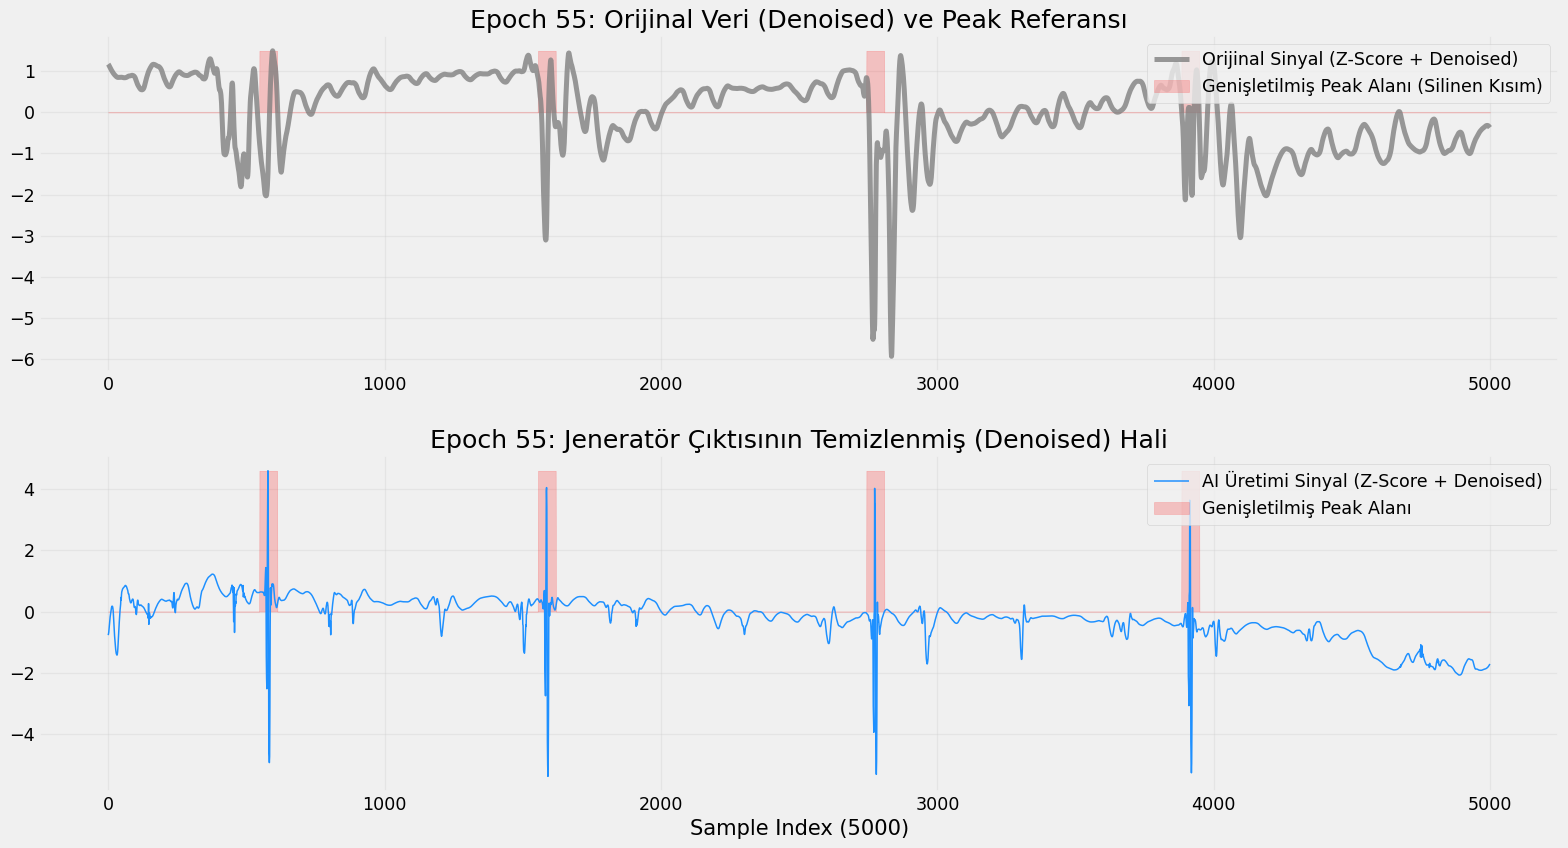

💾 Epoch 55 görselleri ve ağırlıkları kaydedildi.
--- EPOCH 56 BAŞLADI ---
Epoch 56 | Step 427/428 | D_Loss: 0.6504 | G_Total: 7.43
Epoch 56 Özet | D_Loss: 0.6504 | G_Total: 5.62 | Rec: 7.43 | Cls: -0.00
Yeni En Düşük G_Loss! (Best Epoch şu an: 56)
--- EPOCH 57 BAŞLADI ---
Epoch 57 | Step 427/428 | D_Loss: 0.6503 | G_Total: 5.61
Epoch 57 Özet | D_Loss: 0.6504 | G_Total: 5.55 | Rec: 5.61 | Cls: 0.00
Yeni En Düşük G_Loss! (Best Epoch şu an: 57)
--- EPOCH 58 BAŞLADI ---
Epoch 58 | Step 427/428 | D_Loss: 0.6504 | G_Total: 7.49
Epoch 58 Özet | D_Loss: 0.6504 | G_Total: 5.44 | Rec: 7.49 | Cls: -0.00
Yeni En Düşük G_Loss! (Best Epoch şu an: 58)
--- EPOCH 59 BAŞLADI ---
Epoch 59 | Step 427/428 | D_Loss: 0.6504 | G_Total: 5.694
Epoch 59 Özet | D_Loss: 0.6504 | G_Total: 5.45 | Rec: 5.69 | Cls: 0.00
--- EPOCH 60 BAŞLADI ---
Epoch 60 | Step 427/428 | D_Loss: 0.6504 | G_Total: 6.37
Epoch 60 Özet | D_Loss: 0.6503 | G_Total: 5.36 | Rec: 6.37 | Cls: 0.00
Yeni En Düşük G_Loss! (Best Epoch şu an: 60)


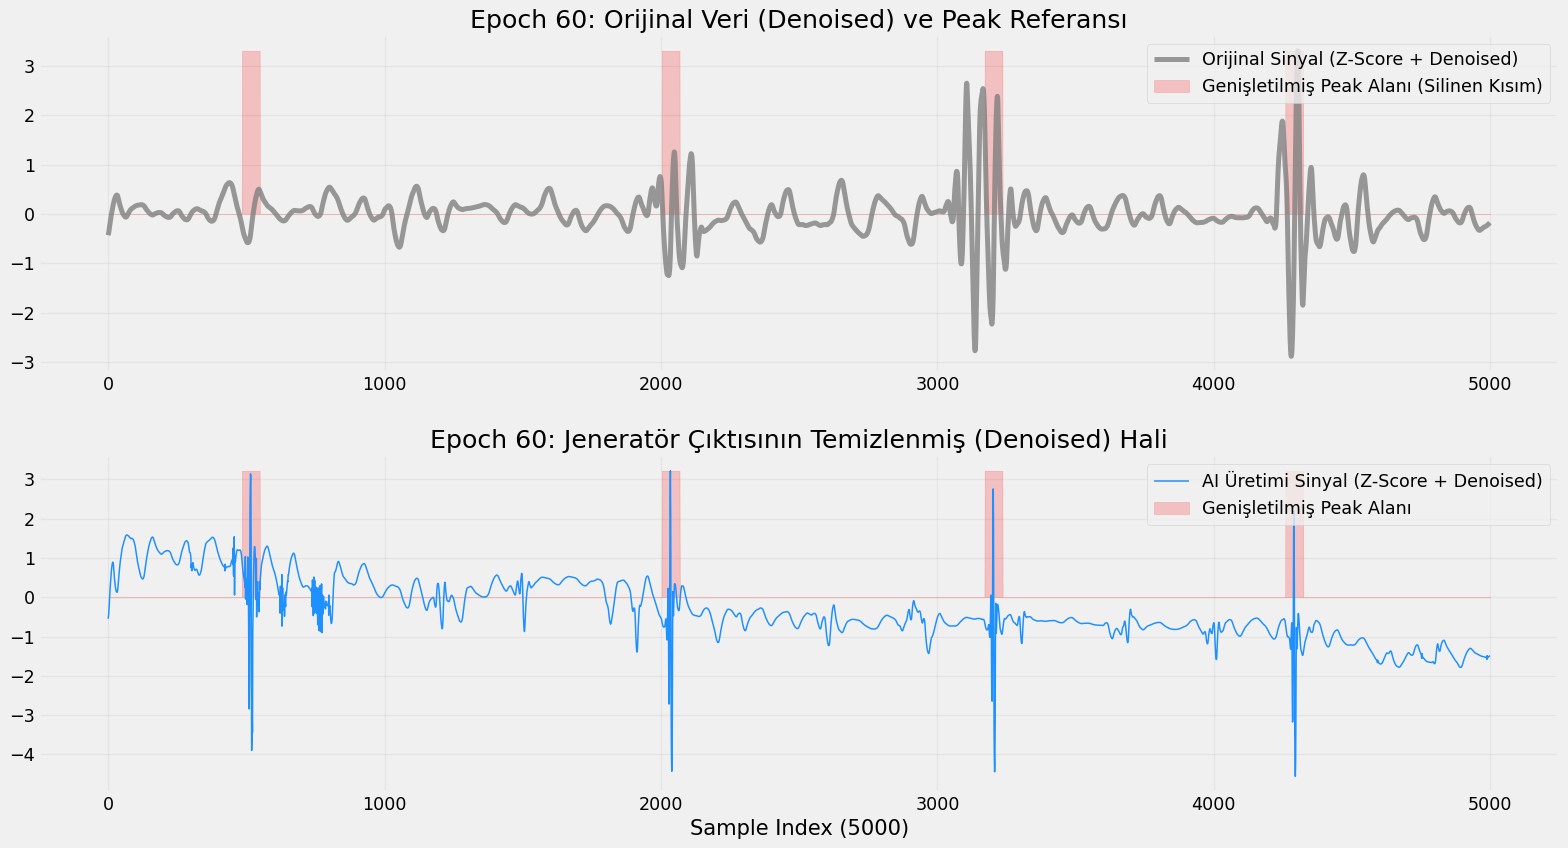

💾 Epoch 60 görselleri ve ağırlıkları kaydedildi.
--- EPOCH 61 BAŞLADI ---
Epoch 61 | Step 427/428 | D_Loss: 0.6503 | G_Total: 6.06
Epoch 61 Özet | D_Loss: 0.6503 | G_Total: 5.31 | Rec: 6.06 | Cls: -0.00
Yeni En Düşük G_Loss! (Best Epoch şu an: 61)
--- EPOCH 62 BAŞLADI ---
Epoch 62 | Step 427/428 | D_Loss: 0.6503 | G_Total: 5.28
Epoch 62 Özet | D_Loss: 0.6503 | G_Total: 5.24 | Rec: 5.28 | Cls: -0.00
Yeni En Düşük G_Loss! (Best Epoch şu an: 62)
--- EPOCH 63 BAŞLADI ---
Epoch 63 | Step 427/428 | D_Loss: 0.6505 | G_Total: 5.867
Epoch 63 Özet | D_Loss: 0.6526 | G_Total: 5.38 | Rec: 5.86 | Cls: 0.00
--- EPOCH 64 BAŞLADI ---
Epoch 64 | Step 427/428 | D_Loss: 0.6503 | G_Total: 5.99
Epoch 64 Özet | D_Loss: 0.6504 | G_Total: 5.24 | Rec: 5.99 | Cls: 0.00
--- EPOCH 65 BAŞLADI ---
Epoch 65 | Step 427/428 | D_Loss: 0.6503 | G_Total: 5.09
Epoch 65 Özet | D_Loss: 0.6503 | G_Total: 5.16 | Rec: 5.09 | Cls: 0.00
Yeni En Düşük G_Loss! (Best Epoch şu an: 65)


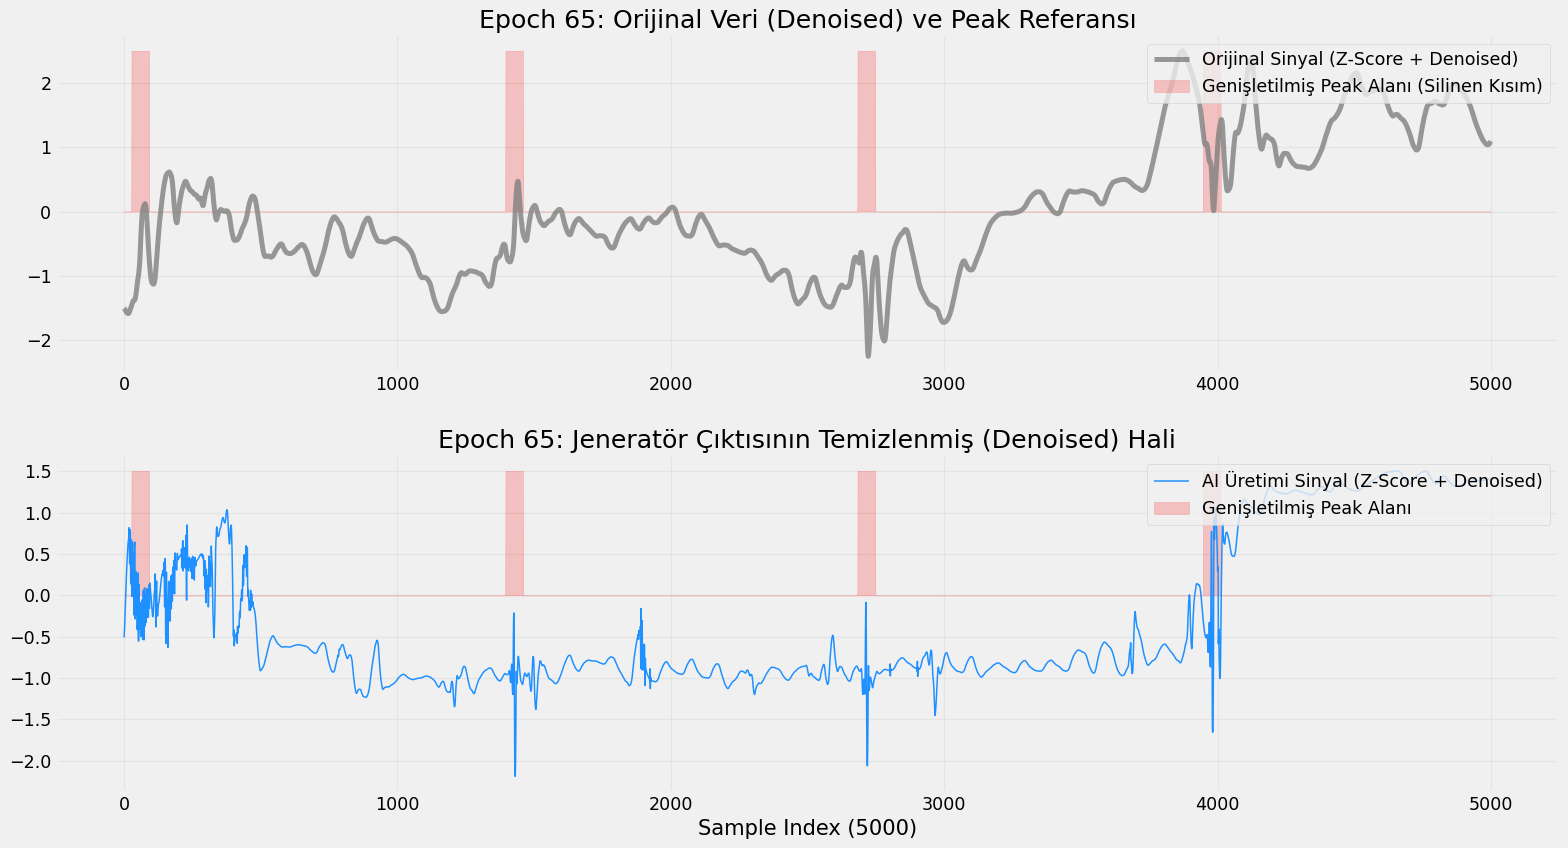

💾 Epoch 65 görselleri ve ağırlıkları kaydedildi.
--- EPOCH 66 BAŞLADI ---
Epoch 66 | Step 427/428 | D_Loss: 0.6503 | G_Total: 5.49
Epoch 66 Özet | D_Loss: 0.6503 | G_Total: 5.10 | Rec: 5.49 | Cls: -0.00
Yeni En Düşük G_Loss! (Best Epoch şu an: 66)
--- EPOCH 67 BAŞLADI ---
Epoch 67 | Step 427/428 | D_Loss: 0.6504 | G_Total: 6.54
Epoch 67 Özet | D_Loss: 0.6503 | G_Total: 5.15 | Rec: 6.54 | Cls: 0.00
--- EPOCH 68 BAŞLADI ---
Epoch 68 | Step 427/428 | D_Loss: 0.6504 | G_Total: 4.80
Epoch 68 Özet | D_Loss: 0.6503 | G_Total: 5.06 | Rec: 4.80 | Cls: 0.00
Yeni En Düşük G_Loss! (Best Epoch şu an: 68)
--- EPOCH 69 BAŞLADI ---
Epoch 69 | Step 427/428 | D_Loss: 0.6503 | G_Total: 5.27
Epoch 69 Özet | D_Loss: 0.6503 | G_Total: 5.06 | Rec: 5.27 | Cls: -0.00
Yeni En Düşük G_Loss! (Best Epoch şu an: 69)
--- EPOCH 70 BAŞLADI ---
Epoch 70 | Step 427/428 | D_Loss: 0.6506 | G_Total: 4.95
Epoch 70 Özet | D_Loss: 0.6503 | G_Total: 4.99 | Rec: 4.95 | Cls: 0.00
Yeni En Düşük G_Loss! (Best Epoch şu an: 70)


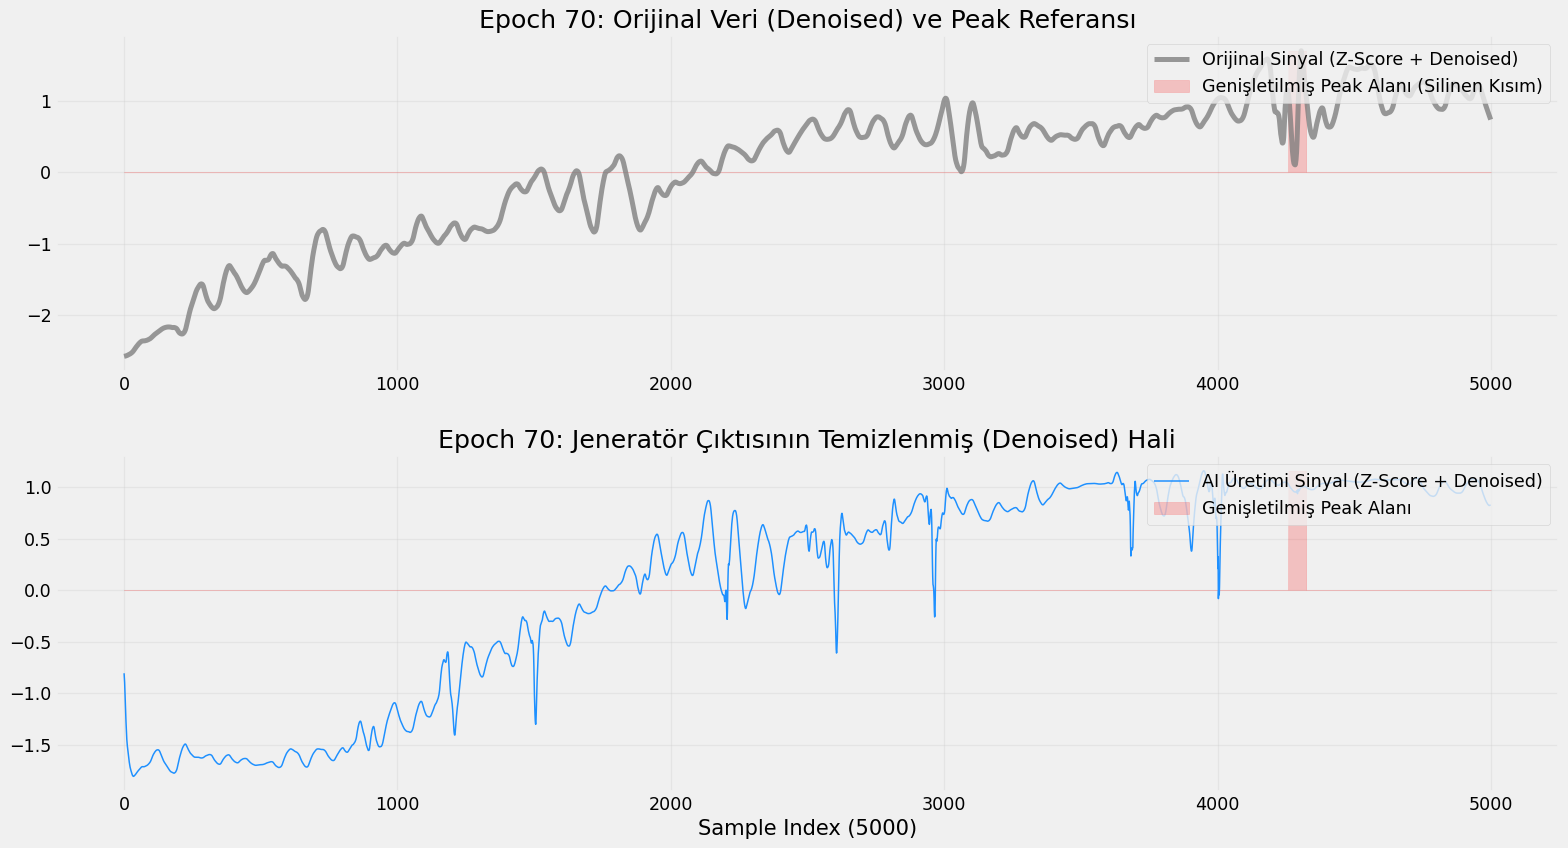

💾 Epoch 70 görselleri ve ağırlıkları kaydedildi.
--- EPOCH 71 BAŞLADI ---
Epoch 71 | Step 427/428 | D_Loss: 0.6503 | G_Total: 6.27
Epoch 71 Özet | D_Loss: 0.6503 | G_Total: 4.97 | Rec: 6.27 | Cls: -0.00
Yeni En Düşük G_Loss! (Best Epoch şu an: 71)
--- EPOCH 72 BAŞLADI ---
Epoch 72 | Step 427/428 | D_Loss: 0.6503 | G_Total: 5.26
Epoch 72 Özet | D_Loss: 0.6503 | G_Total: 4.95 | Rec: 5.26 | Cls: 0.00
Yeni En Düşük G_Loss! (Best Epoch şu an: 72)
--- EPOCH 73 BAŞLADI ---
Epoch 73 | Step 427/428 | D_Loss: 0.6503 | G_Total: 5.28
Epoch 73 Özet | D_Loss: 0.6503 | G_Total: 4.96 | Rec: 5.28 | Cls: -0.00
--- EPOCH 74 BAŞLADI ---
Epoch 74 | Step 427/428 | D_Loss: 0.6502 | G_Total: 4.90
Epoch 74 Özet | D_Loss: 0.6503 | G_Total: 4.90 | Rec: 4.90 | Cls: 0.00
Yeni En Düşük G_Loss! (Best Epoch şu an: 74)
--- EPOCH 75 BAŞLADI ---
Epoch 75 | Step 427/428 | D_Loss: 0.6503 | G_Total: 4.84
Epoch 75 Özet | D_Loss: 0.6515 | G_Total: 4.95 | Rec: 4.84 | Cls: 0.00


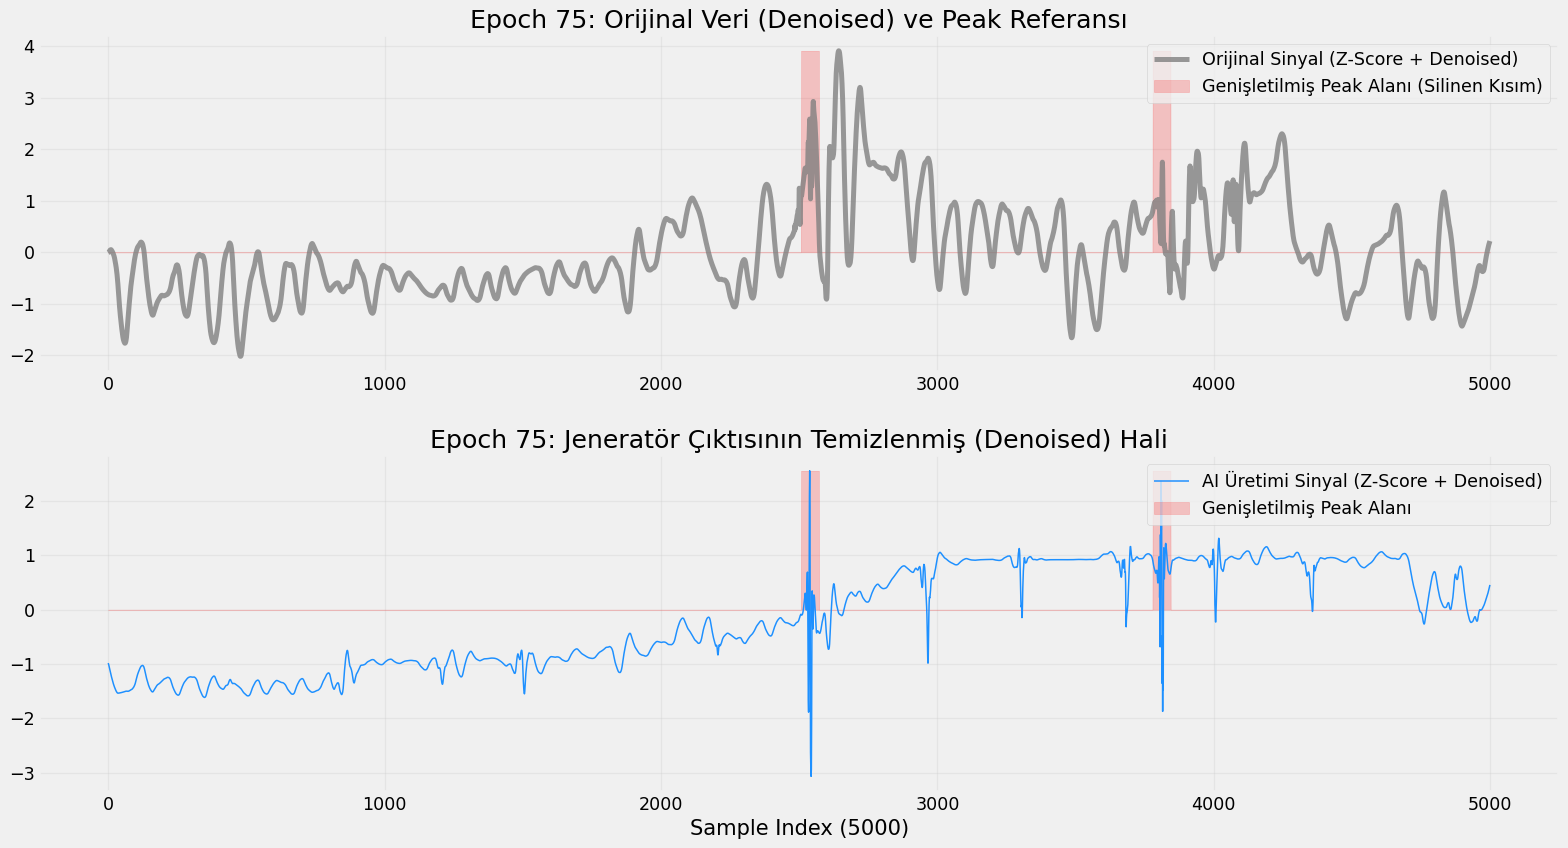

💾 Epoch 75 görselleri ve ağırlıkları kaydedildi.
--- EPOCH 76 BAŞLADI ---
Epoch 76 | Step 427/428 | D_Loss: 0.6504 | G_Total: 4.59
Epoch 76 Özet | D_Loss: 0.6503 | G_Total: 4.89 | Rec: 4.59 | Cls: -0.00
Yeni En Düşük G_Loss! (Best Epoch şu an: 76)
--- EPOCH 77 BAŞLADI ---
Epoch 77 | Step 427/428 | D_Loss: 0.6561 | G_Total: 5.12
Epoch 77 Özet | D_Loss: 0.6505 | G_Total: 4.76 | Rec: 5.12 | Cls: -0.00
Yeni En Düşük G_Loss! (Best Epoch şu an: 77)
--- EPOCH 78 BAŞLADI ---
Epoch 78 | Step 427/428 | D_Loss: 0.6502 | G_Total: 6.35
Epoch 78 Özet | D_Loss: 0.6505 | G_Total: 4.92 | Rec: 6.35 | Cls: 0.00
--- EPOCH 79 BAŞLADI ---
Epoch 79 | Step 427/428 | D_Loss: 0.6503 | G_Total: 4.88
Epoch 79 Özet | D_Loss: 0.6503 | G_Total: 4.80 | Rec: 4.88 | Cls: -0.00
--- EPOCH 80 BAŞLADI ---
Epoch 80 | Step 427/428 | D_Loss: 0.6502 | G_Total: 5.28
Epoch 80 Özet | D_Loss: 0.6503 | G_Total: 4.79 | Rec: 5.28 | Cls: -0.00


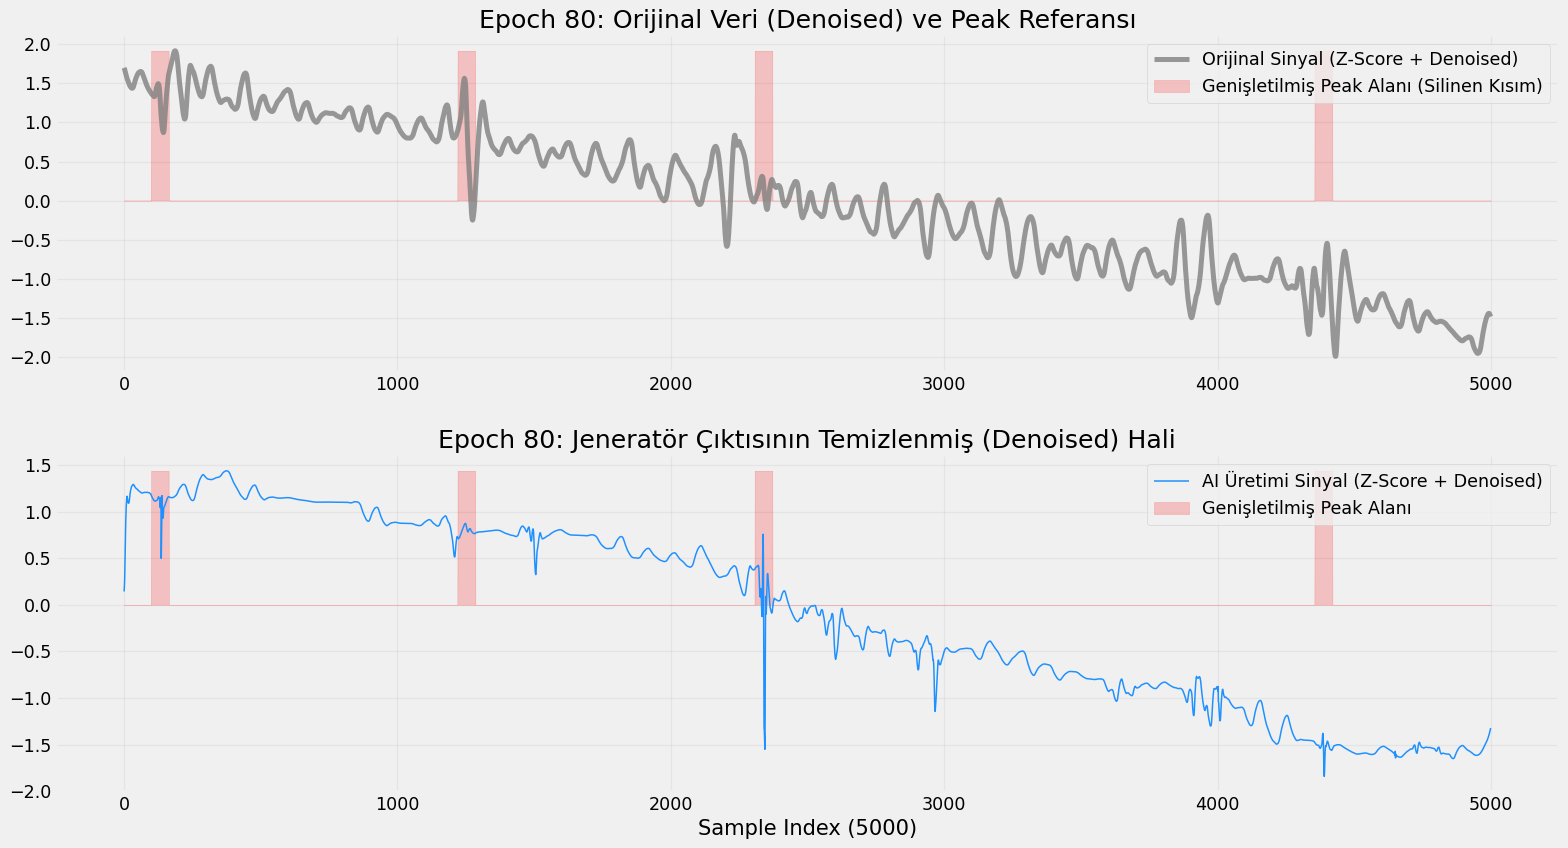

💾 Epoch 80 görselleri ve ağırlıkları kaydedildi.
--- EPOCH 81 BAŞLADI ---
Epoch 81 | Step 427/428 | D_Loss: 0.6502 | G_Total: 5.16
Epoch 81 Özet | D_Loss: 0.6503 | G_Total: 4.72 | Rec: 5.16 | Cls: 0.00
Yeni En Düşük G_Loss! (Best Epoch şu an: 81)
--- EPOCH 82 BAŞLADI ---
Epoch 82 | Step 427/428 | D_Loss: 0.6507 | G_Total: 5.43
Epoch 82 Özet | D_Loss: 0.6503 | G_Total: 4.74 | Rec: 5.43 | Cls: 0.00
--- EPOCH 83 BAŞLADI ---
Epoch 83 | Step 427/428 | D_Loss: 0.6503 | G_Total: 4.56
Epoch 83 Özet | D_Loss: 0.6503 | G_Total: 4.72 | Rec: 4.56 | Cls: -0.00
Yeni En Düşük G_Loss! (Best Epoch şu an: 83)
--- EPOCH 84 BAŞLADI ---
Epoch 84 | Step 427/428 | D_Loss: 0.6503 | G_Total: 4.72
Epoch 84 Özet | D_Loss: 0.6503 | G_Total: 4.71 | Rec: 4.72 | Cls: -0.00
Yeni En Düşük G_Loss! (Best Epoch şu an: 84)
--- EPOCH 85 BAŞLADI ---
Epoch 85 | Step 427/428 | D_Loss: 0.6504 | G_Total: 5.79
Epoch 85 Özet | D_Loss: 0.6503 | G_Total: 4.73 | Rec: 5.79 | Cls: 0.00


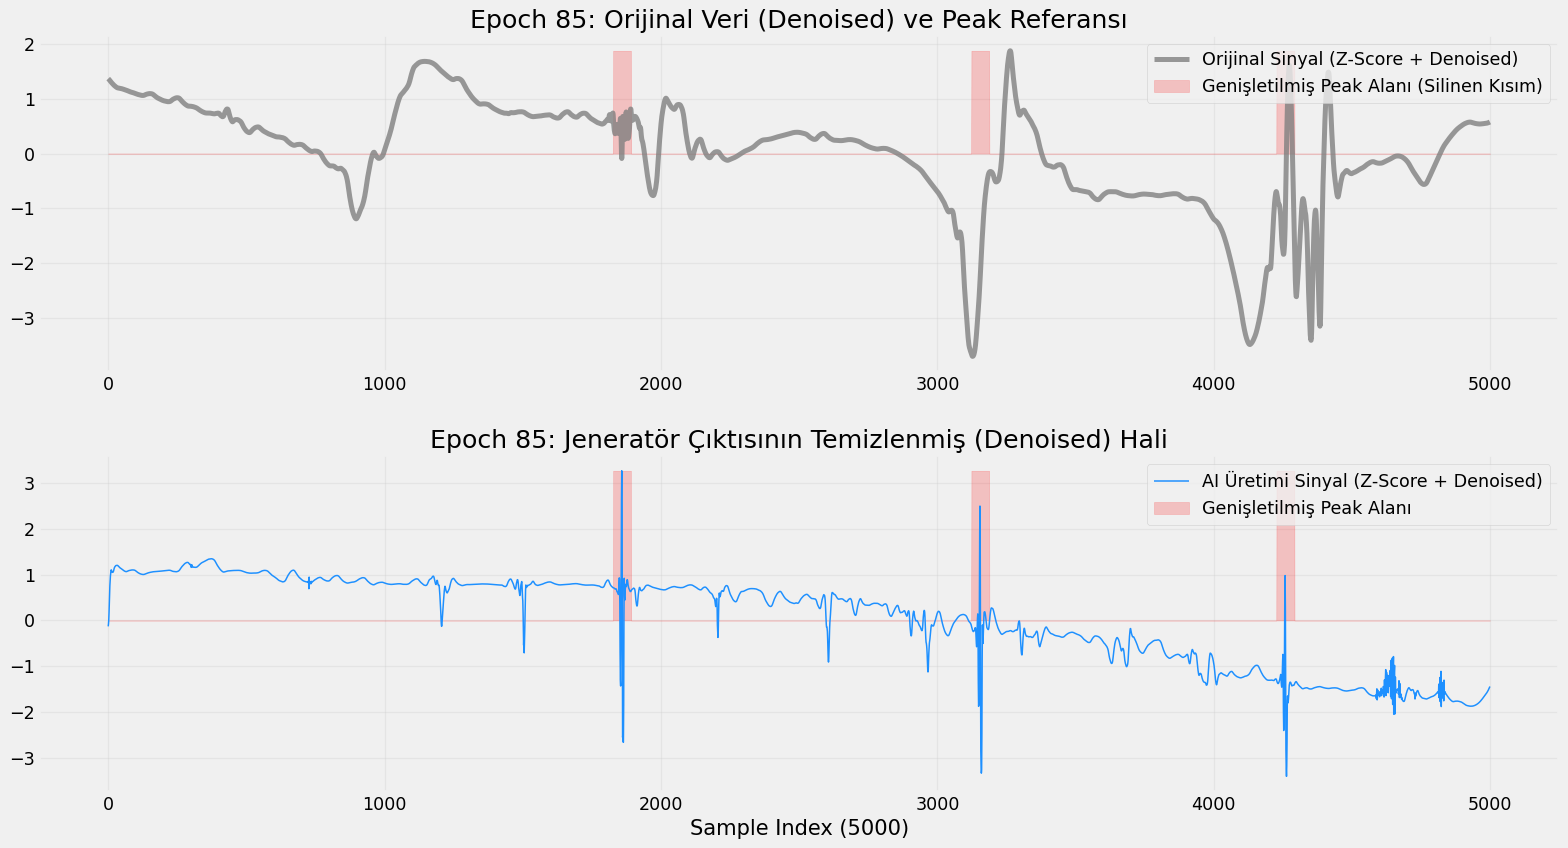

💾 Epoch 85 görselleri ve ağırlıkları kaydedildi.
--- EPOCH 86 BAŞLADI ---
Epoch 86 | Step 427/428 | D_Loss: 0.6502 | G_Total: 5.08
Epoch 86 Özet | D_Loss: 0.6503 | G_Total: 4.65 | Rec: 5.08 | Cls: -0.00
Yeni En Düşük G_Loss! (Best Epoch şu an: 86)
--- EPOCH 87 BAŞLADI ---
Epoch 87 | Step 427/428 | D_Loss: 0.6503 | G_Total: 4.84
Epoch 87 Özet | D_Loss: 0.6503 | G_Total: 4.66 | Rec: 4.84 | Cls: 0.00
--- EPOCH 88 BAŞLADI ---
Epoch 88 | Step 427/428 | D_Loss: 0.6502 | G_Total: 4.40
Epoch 88 Özet | D_Loss: 0.6503 | G_Total: 4.62 | Rec: 4.40 | Cls: 0.00
Yeni En Düşük G_Loss! (Best Epoch şu an: 88)
--- EPOCH 89 BAŞLADI ---
Epoch 89 | Step 427/428 | D_Loss: 0.6502 | G_Total: 4.69
Epoch 89 Özet | D_Loss: 0.6503 | G_Total: 4.53 | Rec: 4.69 | Cls: 0.00
Yeni En Düşük G_Loss! (Best Epoch şu an: 89)
--- EPOCH 90 BAŞLADI ---
Epoch 90 | Step 427/428 | D_Loss: 0.6502 | G_Total: 4.59
Epoch 90 Özet | D_Loss: 0.6506 | G_Total: 4.56 | Rec: 4.59 | Cls: -0.00


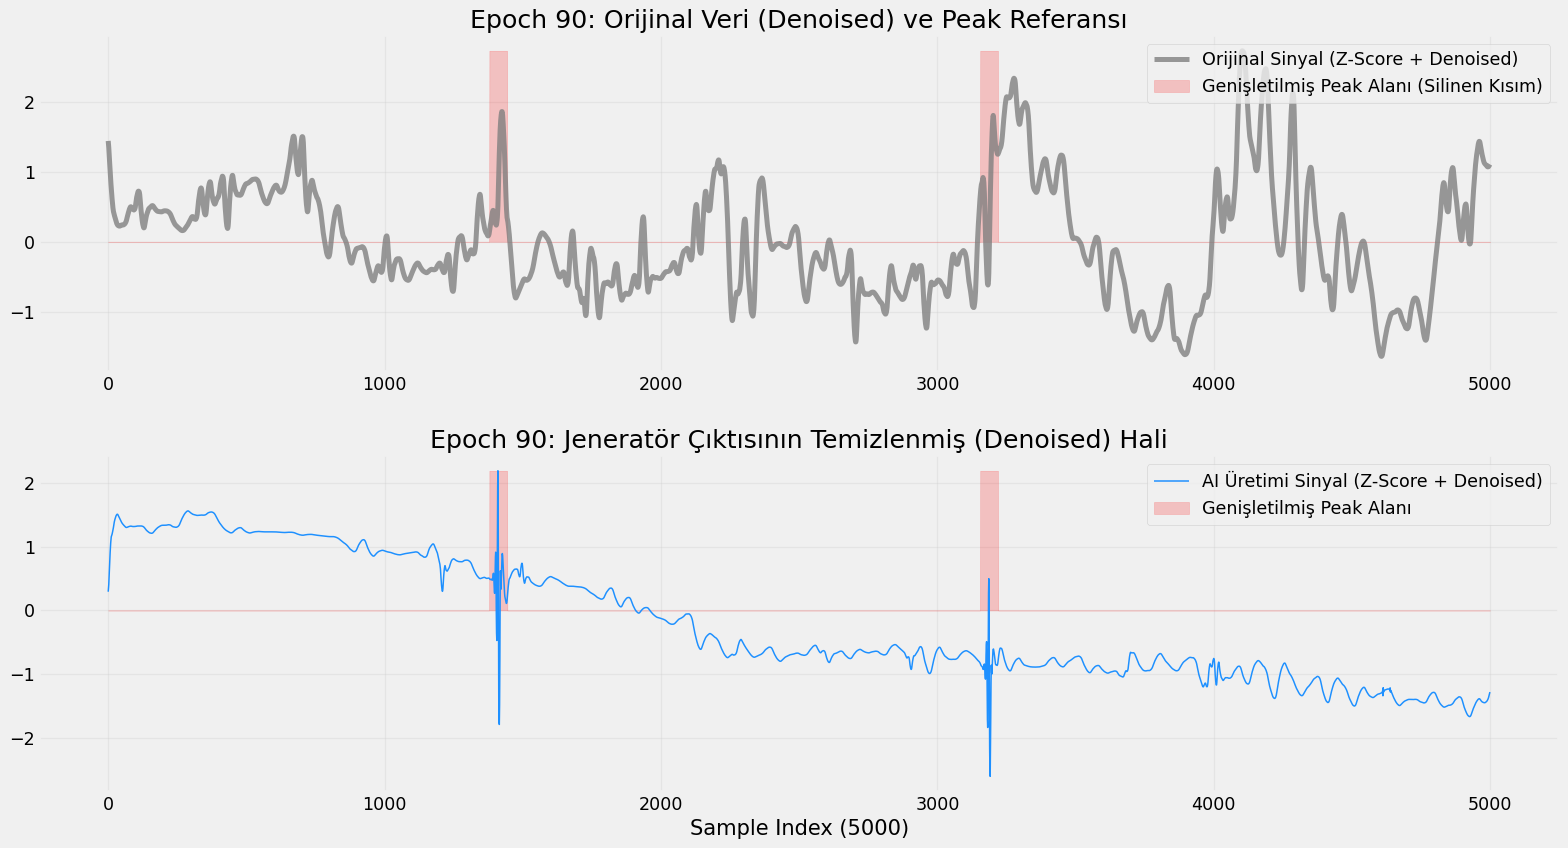

💾 Epoch 90 görselleri ve ağırlıkları kaydedildi.
--- EPOCH 91 BAŞLADI ---
Epoch 91 | Step 427/428 | D_Loss: 0.6503 | G_Total: 5.44
Epoch 91 Özet | D_Loss: 0.6503 | G_Total: 4.54 | Rec: 5.44 | Cls: -0.00
--- EPOCH 92 BAŞLADI ---
Epoch 92 | Step 427/428 | D_Loss: 0.6503 | G_Total: 4.77
Epoch 92 Özet | D_Loss: 0.6502 | G_Total: 4.53 | Rec: 4.77 | Cls: 0.00
Yeni En Düşük G_Loss! (Best Epoch şu an: 92)
--- EPOCH 93 BAŞLADI ---
Epoch 93 | Step 427/428 | D_Loss: 0.6506 | G_Total: 4.30
Epoch 93 Özet | D_Loss: 0.6502 | G_Total: 4.46 | Rec: 4.30 | Cls: -0.00
Yeni En Düşük G_Loss! (Best Epoch şu an: 93)
--- EPOCH 94 BAŞLADI ---
Epoch 94 | Step 427/428 | D_Loss: 0.6502 | G_Total: 5.21
Epoch 94 Özet | D_Loss: 0.6503 | G_Total: 4.94 | Rec: 5.21 | Cls: -0.00
--- EPOCH 95 BAŞLADI ---
Epoch 95 | Step 427/428 | D_Loss: 0.6503 | G_Total: 4.68
Epoch 95 Özet | D_Loss: 0.6502 | G_Total: 4.55 | Rec: 4.68 | Cls: 0.00


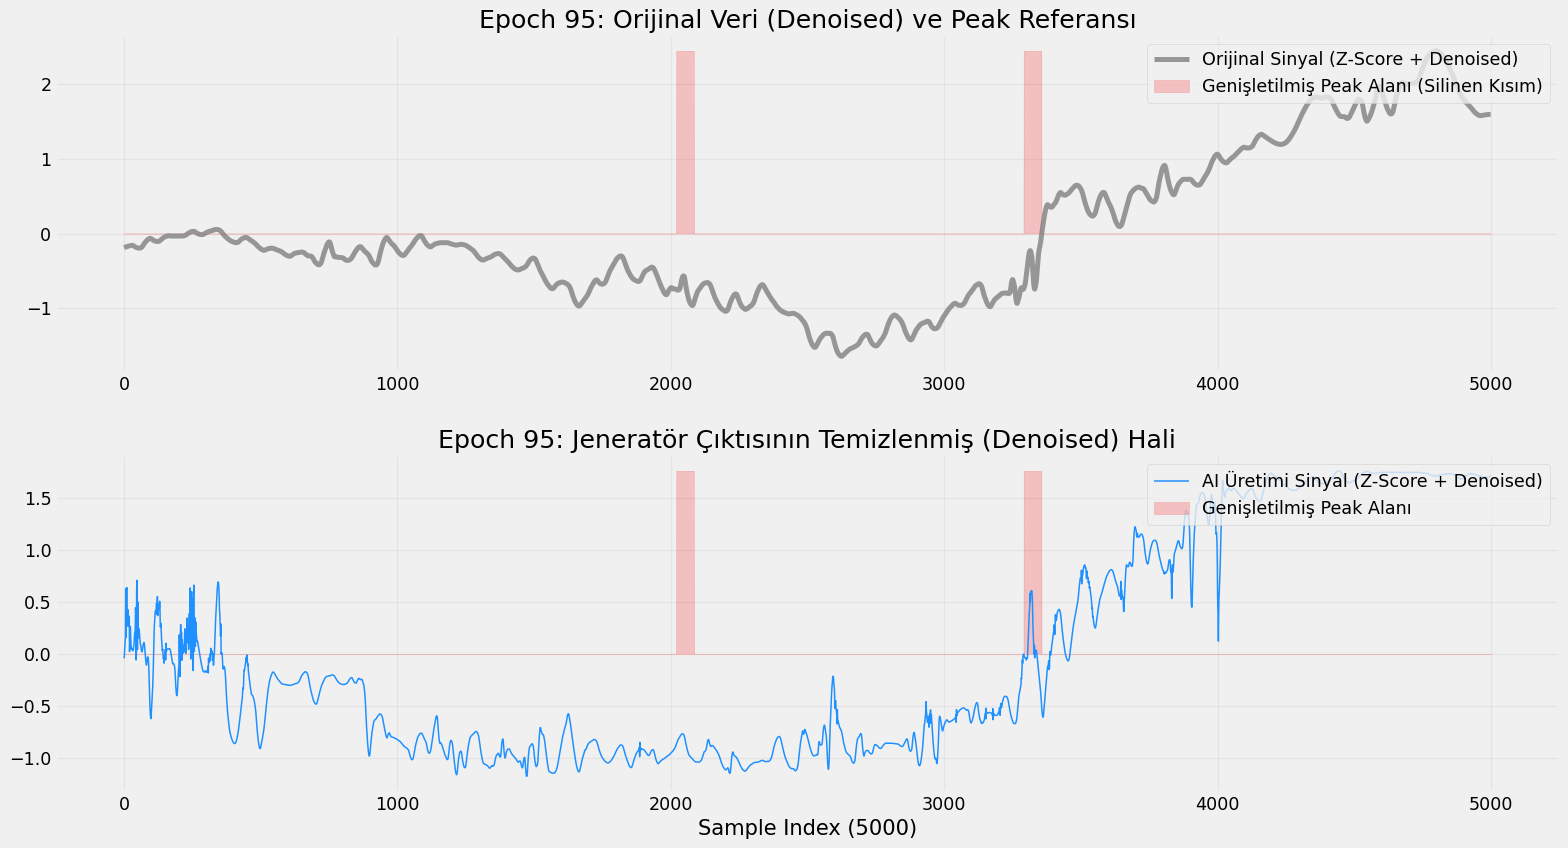

💾 Epoch 95 görselleri ve ağırlıkları kaydedildi.
--- EPOCH 96 BAŞLADI ---
Epoch 96 | Step 427/428 | D_Loss: 0.6502 | G_Total: 3.94
Epoch 96 Özet | D_Loss: 0.6502 | G_Total: 4.52 | Rec: 3.94 | Cls: -0.00
--- EPOCH 97 BAŞLADI ---
Epoch 97 | Step 427/428 | D_Loss: 0.6503 | G_Total: 4.68
Epoch 97 Özet | D_Loss: 0.6502 | G_Total: 4.49 | Rec: 4.68 | Cls: 0.00
--- EPOCH 98 BAŞLADI ---
Epoch 98 | Step 427/428 | D_Loss: 0.6502 | G_Total: 5.08
Epoch 98 Özet | D_Loss: 0.6502 | G_Total: 4.45 | Rec: 5.03 | Cls: 0.10
Yeni En Düşük G_Loss! (Best Epoch şu an: 98)
--- EPOCH 99 BAŞLADI ---
Epoch 99 | Step 427/428 | D_Loss: 0.6502 | G_Total: 4.96
Epoch 99 Özet | D_Loss: 0.6502 | G_Total: 4.48 | Rec: 4.96 | Cls: -0.00
--- EPOCH 100 BAŞLADI ---
Epoch 100 | Step 427/428 | D_Loss: 0.6502 | G_Total: 5.01
Epoch 100 Özet | D_Loss: 0.6503 | G_Total: 4.50 | Rec: 5.01 | Cls: 0.00


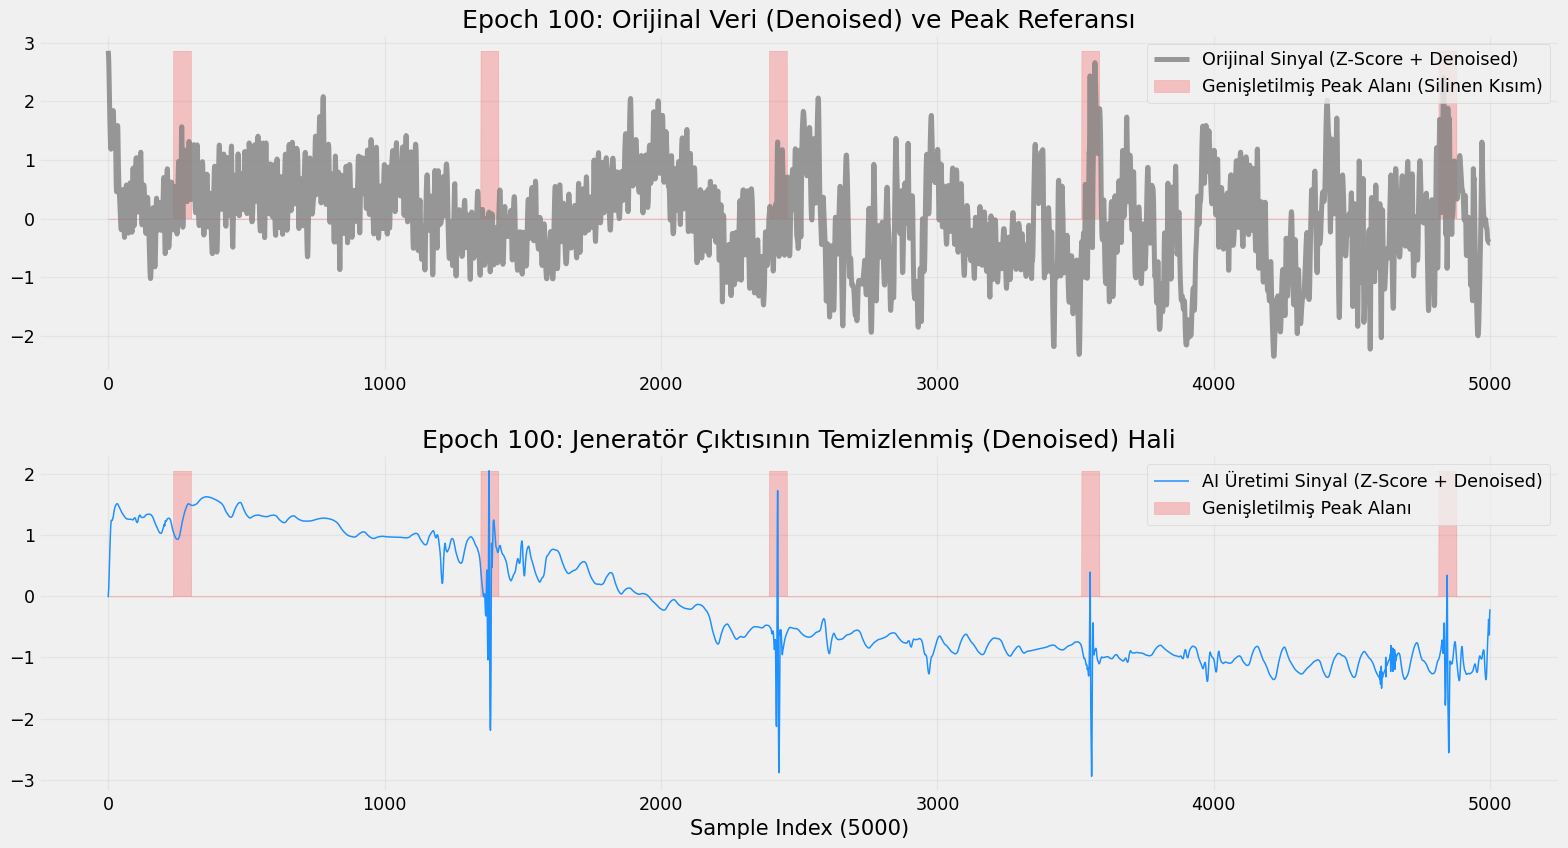

💾 Epoch 100 görselleri ve ağırlıkları kaydedildi.
--- EPOCH 101 BAŞLADI ---
Epoch 101 | Step 427/428 | D_Loss: 0.6503 | G_Total: 4.65
Epoch 101 Özet | D_Loss: 0.6502 | G_Total: 4.50 | Rec: 4.65 | Cls: -0.00
--- EPOCH 102 BAŞLADI ---
Epoch 102 | Step 427/428 | D_Loss: 0.6502 | G_Total: 4.63
Epoch 102 Özet | D_Loss: 0.6502 | G_Total: 4.40 | Rec: 4.63 | Cls: 0.00
Yeni En Düşük G_Loss! (Best Epoch şu an: 102)
--- EPOCH 103 BAŞLADI ---
Epoch 103 | Step 427/428 | D_Loss: 0.6506 | G_Total: 4.30
Epoch 103 Özet | D_Loss: 0.6517 | G_Total: 4.37 | Rec: 4.30 | Cls: -0.00
Yeni En Düşük G_Loss! (Best Epoch şu an: 103)
--- EPOCH 104 BAŞLADI ---
Epoch 104 | Step 427/428 | D_Loss: 0.6503 | G_Total: 4.48
Epoch 104 Özet | D_Loss: 0.6503 | G_Total: 4.36 | Rec: 4.48 | Cls: 0.00
Yeni En Düşük G_Loss! (Best Epoch şu an: 104)
--- EPOCH 105 BAŞLADI ---
Epoch 105 | Step 427/428 | D_Loss: 0.6503 | G_Total: 4.49
Epoch 105 Özet | D_Loss: 0.6502 | G_Total: 4.34 | Rec: 4.49 | Cls: 0.01
Yeni En Düşük G_Loss! (Best Ep

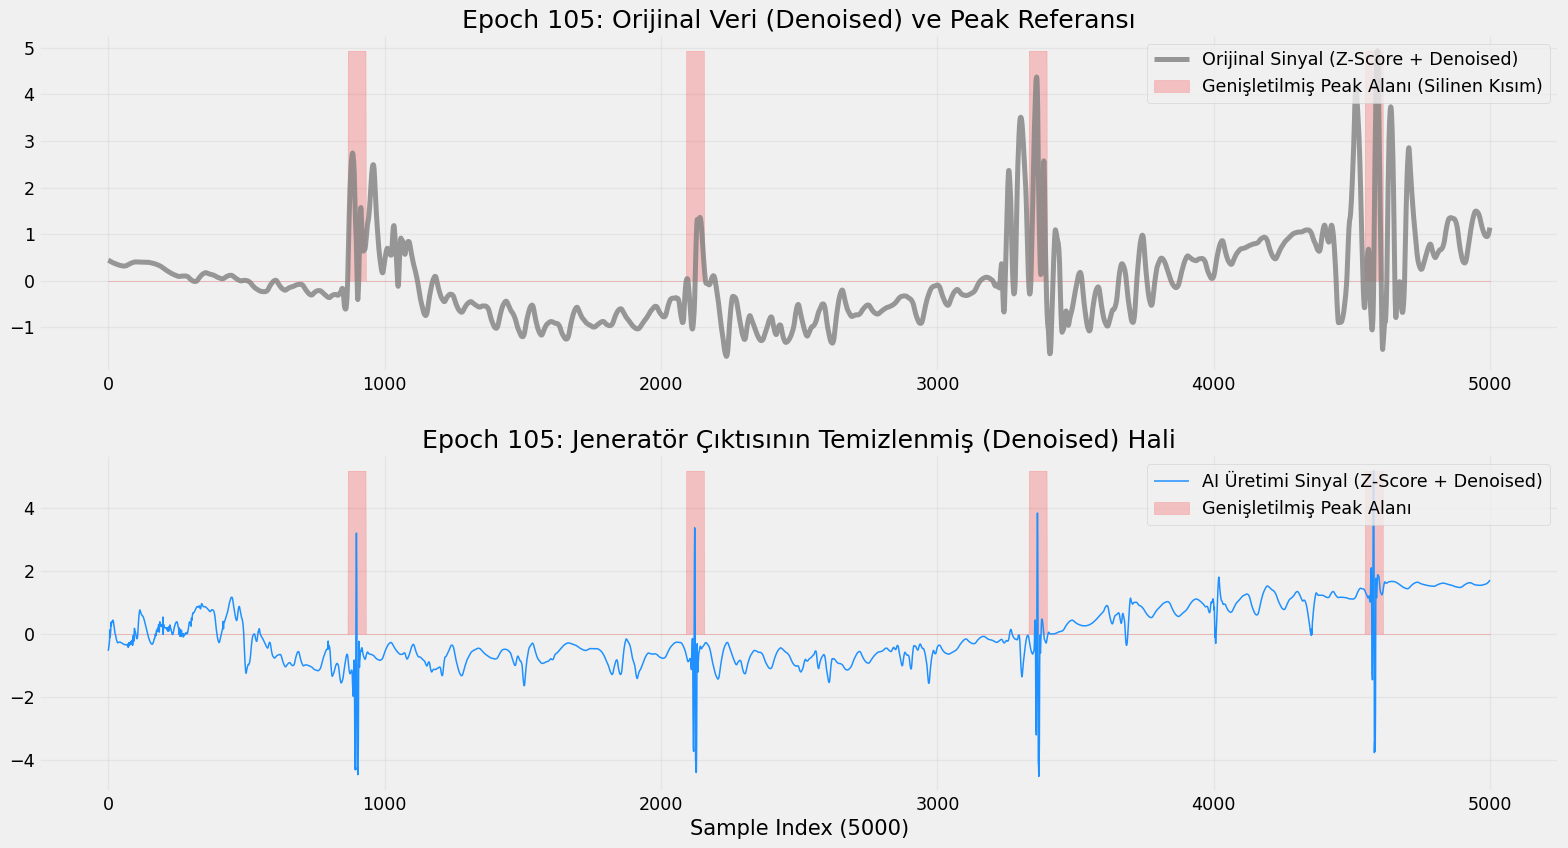

💾 Epoch 105 görselleri ve ağırlıkları kaydedildi.
--- EPOCH 106 BAŞLADI ---
Epoch 106 | Step 427/428 | D_Loss: 0.6503 | G_Total: 4.30
Epoch 106 Özet | D_Loss: 0.6502 | G_Total: 4.34 | Rec: 4.30 | Cls: -0.00
Yeni En Düşük G_Loss! (Best Epoch şu an: 106)
--- EPOCH 107 BAŞLADI ---
Epoch 107 | Step 427/428 | D_Loss: 0.6502 | G_Total: 5.37
Epoch 107 Özet | D_Loss: 0.6502 | G_Total: 4.36 | Rec: 5.37 | Cls: 0.00
--- EPOCH 108 BAŞLADI ---
Epoch 108 | Step 427/428 | D_Loss: 0.6502 | G_Total: 4.48
Epoch 108 Özet | D_Loss: 0.6502 | G_Total: 4.36 | Rec: 4.48 | Cls: 0.00
--- EPOCH 109 BAŞLADI ---
Epoch 109 | Step 427/428 | D_Loss: 0.6502 | G_Total: 5.51
Epoch 109 Özet | D_Loss: 0.6502 | G_Total: 4.32 | Rec: 4.65 | Cls: 1.71
Yeni En Düşük G_Loss! (Best Epoch şu an: 109)
--- EPOCH 110 BAŞLADI ---
Epoch 110 | Step 427/428 | D_Loss: 0.6502 | G_Total: 5.00
Epoch 110 Özet | D_Loss: 0.6503 | G_Total: 5.02 | Rec: 5.00 | Cls: 0.00


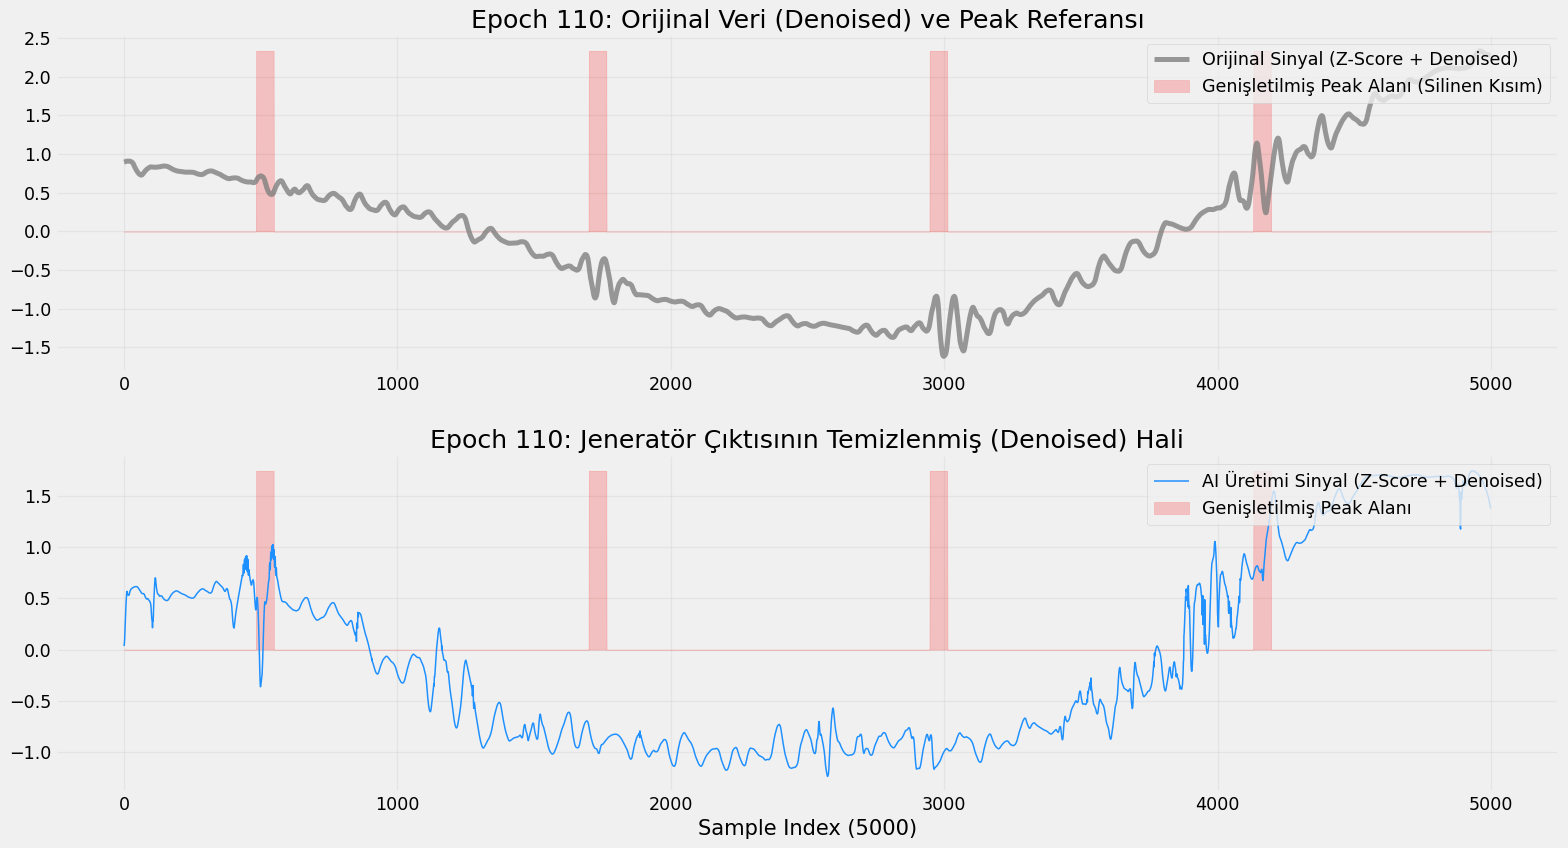

💾 Epoch 110 görselleri ve ağırlıkları kaydedildi.
--- EPOCH 111 BAŞLADI ---
Epoch 111 | Step 427/428 | D_Loss: 0.6503 | G_Total: 4.68
Epoch 111 Özet | D_Loss: 0.6502 | G_Total: 4.32 | Rec: 4.68 | Cls: -0.00
Yeni En Düşük G_Loss! (Best Epoch şu an: 111)
--- EPOCH 112 BAŞLADI ---
Epoch 112 | Step 427/428 | D_Loss: 0.6502 | G_Total: 4.27
Epoch 112 Özet | D_Loss: 0.6502 | G_Total: 4.34 | Rec: 4.27 | Cls: 0.00
--- EPOCH 113 BAŞLADI ---
Epoch 113 | Step 427/428 | D_Loss: 0.6502 | G_Total: 4.82
Epoch 113 Özet | D_Loss: 0.6502 | G_Total: 4.32 | Rec: 4.82 | Cls: 0.00
Yeni En Düşük G_Loss! (Best Epoch şu an: 113)
--- EPOCH 114 BAŞLADI ---
Epoch 114 | Step 427/428 | D_Loss: 0.6504 | G_Total: 4.12
Epoch 114 Özet | D_Loss: 0.6502 | G_Total: 4.32 | Rec: 4.12 | Cls: -0.00
--- EPOCH 115 BAŞLADI ---
Epoch 115 | Step 427/428 | D_Loss: 0.6502 | G_Total: 4.40
Epoch 115 Özet | D_Loss: 0.6502 | G_Total: 4.36 | Rec: 4.40 | Cls: -0.00


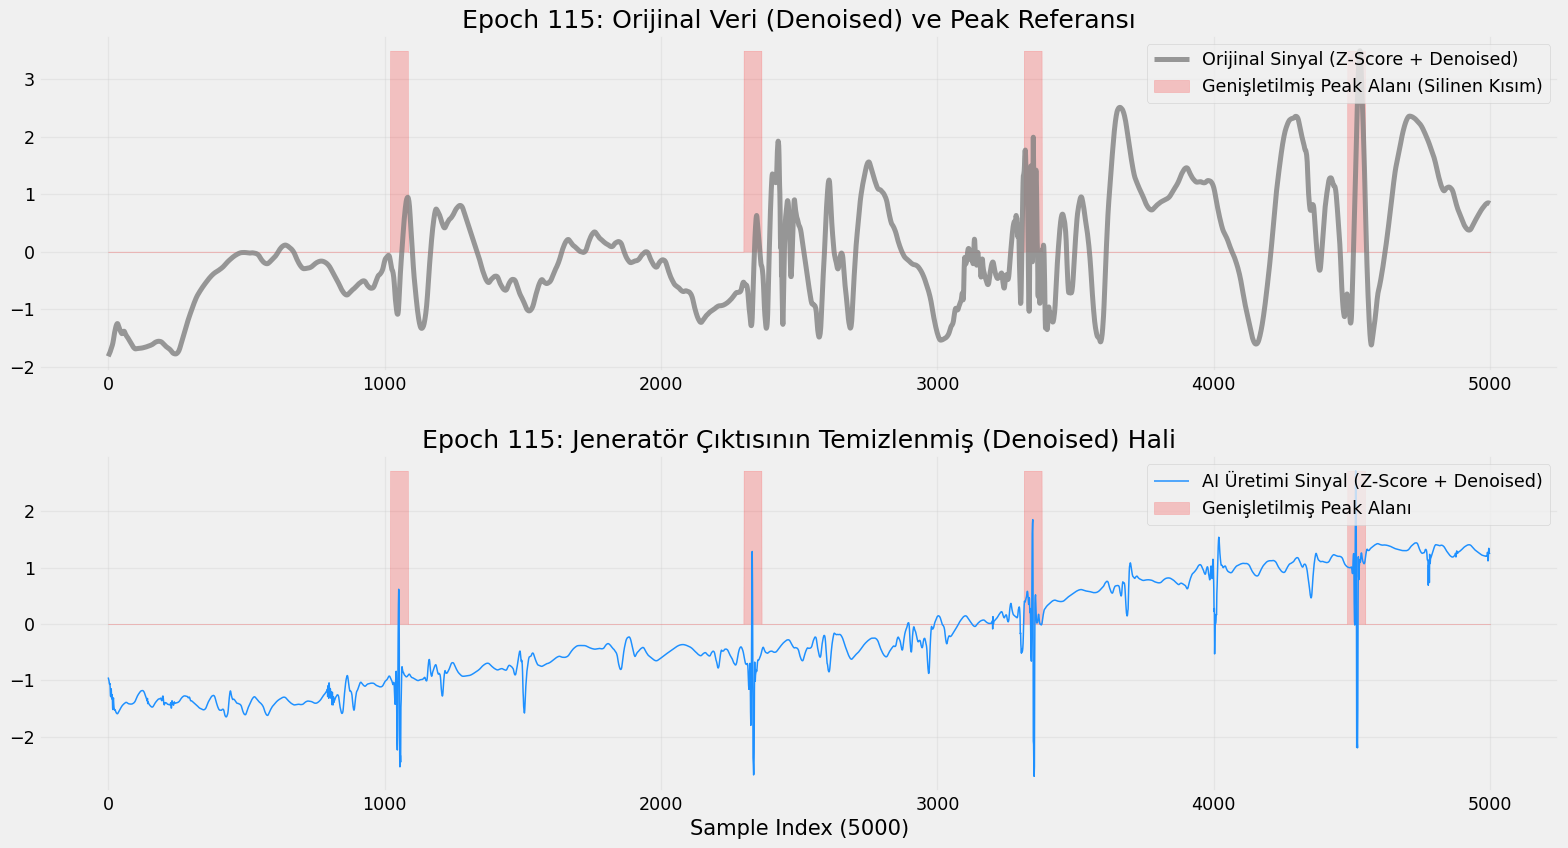

💾 Epoch 115 görselleri ve ağırlıkları kaydedildi.
--- EPOCH 116 BAŞLADI ---
Epoch 116 | Step 427/428 | D_Loss: 0.6502 | G_Total: 4.25
Epoch 116 Özet | D_Loss: 0.6502 | G_Total: 4.27 | Rec: 4.25 | Cls: 0.00
Yeni En Düşük G_Loss! (Best Epoch şu an: 116)
--- EPOCH 117 BAŞLADI ---
Epoch 117 | Step 427/428 | D_Loss: 0.6503 | G_Total: 4.57
Epoch 117 Özet | D_Loss: 0.6502 | G_Total: 4.27 | Rec: 4.57 | Cls: 0.00
--- EPOCH 118 BAŞLADI ---
Epoch 118 | Step 427/428 | D_Loss: 0.6504 | G_Total: 4.24
Epoch 118 Özet | D_Loss: 0.6502 | G_Total: 4.23 | Rec: 4.24 | Cls: 0.00
Yeni En Düşük G_Loss! (Best Epoch şu an: 118)
--- EPOCH 119 BAŞLADI ---
Epoch 119 | Step 427/428 | D_Loss: 0.6502 | G_Total: 4.55
Epoch 119 Özet | D_Loss: 0.6502 | G_Total: 4.23 | Rec: 4.55 | Cls: 0.00
--- EPOCH 120 BAŞLADI ---
Epoch 120 | Step 427/428 | D_Loss: 0.6505 | G_Total: 4.11
Epoch 120 Özet | D_Loss: 0.6507 | G_Total: 4.20 | Rec: 4.11 | Cls: -0.00
Yeni En Düşük G_Loss! (Best Epoch şu an: 120)


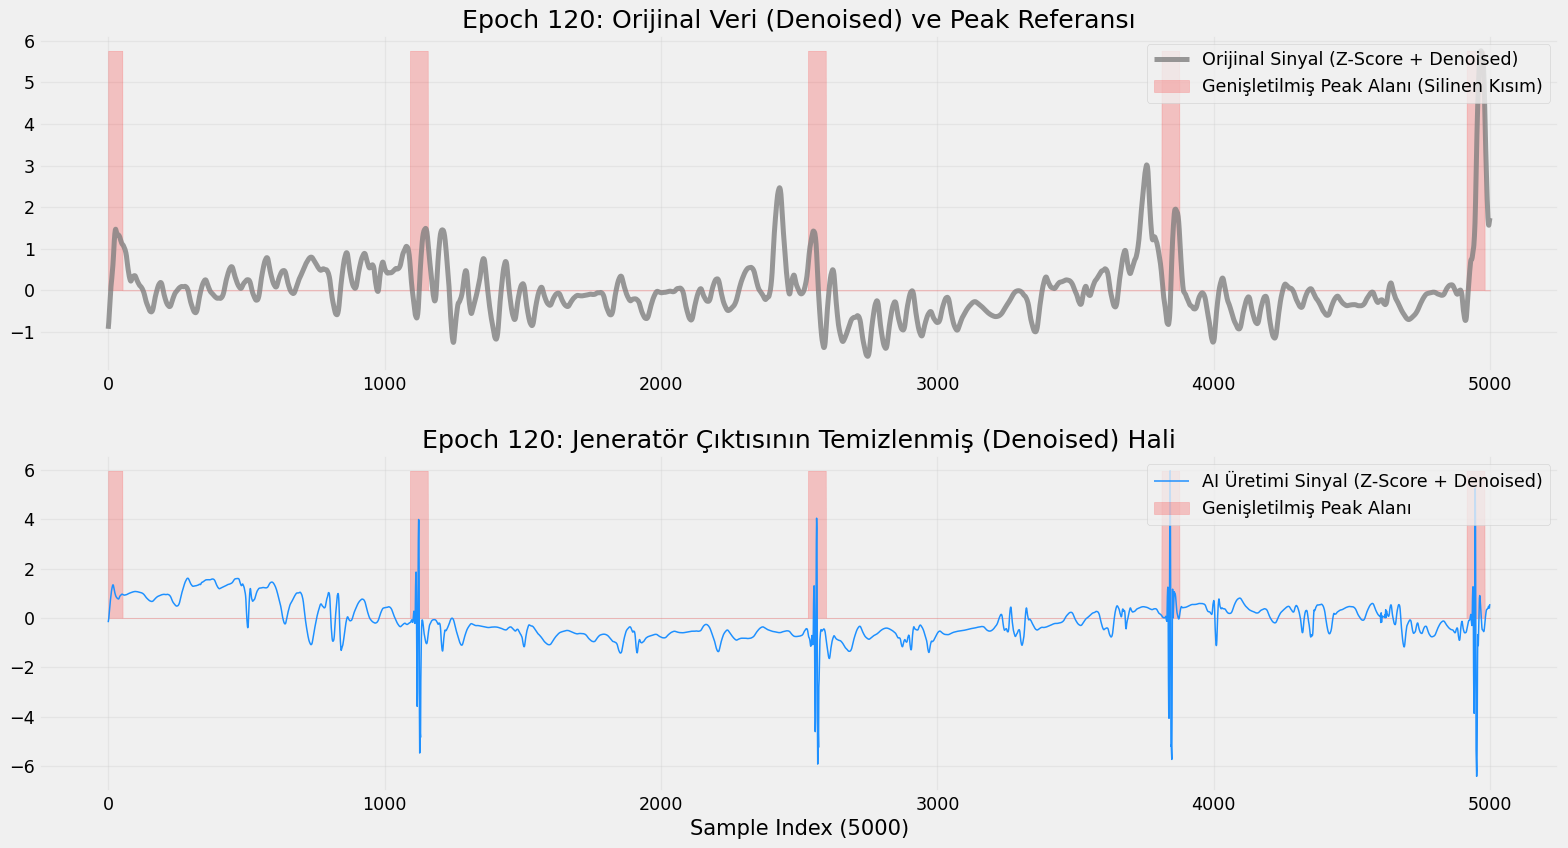

💾 Epoch 120 görselleri ve ağırlıkları kaydedildi.
--- EPOCH 121 BAŞLADI ---
Epoch 121 | Step 427/428 | D_Loss: 0.6503 | G_Total: 4.97
Epoch 121 Özet | D_Loss: 0.6502 | G_Total: 4.18 | Rec: 4.45 | Cls: 1.03
Yeni En Düşük G_Loss! (Best Epoch şu an: 121)
--- EPOCH 122 BAŞLADI ---
Epoch 122 | Step 427/428 | D_Loss: 0.6503 | G_Total: 4.67
Epoch 122 Özet | D_Loss: 0.6502 | G_Total: 4.15 | Rec: 4.67 | Cls: -0.00
Yeni En Düşük G_Loss! (Best Epoch şu an: 122)
--- EPOCH 123 BAŞLADI ---
Epoch 123 | Step 427/428 | D_Loss: 0.6502 | G_Total: 4.47
Epoch 123 Özet | D_Loss: 0.6502 | G_Total: 4.17 | Rec: 4.47 | Cls: 0.00
--- EPOCH 124 BAŞLADI ---
Epoch 124 | Step 427/428 | D_Loss: 0.6502 | G_Total: 4.58
Epoch 124 Özet | D_Loss: 0.6502 | G_Total: 4.12 | Rec: 4.58 | Cls: 0.00
Yeni En Düşük G_Loss! (Best Epoch şu an: 124)
--- EPOCH 125 BAŞLADI ---
Epoch 125 | Step 427/428 | D_Loss: 0.6502 | G_Total: 4.15
Epoch 125 Özet | D_Loss: 0.6502 | G_Total: 4.13 | Rec: 4.15 | Cls: 0.00


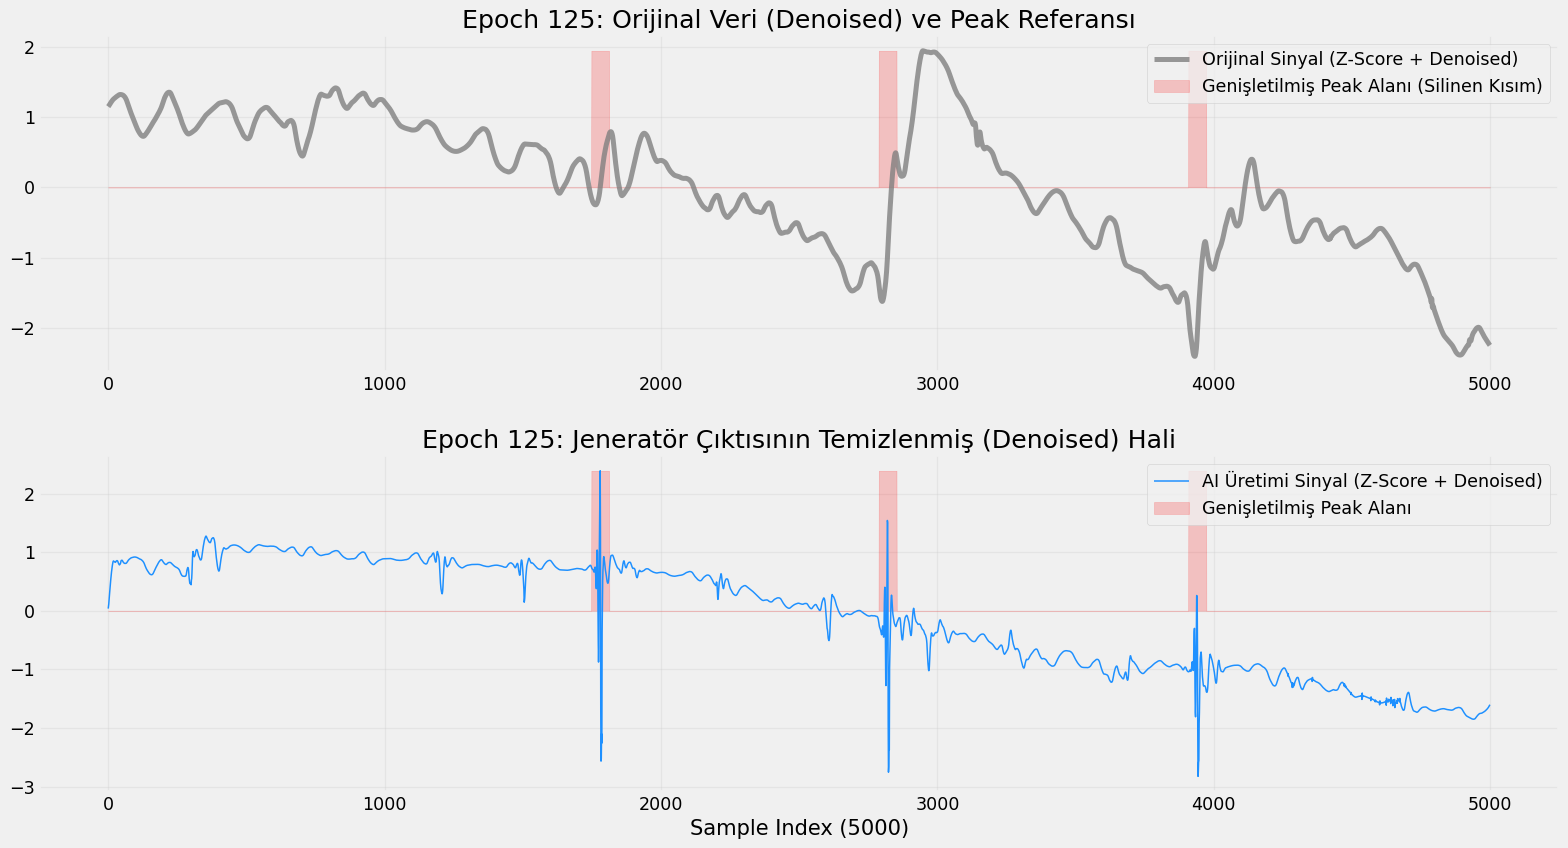

💾 Epoch 125 görselleri ve ağırlıkları kaydedildi.
--- EPOCH 126 BAŞLADI ---
Epoch 126 | Step 427/428 | D_Loss: 0.6502 | G_Total: 4.58
Epoch 126 Özet | D_Loss: 0.6502 | G_Total: 4.13 | Rec: 4.58 | Cls: 0.00
--- EPOCH 127 BAŞLADI ---
Epoch 127 | Step 427/428 | D_Loss: 0.6502 | G_Total: 4.24
Epoch 127 Özet | D_Loss: 0.6502 | G_Total: 4.05 | Rec: 4.24 | Cls: -0.00
Yeni En Düşük G_Loss! (Best Epoch şu an: 127)
--- EPOCH 128 BAŞLADI ---
Epoch 128 | Step 427/428 | D_Loss: 0.6502 | G_Total: 4.26
Epoch 128 Özet | D_Loss: 0.6502 | G_Total: 4.06 | Rec: 4.22 | Cls: 0.09
--- EPOCH 129 BAŞLADI ---
Epoch 129 | Step 427/428 | D_Loss: 0.6502 | G_Total: 4.03
Epoch 129 Özet | D_Loss: 0.6502 | G_Total: 4.06 | Rec: 4.03 | Cls: -0.00
--- EPOCH 130 BAŞLADI ---
Epoch 130 | Step 427/428 | D_Loss: 0.6502 | G_Total: 4.13
Epoch 130 Özet | D_Loss: 0.6502 | G_Total: 4.03 | Rec: 4.13 | Cls: 0.00
Yeni En Düşük G_Loss! (Best Epoch şu an: 130)


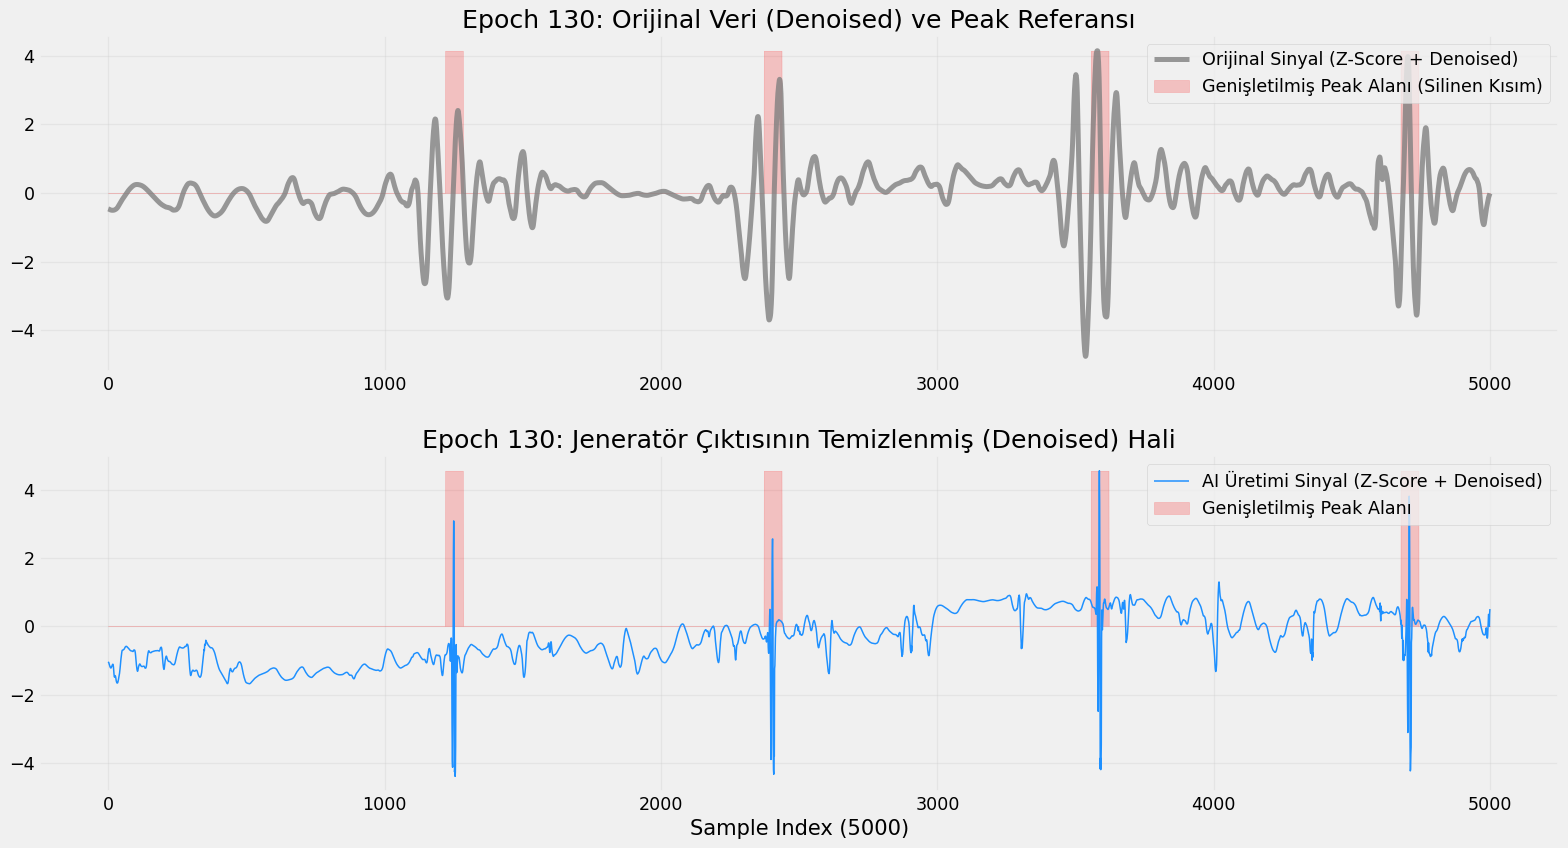

💾 Epoch 130 görselleri ve ağırlıkları kaydedildi.
--- EPOCH 131 BAŞLADI ---
Epoch 131 | Step 427/428 | D_Loss: 0.6502 | G_Total: 4.80
Epoch 131 Özet | D_Loss: 0.6502 | G_Total: 4.09 | Rec: 4.80 | Cls: -0.00
--- EPOCH 132 BAŞLADI ---
Epoch 132 | Step 427/428 | D_Loss: 0.6502 | G_Total: 3.91
Epoch 132 Özet | D_Loss: 0.6502 | G_Total: 4.07 | Rec: 3.91 | Cls: 0.00
--- EPOCH 133 BAŞLADI ---
Epoch 133 | Step 427/428 | D_Loss: 0.6502 | G_Total: 4.80
Epoch 133 Özet | D_Loss: 0.6502 | G_Total: 4.05 | Rec: 4.80 | Cls: 0.00
--- EPOCH 134 BAŞLADI ---
Epoch 134 | Step 427/428 | D_Loss: 0.6502 | G_Total: 4.41
Epoch 134 Özet | D_Loss: 0.6502 | G_Total: 4.06 | Rec: 4.41 | Cls: 0.00
--- EPOCH 135 BAŞLADI ---
Epoch 135 | Step 427/428 | D_Loss: 0.6502 | G_Total: 4.37
Epoch 135 Özet | D_Loss: 0.6502 | G_Total: 4.06 | Rec: 4.37 | Cls: 0.00


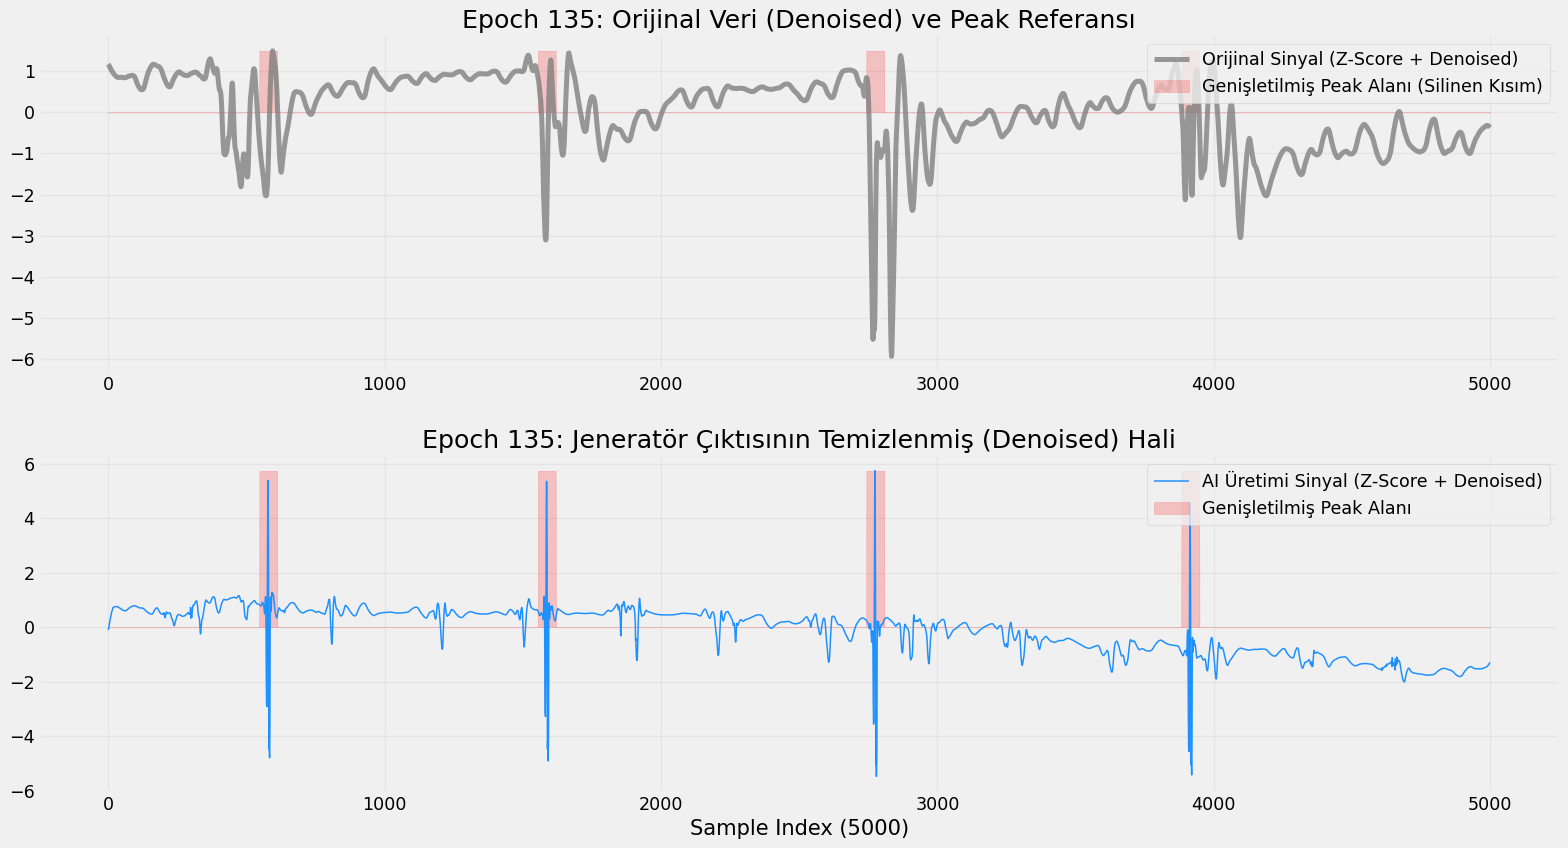

💾 Epoch 135 görselleri ve ağırlıkları kaydedildi.
--- EPOCH 136 BAŞLADI ---
Epoch 136 | Step 427/428 | D_Loss: 0.6502 | G_Total: 4.57
Epoch 136 Özet | D_Loss: 0.6502 | G_Total: 4.05 | Rec: 4.57 | Cls: 0.00
--- EPOCH 137 BAŞLADI ---
Epoch 137 | Step 427/428 | D_Loss: 0.6502 | G_Total: 4.55
Epoch 137 Özet | D_Loss: 0.6502 | G_Total: 4.07 | Rec: 4.55 | Cls: 0.00
--- EPOCH 138 BAŞLADI ---
Epoch 138 | Step 427/428 | D_Loss: 0.6502 | G_Total: 4.02
Epoch 138 Özet | D_Loss: 0.6502 | G_Total: 4.03 | Rec: 4.02 | Cls: 0.00
--- EPOCH 139 BAŞLADI ---
Epoch 139 | Step 427/428 | D_Loss: 0.6502 | G_Total: 4.23
Epoch 139 Özet | D_Loss: 0.6502 | G_Total: 4.06 | Rec: 4.23 | Cls: -0.00
--- EPOCH 140 BAŞLADI ---
Epoch 140 | Step 427/428 | D_Loss: 0.6502 | G_Total: 4.31
Epoch 140 Özet | D_Loss: 0.6502 | G_Total: 4.04 | Rec: 4.31 | Cls: 0.00


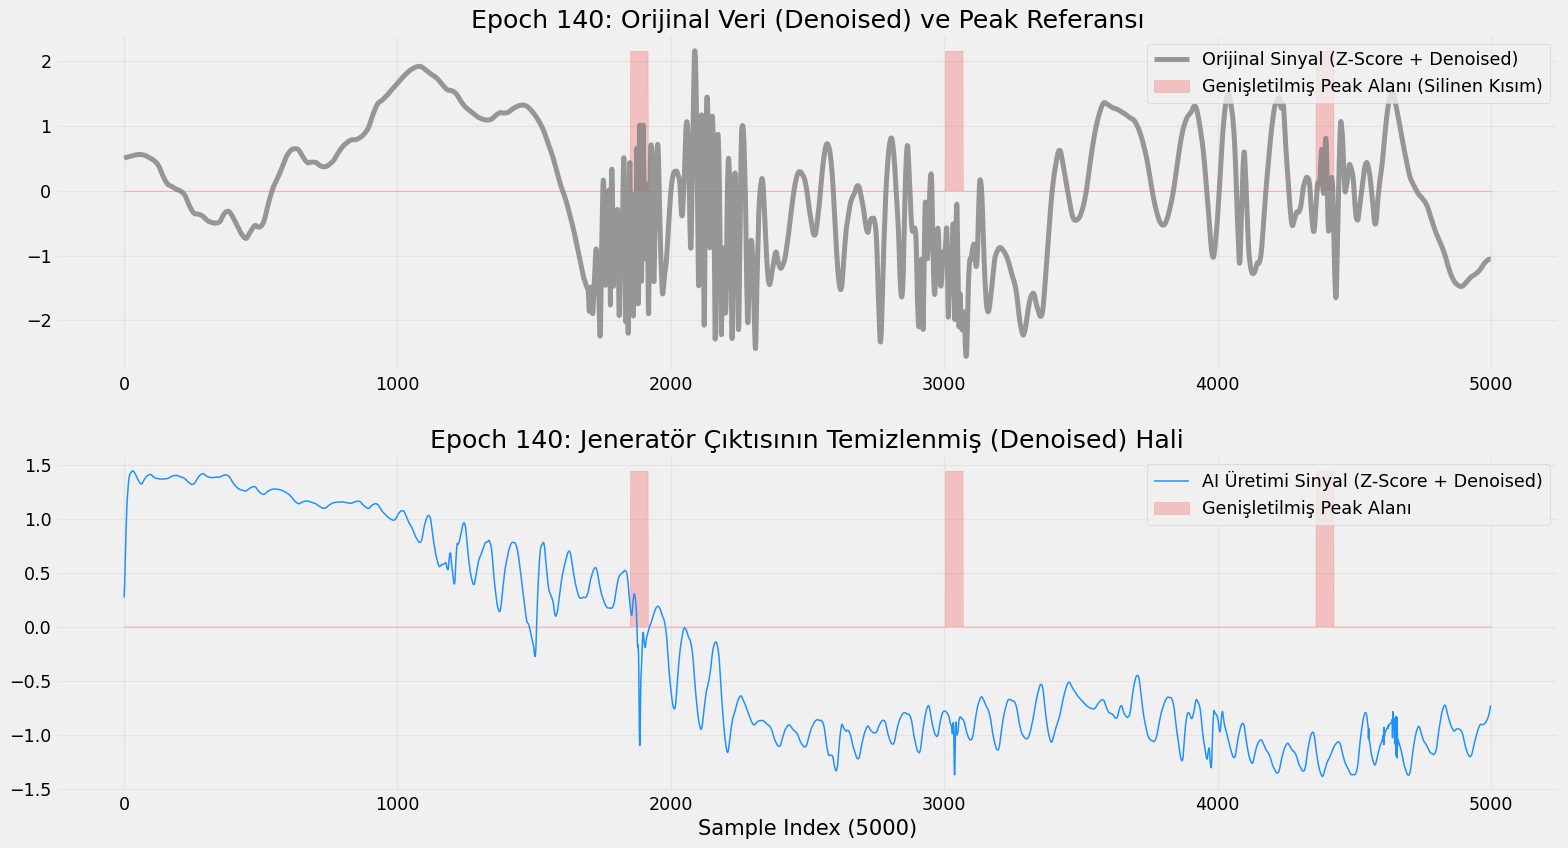

💾 Epoch 140 görselleri ve ağırlıkları kaydedildi.
--- EPOCH 141 BAŞLADI ---
Epoch 141 | Step 427/428 | D_Loss: 0.6502 | G_Total: 4.20
Epoch 141 Özet | D_Loss: 0.6502 | G_Total: 4.04 | Rec: 4.20 | Cls: 0.00
--- EPOCH 142 BAŞLADI ---
Epoch 142 | Step 427/428 | D_Loss: 0.6503 | G_Total: 4.37
Epoch 142 Özet | D_Loss: 0.6502 | G_Total: 4.03 | Rec: 4.37 | Cls: 0.00
--- EPOCH 143 BAŞLADI ---
Epoch 143 | Step 427/428 | D_Loss: 0.6502 | G_Total: 4.25
Epoch 143 Özet | D_Loss: 0.6502 | G_Total: 4.06 | Rec: 4.25 | Cls: -0.00
--- EPOCH 144 BAŞLADI ---
Epoch 144 | Step 427/428 | D_Loss: 0.6502 | G_Total: 4.11
Epoch 144 Özet | D_Loss: 0.6502 | G_Total: 3.99 | Rec: 4.11 | Cls: 0.00
Yeni En Düşük G_Loss! (Best Epoch şu an: 144)
--- EPOCH 145 BAŞLADI ---
Epoch 145 | Step 427/428 | D_Loss: 0.6502 | G_Total: 4.31
Epoch 145 Özet | D_Loss: 0.6502 | G_Total: 4.01 | Rec: 4.31 | Cls: 0.00


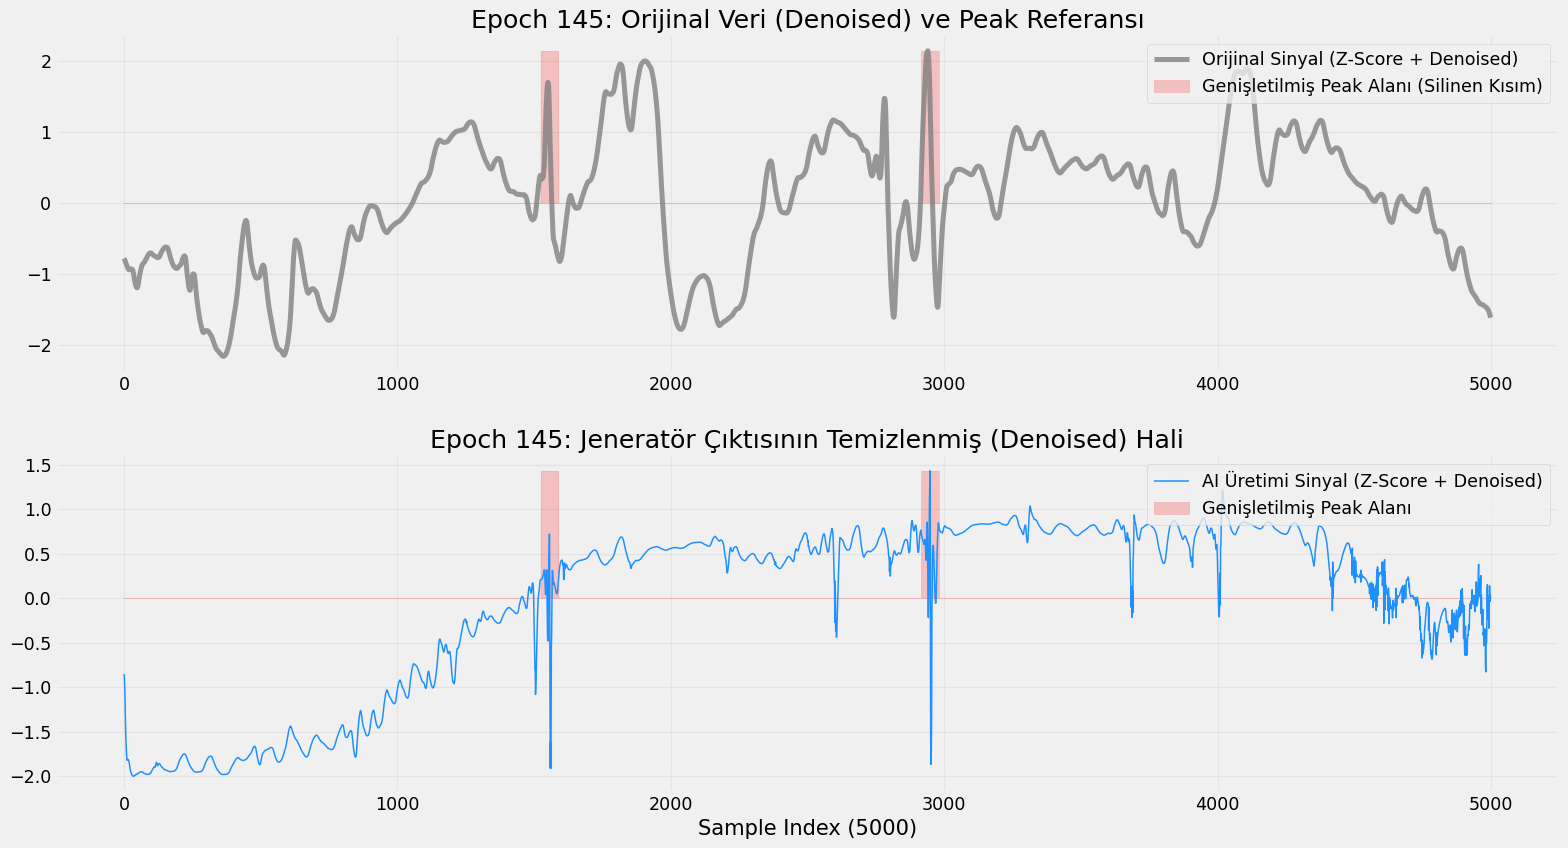

💾 Epoch 145 görselleri ve ağırlıkları kaydedildi.
--- EPOCH 146 BAŞLADI ---
Epoch 146 | Step 427/428 | D_Loss: 0.6502 | G_Total: 4.18
Epoch 146 Özet | D_Loss: 0.6502 | G_Total: 3.98 | Rec: 4.18 | Cls: 0.00
Yeni En Düşük G_Loss! (Best Epoch şu an: 146)
--- EPOCH 147 BAŞLADI ---
Epoch 147 | Step 427/428 | D_Loss: 0.6502 | G_Total: 4.13
Epoch 147 Özet | D_Loss: 0.6502 | G_Total: 4.02 | Rec: 4.13 | Cls: 0.00
--- EPOCH 148 BAŞLADI ---
Epoch 148 | Step 427/428 | D_Loss: 0.6503 | G_Total: 4.56
Epoch 148 Özet | D_Loss: 0.6502 | G_Total: 4.04 | Rec: 4.56 | Cls: 0.00
--- EPOCH 149 BAŞLADI ---
Epoch 149 | Step 427/428 | D_Loss: 0.6505 | G_Total: 4.56
Epoch 149 Özet | D_Loss: 0.6507 | G_Total: 4.02 | Rec: 4.56 | Cls: 0.00
--- EPOCH 150 BAŞLADI ---
Epoch 150 | Step 427/428 | D_Loss: 0.6502 | G_Total: 3.78
Epoch 150 Özet | D_Loss: 0.6502 | G_Total: 3.90 | Rec: 3.78 | Cls: 0.00
Yeni En Düşük G_Loss! (Best Epoch şu an: 150)


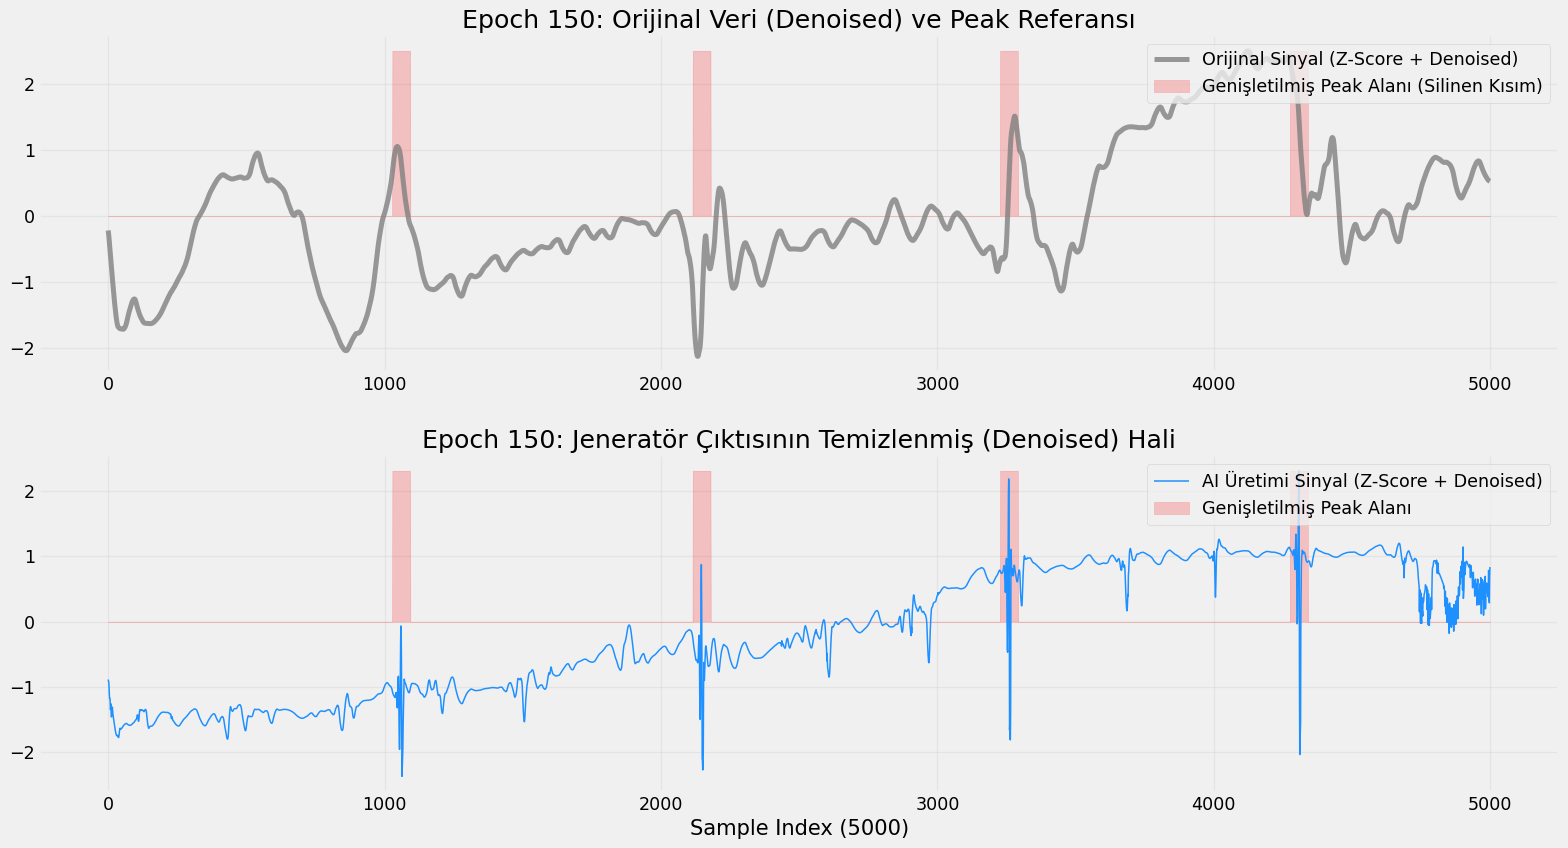

💾 Epoch 150 görselleri ve ağırlıkları kaydedildi.
--- EPOCH 151 BAŞLADI ---
Epoch 151 | Step 427/428 | D_Loss: 0.6502 | G_Total: 4.11
Epoch 151 Özet | D_Loss: 0.6502 | G_Total: 3.92 | Rec: 4.11 | Cls: 0.00
--- EPOCH 152 BAŞLADI ---
Epoch 152 | Step 427/428 | D_Loss: 0.6502 | G_Total: 4.10
Epoch 152 Özet | D_Loss: 0.6502 | G_Total: 3.95 | Rec: 4.10 | Cls: 0.00
--- EPOCH 153 BAŞLADI ---
Epoch 153 | Step 427/428 | D_Loss: 0.6503 | G_Total: 3.91
Epoch 153 Özet | D_Loss: 0.6502 | G_Total: 3.91 | Rec: 3.91 | Cls: 0.00
--- EPOCH 154 BAŞLADI ---
Epoch 154 | Step 427/428 | D_Loss: 0.6502 | G_Total: 3.78
Epoch 154 Özet | D_Loss: 0.6502 | G_Total: 3.89 | Rec: 3.78 | Cls: 0.00
Yeni En Düşük G_Loss! (Best Epoch şu an: 154)
--- EPOCH 155 BAŞLADI ---
Epoch 155 | Step 427/428 | D_Loss: 0.6502 | G_Total: 4.00
Epoch 155 Özet | D_Loss: 0.6502 | G_Total: 3.90 | Rec: 4.00 | Cls: 0.00


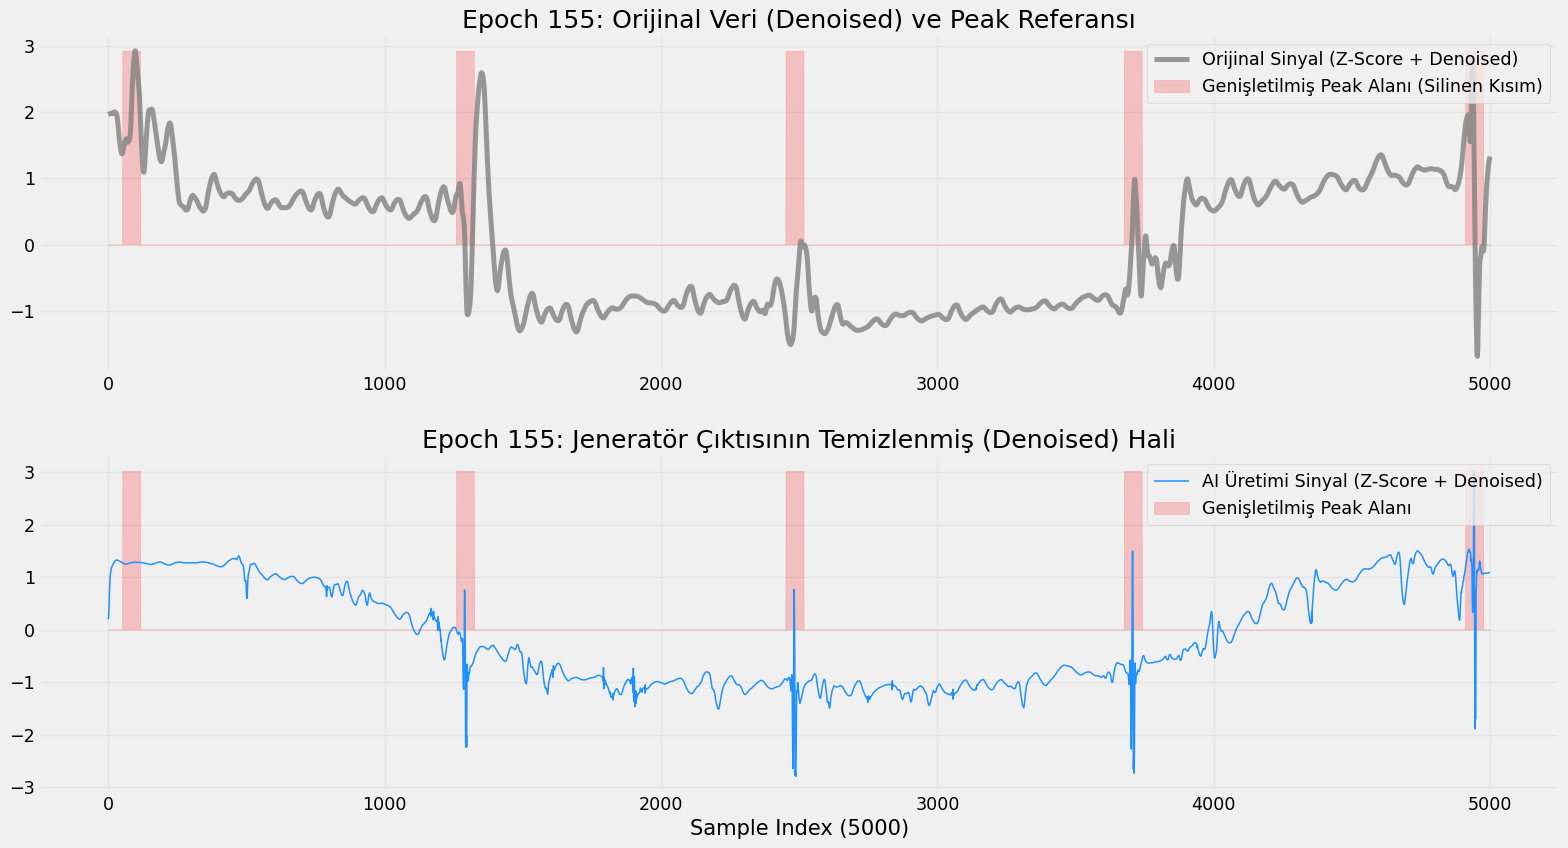

💾 Epoch 155 görselleri ve ağırlıkları kaydedildi.
--- EPOCH 156 BAŞLADI ---
Epoch 156 | Step 427/428 | D_Loss: 0.6502 | G_Total: 3.64
Epoch 156 Özet | D_Loss: 0.6502 | G_Total: 3.95 | Rec: 3.64 | Cls: -0.00
--- EPOCH 157 BAŞLADI ---
Epoch 157 | Step 427/428 | D_Loss: 0.6502 | G_Total: 3.97
Epoch 157 Özet | D_Loss: 0.6502 | G_Total: 3.89 | Rec: 3.97 | Cls: 0.00
Yeni En Düşük G_Loss! (Best Epoch şu an: 157)
--- EPOCH 158 BAŞLADI ---
Epoch 158 | Step 427/428 | D_Loss: 0.6503 | G_Total: 4.94
Epoch 158 Özet | D_Loss: 0.6502 | G_Total: 3.95 | Rec: 4.92 | Cls: 0.03
--- EPOCH 159 BAŞLADI ---
Epoch 159 | Step 427/428 | D_Loss: 0.6502 | G_Total: 3.83
Epoch 159 Özet | D_Loss: 0.6502 | G_Total: 3.95 | Rec: 3.83 | Cls: 0.00
--- EPOCH 160 BAŞLADI ---
Epoch 160 | Step 427/428 | D_Loss: 0.6502 | G_Total: 4.06
Epoch 160 Özet | D_Loss: 0.6502 | G_Total: 3.88 | Rec: 4.06 | Cls: -0.00
Yeni En Düşük G_Loss! (Best Epoch şu an: 160)


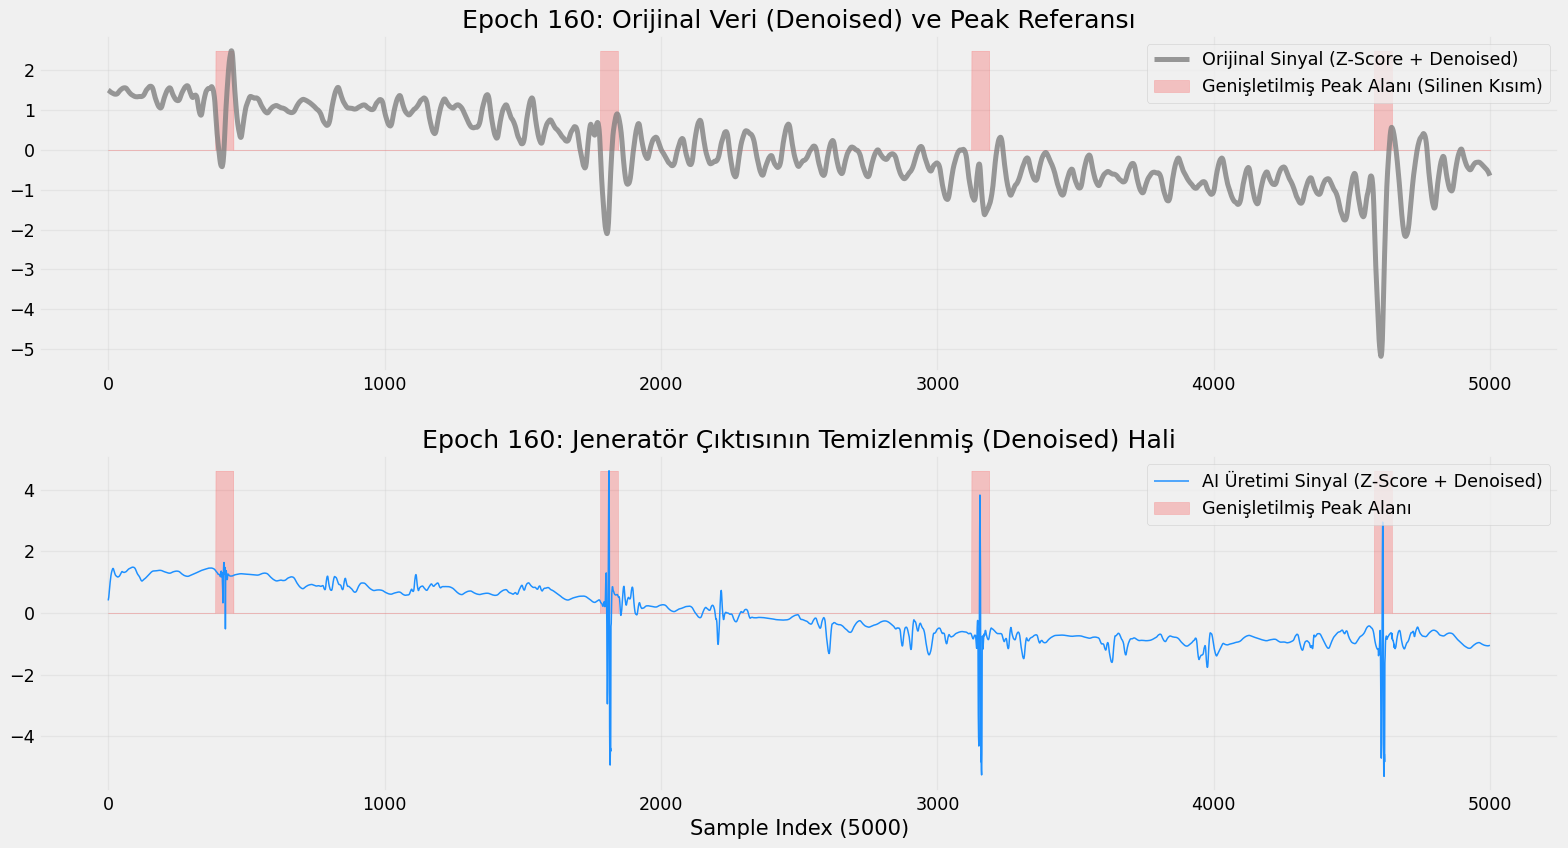

💾 Epoch 160 görselleri ve ağırlıkları kaydedildi.
--- EPOCH 161 BAŞLADI ---
Epoch 161 | Step 427/428 | D_Loss: 0.6502 | G_Total: 4.27
Epoch 161 Özet | D_Loss: 0.6502 | G_Total: 3.94 | Rec: 4.27 | Cls: 0.00
--- EPOCH 162 BAŞLADI ---
Epoch 162 | Step 427/428 | D_Loss: 0.6502 | G_Total: 3.75
Epoch 162 Özet | D_Loss: 0.6502 | G_Total: 3.91 | Rec: 3.75 | Cls: 0.00
--- EPOCH 163 BAŞLADI ---
Epoch 163 | Step 427/428 | D_Loss: 0.6502 | G_Total: 3.94
Epoch 163 Özet | D_Loss: 0.6502 | G_Total: 3.89 | Rec: 3.94 | Cls: 0.00
--- EPOCH 164 BAŞLADI ---
Epoch 164 | Step 427/428 | D_Loss: 0.6502 | G_Total: 3.78
Epoch 164 Özet | D_Loss: 0.6502 | G_Total: 3.91 | Rec: 3.78 | Cls: 0.00
--- EPOCH 165 BAŞLADI ---
Epoch 165 | Step 427/428 | D_Loss: 0.6502 | G_Total: 4.36
Epoch 165 Özet | D_Loss: 0.6502 | G_Total: 3.95 | Rec: 4.36 | Cls: 0.00


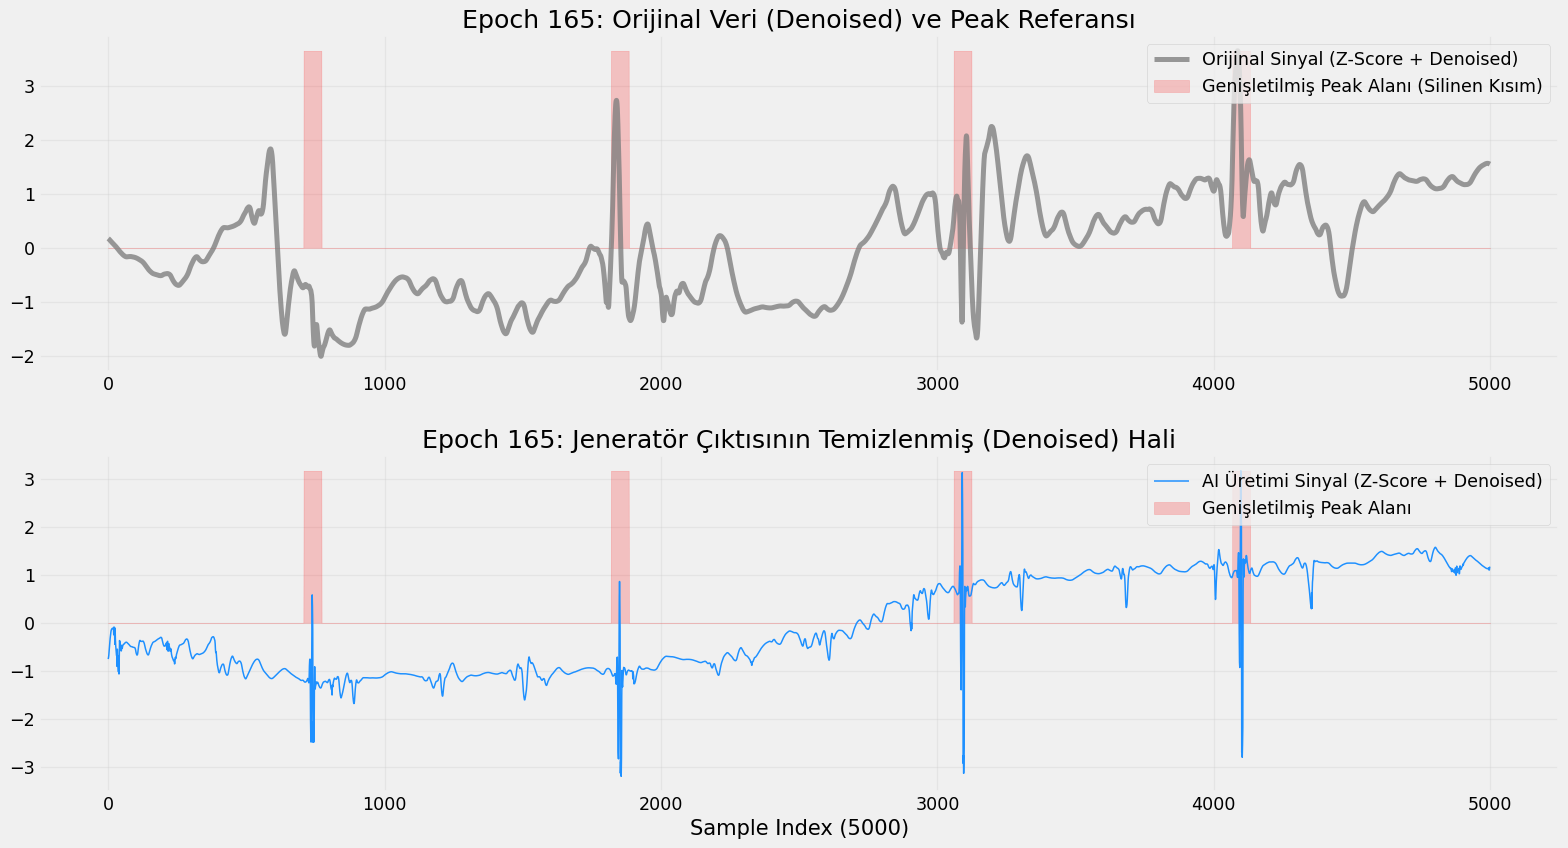

💾 Epoch 165 görselleri ve ağırlıkları kaydedildi.
--- EPOCH 166 BAŞLADI ---
Epoch 166 | Step 427/428 | D_Loss: 0.6502 | G_Total: 4.24
Epoch 166 Özet | D_Loss: 0.6502 | G_Total: 3.90 | Rec: 4.24 | Cls: 0.00
--- EPOCH 167 BAŞLADI ---
Epoch 167 | Step 427/428 | D_Loss: 0.6502 | G_Total: 4.15
Epoch 167 Özet | D_Loss: 0.6502 | G_Total: 3.87 | Rec: 4.15 | Cls: 0.00
Yeni En Düşük G_Loss! (Best Epoch şu an: 167)
--- EPOCH 168 BAŞLADI ---
Epoch 168 | Step 427/428 | D_Loss: 0.6502 | G_Total: 3.81
Epoch 168 Özet | D_Loss: 0.6502 | G_Total: 3.86 | Rec: 3.81 | Cls: 0.00
Yeni En Düşük G_Loss! (Best Epoch şu an: 168)
--- EPOCH 169 BAŞLADI ---
Epoch 169 | Step 427/428 | D_Loss: 0.6502 | G_Total: 4.54
Epoch 169 Özet | D_Loss: 0.6502 | G_Total: 3.85 | Rec: 4.54 | Cls: -0.00
Yeni En Düşük G_Loss! (Best Epoch şu an: 169)
--- EPOCH 170 BAŞLADI ---
Epoch 170 | Step 427/428 | D_Loss: 0.6502 | G_Total: 4.13
Epoch 170 Özet | D_Loss: 0.6502 | G_Total: 3.86 | Rec: 4.13 | Cls: 0.00


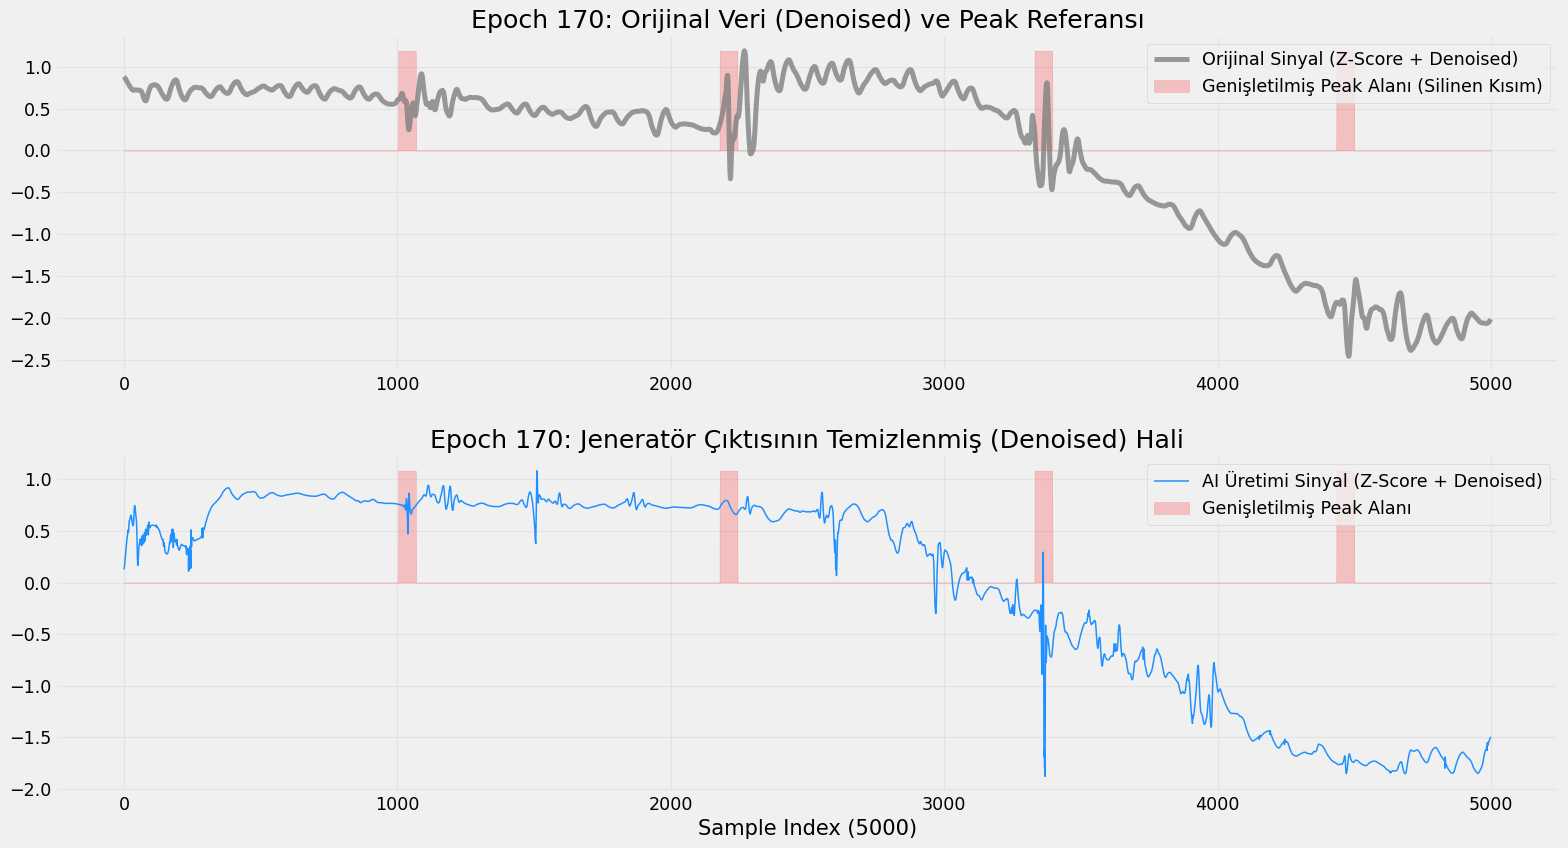

💾 Epoch 170 görselleri ve ağırlıkları kaydedildi.
--- EPOCH 171 BAŞLADI ---
Epoch 171 | Step 427/428 | D_Loss: 0.6502 | G_Total: 4.20
Epoch 171 Özet | D_Loss: 0.6507 | G_Total: 3.83 | Rec: 4.20 | Cls: -0.00
Yeni En Düşük G_Loss! (Best Epoch şu an: 171)
--- EPOCH 172 BAŞLADI ---
Epoch 172 | Step 427/428 | D_Loss: 0.6502 | G_Total: 4.56
Epoch 172 Özet | D_Loss: 0.6502 | G_Total: 3.77 | Rec: 4.56 | Cls: 0.00
Yeni En Düşük G_Loss! (Best Epoch şu an: 172)
--- EPOCH 173 BAŞLADI ---
Epoch 173 | Step 427/428 | D_Loss: 0.6502 | G_Total: 3.89
Epoch 173 Özet | D_Loss: 0.6502 | G_Total: 3.75 | Rec: 3.89 | Cls: 0.00
Yeni En Düşük G_Loss! (Best Epoch şu an: 173)
--- EPOCH 174 BAŞLADI ---
Epoch 174 | Step 427/428 | D_Loss: 0.6502 | G_Total: 3.58
Epoch 174 Özet | D_Loss: 0.6502 | G_Total: 3.76 | Rec: 3.58 | Cls: 0.00
--- EPOCH 175 BAŞLADI ---
Epoch 175 | Step 427/428 | D_Loss: 0.6502 | G_Total: 3.79
Epoch 175 Özet | D_Loss: 0.6502 | G_Total: 3.73 | Rec: 3.79 | Cls: 0.00
Yeni En Düşük G_Loss! (Best Epo

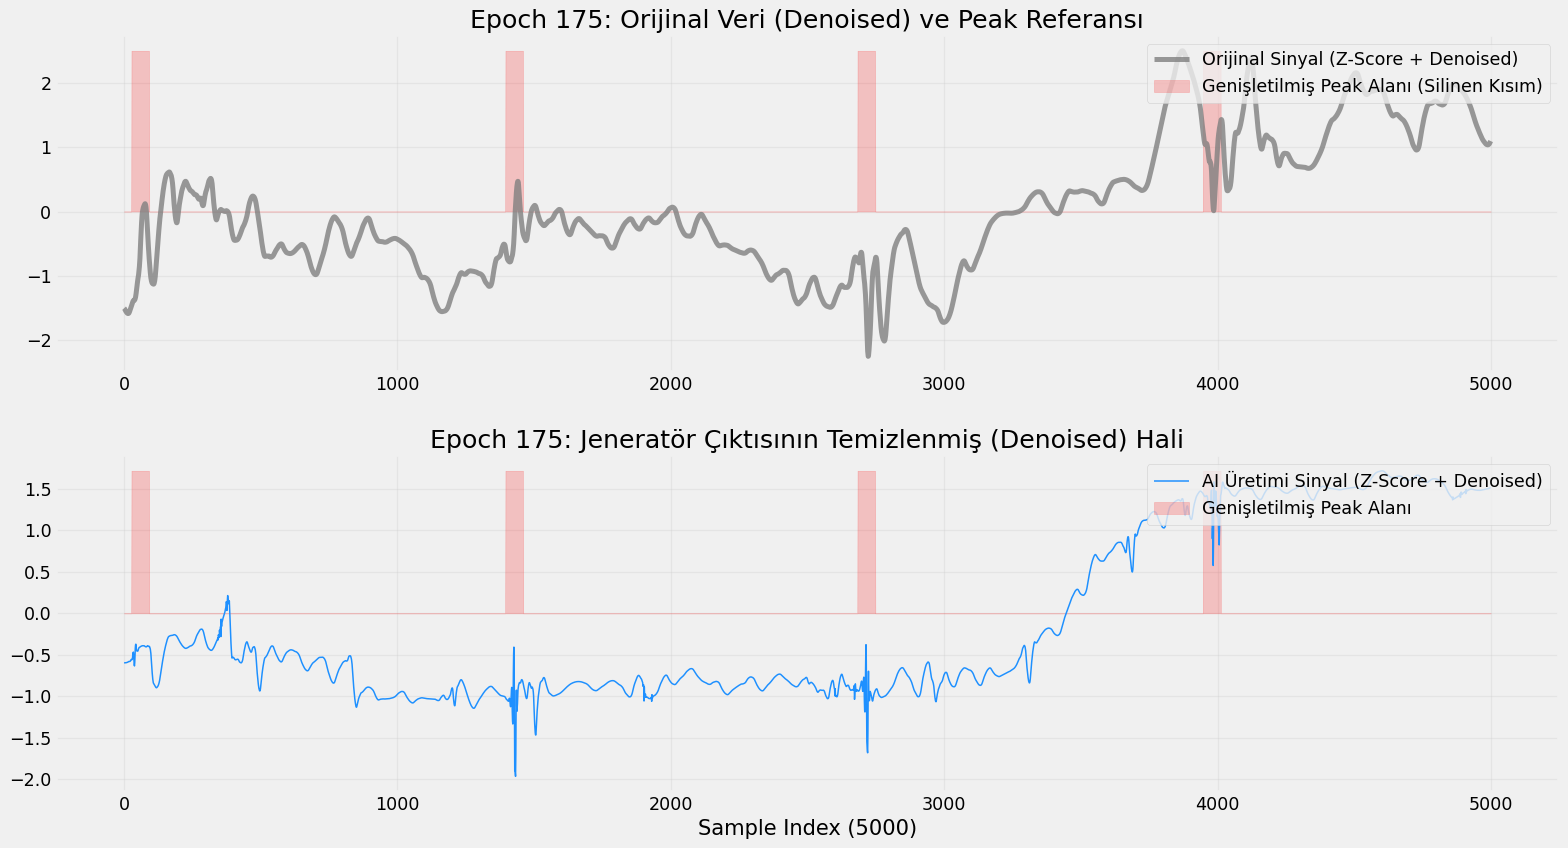

💾 Epoch 175 görselleri ve ağırlıkları kaydedildi.
--- EPOCH 176 BAŞLADI ---
Epoch 176 | Step 427/428 | D_Loss: 0.6502 | G_Total: 3.91
Epoch 176 Özet | D_Loss: 0.6502 | G_Total: 3.73 | Rec: 3.91 | Cls: 0.00
--- EPOCH 177 BAŞLADI ---
Epoch 177 | Step 427/428 | D_Loss: 0.6502 | G_Total: 4.20
Epoch 177 Özet | D_Loss: 0.6502 | G_Total: 3.76 | Rec: 4.20 | Cls: 0.00
--- EPOCH 178 BAŞLADI ---
Epoch 178 | Step 427/428 | D_Loss: 0.6502 | G_Total: 3.53
Epoch 178 Özet | D_Loss: 0.6502 | G_Total: 3.71 | Rec: 3.53 | Cls: 0.00
Yeni En Düşük G_Loss! (Best Epoch şu an: 178)
--- EPOCH 179 BAŞLADI ---
Epoch 179 | Step 427/428 | D_Loss: 0.6503 | G_Total: 4.03
Epoch 179 Özet | D_Loss: 0.6502 | G_Total: 3.76 | Rec: 4.03 | Cls: -0.00
--- EPOCH 180 BAŞLADI ---
Epoch 180 | Step 427/428 | D_Loss: 0.6502 | G_Total: 3.90
Epoch 180 Özet | D_Loss: 0.6502 | G_Total: 3.78 | Rec: 3.90 | Cls: 0.00


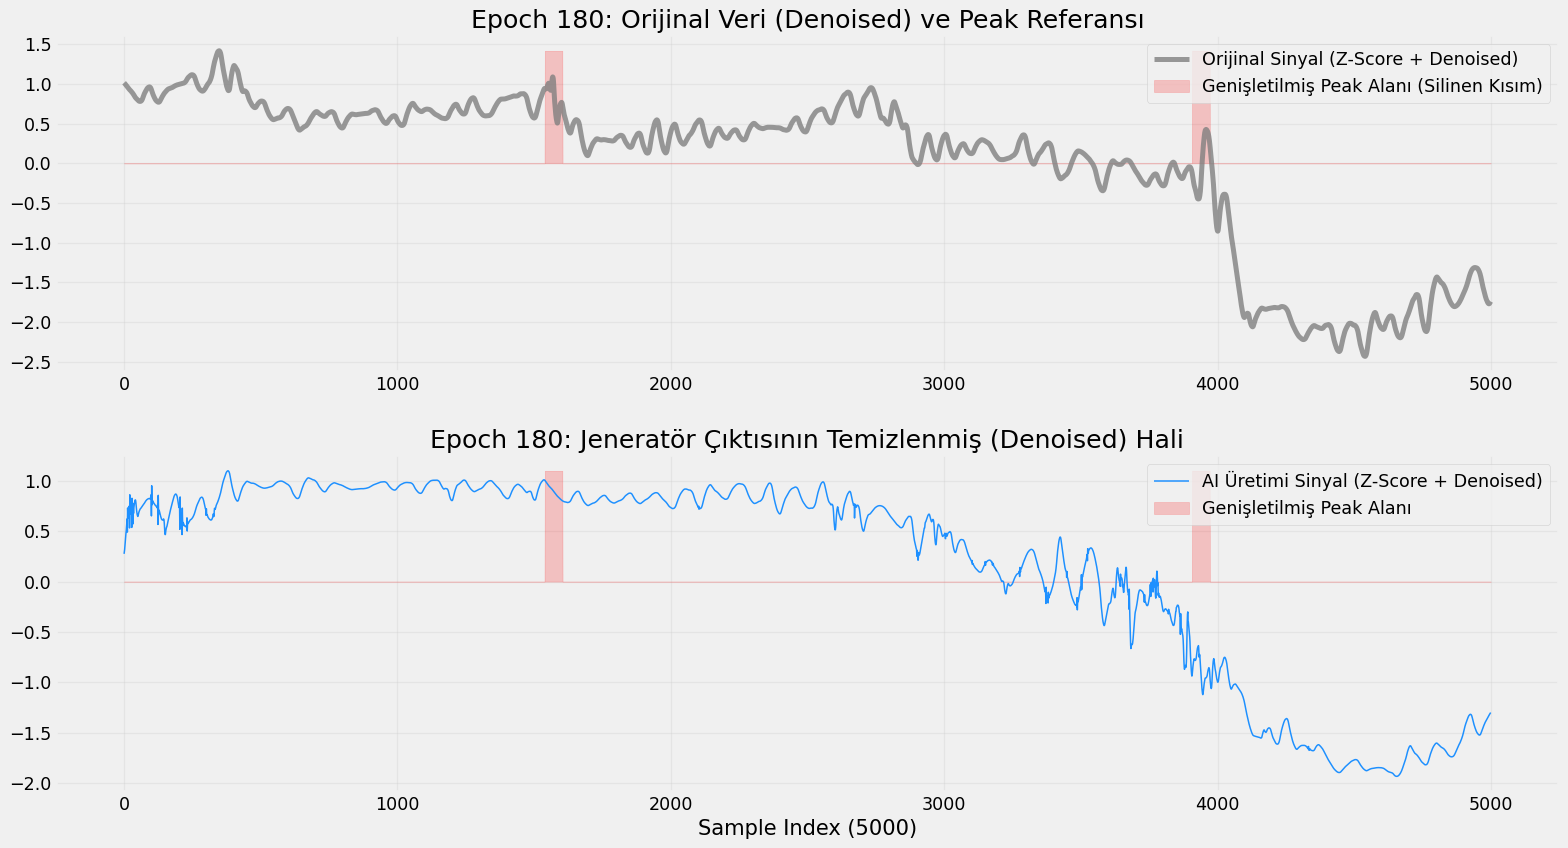

💾 Epoch 180 görselleri ve ağırlıkları kaydedildi.
--- EPOCH 181 BAŞLADI ---
Epoch 181 | Step 427/428 | D_Loss: 0.6502 | G_Total: 3.70
Epoch 181 Özet | D_Loss: 0.6502 | G_Total: 3.83 | Rec: 3.70 | Cls: 0.00
--- EPOCH 182 BAŞLADI ---
Epoch 182 | Step 427/428 | D_Loss: 0.6502 | G_Total: 3.78
Epoch 182 Özet | D_Loss: 0.6502 | G_Total: 3.77 | Rec: 3.78 | Cls: 0.00
--- EPOCH 183 BAŞLADI ---
Epoch 183 | Step 427/428 | D_Loss: 0.6502 | G_Total: 3.56
Epoch 183 Özet | D_Loss: 0.6502 | G_Total: 3.76 | Rec: 3.56 | Cls: 0.00
--- EPOCH 184 BAŞLADI ---
Epoch 184 | Step 427/428 | D_Loss: 0.6502 | G_Total: 4.62
Epoch 184 Özet | D_Loss: 0.6502 | G_Total: 3.82 | Rec: 4.62 | Cls: 0.00
--- EPOCH 185 BAŞLADI ---
Epoch 185 | Step 127/428 | D_Loss: 0.6502 | G_Total: 3.52

KeyboardInterrupt: 

In [10]:
import time
import tensorflow as tf

EPOCHS = 500
best_g_loss = float('inf') # En düşük Generator loss'unu takip etmek için
best_epoch_num = 0

for epoch in range(EPOCHS):
    start = time.time()
    epoch_d_loss = []
    epoch_g_loss = []
    
    total_steps = len(train_seq)
    print(f"--- EPOCH {epoch+1} BAŞLADI ---")
    
    for step in range(total_steps):
        batch_data, _ = train_seq[step] 
        real_sigs = tf.convert_to_tensor(batch_data[:, :, 0:1], dtype=tf.float32)
        peaks = tf.convert_to_tensor(batch_data[:, :, 1:2], dtype=tf.float32)
        
        d_l, g_l, l_rec, l_cls = train_step(real_sigs, peaks)
        
        epoch_d_loss.append(d_l)
        epoch_g_loss.append(g_l)
        
        print(f"Epoch {epoch+1} | Step {step}/{total_steps} | D_Loss: {d_l:.4f} | G_Total: {g_l:.2f}", end='\r', flush=True)

    # Epoch ortalamaları
    avg_d_loss = tf.reduce_mean(epoch_d_loss).numpy()
    avg_g_loss = tf.reduce_mean(epoch_g_loss).numpy()
    
    print(f"\nEpoch {epoch+1} Özet | D_Loss: {avg_d_loss:.4f} | G_Total: {avg_g_loss:.2f} | Rec: {l_rec:.2f} | Cls: {l_cls:.2f}")
    
    # BEST EPOCH TAKİBİ (Matematiksel Olarak)
    if avg_g_loss < best_g_loss:
        best_g_loss = avg_g_loss
        best_epoch_num = epoch + 1
        print(f"Yeni En Düşük G_Loss! (Best Epoch şu an: {best_epoch_num})")

    # HER 5 EPOCH'TA BİR: ÇİZİM YAP VE AĞIRLIKLARI KAYDET
    if (epoch + 1) % 5 == 0:
        # 1. Çizimi model klasörüne kaydet
        visualize_epoch_results(epoch, encoder, generator, train_seq, MODEL_FOLDER)
        
        # 2. Manuel seçim yapabilmen için ağırlıkları (weights) kaydet
        enc_weight_path = os.path.join(MODEL_FOLDER, "weights", f"encoder_epoch_{epoch+1}.h5")
        gen_weight_path = os.path.join(MODEL_FOLDER, "weights", f"generator_epoch_{epoch+1}.h5")
        
        encoder.save_weights(enc_weight_path)
        generator.save_weights(gen_weight_path)
        print(f"💾 Epoch {epoch+1} görselleri ve ağırlıkları kaydedildi.")

print(f"\nEĞİTİM BİTTİ! Matematiksel Olarak En İyi Epoch: {best_epoch_num}")
print(f"Tüm ağırlıklar ve görseller '{MODEL_FOLDER}' klasöründe incelenmeyi bekliyor.")